In [1]:
# seed_utils.py
import os
import random
import numpy as np
import time
# 记录SIMO算法总流程开始时间
simo_start_time = time.time()

def set_global_seed(seed: int,
                    deterministic_torch: bool = True,
                    cudnn_benchmark: bool = False,
                    verbose: bool = False):
    """
    Set seeds for Python, NumPy, PyTorch (CPU/CUDA/MPS), CuPy (opt), TensorFlow (opt).
    Also sets PYTHONHASHSEED for hash stability (must be set before Python starts
    to be absolute; setting here helps for child processes).

    Args:
      seed: any positive int
      deterministic_torch: True -> use deterministic algorithms where possible
      cudnn_benchmark: PyTorch cuDNN autotuner (leave False for determinism)
      verbose: print what got seeded
    """
    seed = int(seed)

    # 0) Python hashing (affects set/dict iteration order across runs)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 1) Python & NumPy
    random.seed(seed)
    np.random.seed(seed)

    # 2) PyTorch (if available)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)

        # MPS (Apple Silicon)
        try:
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                # no explicit seed API; manual_seed covers CPU ops driving MPS
                pass
        except Exception:
            pass

        # Determinism knobs
        torch.backends.cudnn.deterministic = bool(deterministic_torch)
        torch.backends.cudnn.benchmark = bool(cudnn_benchmark)
        # Stronger guarantee (may raise if an op has no deterministic kernel)
        if deterministic_torch and hasattr(torch, "use_deterministic_algorithms"):
            torch.use_deterministic_algorithms(True, warn_only=True)

    except Exception as e:
        if verbose:
            print(f"[seed] PyTorch not seeded: {e}")


    if verbose:
        print(f"[seed] Set global seed = {seed} | deterministic_torch={deterministic_torch} | cudnn_benchmark={cudnn_benchmark}")


def torch_worker_init_fn(worker_id):
    """
    Use in PyTorch DataLoader to make each worker deterministic.

    Example:
      loader = DataLoader(dataset, num_workers=4, worker_init_fn=torch_worker_init_fn, generator=torch.Generator().manual_seed(42))
    """
    # Derive each worker’s seed from the initial NumPy RNG state
    worker_seed = (np.random.get_state()[1][0] + worker_id) % (2**32 - 1)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    try:
        import torch
        torch.manual_seed(worker_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(worker_seed)
    except Exception:
        pass


# Optional: a context manager for temporary seeding
from contextlib import contextmanager

@contextmanager
def temp_seed(seed: int):
    """Temporarily set NumPy & Python seeds inside a with-block."""
    # save states
    py_state = random.getstate()
    np_state = np.random.get_state()
    try:
        random.seed(seed)
        np.random.seed(seed)
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)


In [2]:
set_global_seed(123, deterministic_torch=True, cudnn_benchmark=False, verbose=True)

[seed] Set global seed = 123 | deterministic_torch=True | cudnn_benchmark=False


In [5]:
##### Read real data + name hygiene
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

def _clean_index_to_str(idx):
    return pd.Index(pd.Index(idx).astype(str).str.strip())

def _normalize_var_names(adata_obj, obj_name):
    # gene / peak names: 统一成字符串，去掉首尾空格，再做唯一化
    adata_obj.var_names = _clean_index_to_str(adata_obj.var_names)

    if adata_obj.var.index.name is not None and not isinstance(adata_obj.var.index.name, str):
        adata_obj.var.index.name = str(adata_obj.var.index.name)

    adata_obj.var_names_make_unique()

    dup_n = int(adata_obj.var_names.duplicated().sum())
    if dup_n > 0:
        raise ValueError(f"{obj_name}.var_names 仍有重复，数量={dup_n}")
    return adata_obj

def _normalize_obs_names_sc(adata_obj, obj_name):
    # sc 的 obs_names 只用于行索引，不参与多模态 spot 对齐，允许自动唯一化
    adata_obj.obs_names = _clean_index_to_str(adata_obj.obs_names)
    adata_obj.obs_names_make_unique()

    dup_n = int(adata_obj.obs_names.duplicated().sum())
    if dup_n > 0:
        raise ValueError(f"{obj_name}.obs_names 仍有重复，数量={dup_n}")
    return adata_obj

def _normalize_obs_names_spatial(adata_obj, obj_name):
    # 空转 RNA / 第二模态 的 obs_names 会用于 spot 对齐，不自动加后缀，避免破坏跨模态匹配
    adata_obj.obs_names = _clean_index_to_str(adata_obj.obs_names)

    dup_mask = adata_obj.obs_names.duplicated()
    if dup_mask.any():
        dup_examples = adata_obj.obs_names[dup_mask].tolist()[:10]
        raise ValueError(
            f"{obj_name}.obs_names 有重复，不能安全用于多模态对齐。"
            f"重复示例: {dup_examples}"
        )
    return adata_obj


/opt/micromamba/envs/py310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [6]:
################ ===== 1. read =====
sc_adata = ad.read_h5ad('./ref_RNA_30_rep0.h5ad')
adata = ad.read_h5ad('./simulation_rna_drop.h5ad')
adt_adata = ad.read_h5ad('./simulation_atac_noise.h5ad')   # 变量名沿用 adt_adata，但这里实际可以是 ATAC


In [7]:
# ===== 2. normalize names =====
for obj_name, obj in [('sc_adata', sc_adata), ('adata', adata), ('adt_adata', adt_adata)]:
    _normalize_var_names(obj, obj_name)

sc_adata = _normalize_obs_names_sc(sc_adata, 'sc_adata')
adata = _normalize_obs_names_spatial(adata, 'adata')
adt_adata = _normalize_obs_names_spatial(adt_adata, 'adt_adata')

# ===== 3. unify cell type column =====
if 'CellType' in sc_adata.obs:
    pass
elif 'cell_type' in sc_adata.obs:
    sc_adata.obs['CellType'] = sc_adata.obs['cell_type']
elif 'cellType' in sc_adata.obs:
    sc_adata.obs['CellType'] = sc_adata.obs['cellType']
else:
    raise KeyError("sc_adata.obs 里找不到 CellType / cell_type / cellType")

sc_adata.obs['CellType'] = sc_adata.obs['CellType'].astype(str).astype('category')

# ===== 4. basic overlap checks =====
common_genes = adata.var_names.intersection(sc_adata.var_names)
common_spots = adata.obs_names.intersection(adt_adata.obs_names)

print(f"sc_adata:   n_obs={sc_adata.n_obs}, n_vars={sc_adata.n_vars}")
print(f"adata:      n_obs={adata.n_obs}, n_vars={adata.n_vars}")
print(f"adt_adata:  n_obs={adt_adata.n_obs}, n_vars={adt_adata.n_vars}")
print(f"Common genes between ST RNA and scRNA: {len(common_genes)}")
print(f"Common spots between ST RNA and 2nd modality: {len(common_spots)}")

if len(common_genes) == 0:
    raise ValueError("adata 与 sc_adata 没有共同基因，后续 align_sc_to_srt_template 会失效。")

if len(common_spots) == 0:
    raise ValueError("adata 与 adt_adata 没有共同 obs_names，后续多模态 spot 对齐会失效。")

sc_adata:   n_obs=1717, n_vars=90052
adata:      n_obs=576, n_vars=90052
adt_adata:  n_obs=576, n_vars=53451
Common genes between ST RNA and scRNA: 90052
Common spots between ST RNA and 2nd modality: 576


In [9]:
"""DomainDivision in pure Python/Scanpy.

支持两种 domain 生成方式：
1. RNA-only: 只用 ST RNA 做 PCA + GMM + HMRF-lite smoothing
2. Multimodal: ST RNA + 第二模态(ADT/ATAC) 做加权融合后，再 GMM + HMRF-lite smoothing

说明
----
- assign_domains_only(...) 仍然是统一入口
- 当 use_multimodal=False 时，行为与原来基本一致
- 当 use_multimodal=True 时，会自动调用 assign_domains_multimodal(...)
- 多模态版当前采用：
    RNA PCA  +  ADT(PCA) / ATAC(LSI)
    -> 各自 z-score
    -> 按权重拼接
    -> 可选 joint PCA
    -> GMM
    -> 空间 HMRF 平滑
"""

from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix

try:
    import scanpy as sc
except Exception as e:  # pragma: no cover
    raise ImportError(
        "This module requires scanpy. Please `pip install scanpy`. "
        f"Original error: {e!r}"
    )

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD


# ----------------------
# Utilities
# ----------------------

def _safe_n_components(n_obs: int, n_vars: int, requested_dim: int) -> int:
    if n_obs <= 1 or n_vars <= 1:
        return 1
    return int(max(1, min(int(requested_dim), int(n_obs - 1), int(n_vars - 1))))


def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)


def _ensure_logged(adata, layer: Optional[str] = None, target_sum: float = 1e4):
    """Ensure adata.X (or specified layer) is log1p-normalized."""
    X = adata.layers[layer] if (layer is not None and layer in adata.layers) else adata.X
    maxv = X.max() if sp.issparse(X) else np.max(X)
    if maxv > 100:  # likely raw counts
        sc.pp.normalize_total(adata, target_sum=target_sum, layer=layer)
        sc.pp.log1p(adata, layer=layer)
        if layer is not None:
            adata.X = adata.layers[layer].copy()
    else:
        if layer is not None:
            adata.X = adata.layers[layer].copy()


def _pca_fixed(adata, n_comps: int = 30, random_state: int = 0) -> np.ndarray:
    ad = adata.copy()
    n_comp = _safe_n_components(ad.n_obs, ad.n_vars, n_comps)

    # 兼容新旧 scanpy，顺便去掉 use_highly_variable 的 FutureWarning
    try:
        sc.tl.pca(
            ad,
            n_comps=n_comp,
            mask_var=None,
            svd_solver='arpack',
            random_state=random_state,
        )
    except TypeError:
        sc.tl.pca(
            ad,
            n_comps=n_comp,
            use_highly_variable=False,
            svd_solver='arpack',
            random_state=random_state,
        )

    return np.asarray(ad.obsm['X_pca'], dtype=np.float32)


def _build_spatial_graph(adata, radius: Optional[float] = None) -> csr_matrix:
    """Construct spatial adjacency from .obsm['spatial']."""
    if 'spatial' not in adata.obsm:
        raise ValueError("st_adata.obsm['spatial'] is required for spatial smoothing.")
    coords = np.asarray(adata.obsm['spatial'])

    if coords.shape[0] <= 1:
        raise ValueError("Need at least 2 spots to build spatial graph.")

    if radius is not None:
        G = radius_neighbors_graph(coords, radius=radius, mode='connectivity', include_self=False)
    else:
        n_neighbors = min(6, max(1, coords.shape[0] - 1))
        G = kneighbors_graph(coords, n_neighbors=n_neighbors, mode='connectivity', include_self=False)

    G = ((G + G.T) > 0).astype(int).tocsr()
    return G


def _prepare_gmm_input(X: np.ndarray, min_var: float = 1e-10) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"GMM input must be 2D, got shape={X.shape}")

    if not np.isfinite(X).all():
        raise ValueError("GMM input contains NaN/Inf.")

    if X.shape[1] == 0:
        raise ValueError("GMM input has zero features.")

    var = X.var(axis=0)
    keep = var > float(min_var)

    if keep.sum() == 0:
        keep[np.argmax(var)] = True

    X = X[:, keep]

    if X.shape[1] == 0:
        raise ValueError("All GMM features were removed as near-constant.")

    return X


def _gmm_posteriors(
    X: np.ndarray,
    k: int,
    random_state: int = 0,
    covariance_type: str = 'auto',
    reg_covar: float = 1e-4,
    n_init: int = 5,
    max_iter: int = 300,
) -> Tuple[np.ndarray, np.ndarray, GaussianMixture]:
    """
    更稳的 GMM:
    - 强制 float64
    - 过滤近零方差列
    - 支持 auto fallback:
      full -> full(更大reg) -> diag -> diag(更大reg) -> tied
    """
    X_use = _prepare_gmm_input(X)

    n_samples = X_use.shape[0]
    if k > n_samples:
        raise ValueError(f"n_components={k} > n_samples={n_samples}")

    if covariance_type == 'auto':
        try_list = [
            ('full', max(float(reg_covar), 1e-4)),
            ('full', max(float(reg_covar), 1e-3)),
            ('diag', max(float(reg_covar), 1e-5)),
            ('diag', max(float(reg_covar), 1e-4)),
            ('tied', max(float(reg_covar), 1e-4)),
        ]
    else:
        try_list = [(str(covariance_type), float(reg_covar))]

    last_err = None
    for cov_type, reg in try_list:
        try:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov_type,
                reg_covar=reg,
                random_state=random_state,
                n_init=n_init,
                max_iter=max_iter,
                init_params='kmeans',
            )
            gmm.fit(X_use)
            proba = gmm.predict_proba(X_use)
            labels = proba.argmax(1)
            return proba, labels, gmm
        except Exception as e:
            last_err = e

    raise ValueError(
        "GMM fitting failed after all fallback strategies. "
        f"Last error: {last_err}"
    )


def _hmrf_icm(posteriors: np.ndarray, W: csr_matrix, beta: float = 1.0, max_iter: int = 30) -> np.ndarray:
    """ICM for Potts model with unary from -log posteriors."""
    N, K = posteriors.shape
    eps = 1e-9
    logp = -np.log(np.clip(posteriors, eps, 1.0))
    labels = posteriors.argmax(1)

    W = W.tocsr()
    neighbors = [W.indices[W.indptr[i]:W.indptr[i + 1]] for i in range(N)]

    for _ in range(max_iter):
        changes = 0
        for i in range(N):
            nb = neighbors[i]
            if nb.size == 0:
                c_best = np.argmin(logp[i])
            else:
                nb_labels = labels[nb]
                counts = np.bincount(nb_labels, minlength=K)
                deg = len(nb)
                pairwise = beta * (deg - counts)
                energy = logp[i] + pairwise
                c_best = np.argmin(energy)

            if c_best != labels[i]:
                labels[i] = c_best
                changes += 1

        if changes == 0:
            break

    return labels


def _rank_domain_genes(adata, group_key: str, topn: int = 50, method: str = 'wilcoxon') -> Sequence[str]:
    sc.tl.rank_genes_groups(adata, groupby=group_key, method=method, use_raw=False)
    res = adata.uns['rank_genes_groups']
    groups = res['names'].dtype.names
    selected = []

    for g in groups:
        selected.extend([n for n in res['names'][g][:topn]])

    seen, uniq = set(), []
    for x in selected:
        if x not in seen and x in adata.var_names:
            seen.add(x)
            uniq.append(x)
    return uniq


def _clr_normalization(matrix: np.ndarray) -> np.ndarray:
    mat = np.asarray(matrix, dtype=np.float32)
    mat = np.maximum(mat, 1e-10)
    row_gmean = np.exp(np.mean(np.log(mat), axis=1, keepdims=True))
    return np.log(mat / row_gmean).astype(np.float32, copy=False)


def _preprocess_mod2_for_domain(
    adata_mod2,
    mod2_kind: str = 'adt',
    use_layer: Optional[str] = None,
    do_clr: bool = True,
    out_dim: int = 30,
    random_state: int = 0,
) -> Tuple[np.ndarray, dict]:
    """
    第二模态预处理:
    - ADT : CLR -> z-score -> PCA
    - ATAC: TF-IDF -> log1p -> TruncatedSVD(LSI) -> z-score
    """
    mod2_kind = str(mod2_kind).lower()
    if mod2_kind not in {'adt', 'atac'}:
        raise ValueError(f"mod2_kind must be 'adt' or 'atac', got {mod2_kind!r}")

    X_raw = adata_mod2.layers[use_layer] if (use_layer is not None and use_layer in adata_mod2.layers) else adata_mod2.X

    if mod2_kind == 'adt':
        X_raw = _to_dense(X_raw).astype(np.float32)
        if do_clr:
            X_raw = _clr_normalization(X_raw)

        scaler = StandardScaler(with_mean=True, with_std=True)
        X_std = scaler.fit_transform(X_raw).astype(np.float32, copy=False)

        n_comp = _safe_n_components(X_std.shape[0], X_std.shape[1], out_dim)
        pca = PCA(n_components=n_comp, random_state=random_state, svd_solver='randomized')
        X_feat = pca.fit_transform(X_std).astype(np.float32, copy=False)

        meta = {
            'mod2_kind': 'adt',
            'mod2_use_layer': use_layer,
            'mod2_do_clr': bool(do_clr),
            'mod2_n_comp': int(n_comp),
        }
        return X_feat, meta

    # ===== ATAC =====
    if sp.issparse(X_raw):
        X_sp = X_raw.tocsr().astype(np.float32)
    else:
        X_sp = sp.csr_matrix(np.asarray(X_raw, dtype=np.float32))

    row_sum = np.asarray(X_sp.sum(axis=1)).ravel().astype(np.float32)
    row_sum[row_sum <= 0] = 1.0
    tf = sp.diags(1.0 / row_sum) @ X_sp

    df = np.asarray((X_sp > 0).sum(axis=0)).ravel().astype(np.float32)
    idf = np.log(1.0 + X_sp.shape[0] / (df + 1.0)).astype(np.float32)

    tfidf = (tf @ sp.diags(idf)).tocsr()
    if tfidf.nnz > 0:
        tfidf.data = np.log1p(tfidf.data * 1e4).astype(np.float32, copy=False)

    n_comp = _safe_n_components(tfidf.shape[0], tfidf.shape[1], out_dim)
    svd = TruncatedSVD(n_components=n_comp, random_state=random_state)
    X_feat = svd.fit_transform(tfidf).astype(np.float32, copy=False)

    scaler = StandardScaler(with_mean=True, with_std=True)
    X_feat = scaler.fit_transform(X_feat).astype(np.float32, copy=False)

    meta = {
        'mod2_kind': 'atac',
        'mod2_use_layer': use_layer,
        'mod2_do_clr': False,
        'mod2_n_comp': int(n_comp),
    }
    return X_feat, meta


@dataclass
class DomainDivisionResult:
    k: int
    spot_labels: np.ndarray
    spot_posteriors: Optional[np.ndarray]
    domain_genes: Sequence[str]
    spot_index: Optional[Sequence[str]] = None
    feature_info: Optional[dict] = None


# ----------------------
# RNA-only discovery
# ----------------------

def discover_spot_domains(
    st_adata,
    k: int,
    beta: float = 1.0,
    radius: Optional[float] = None,
    random_state: int = 0,
    use_raw: bool = True,
    group_key: str = 'domain',
    rna_n_pcs: int = 30,
    gmm_covariance_type: str = 'auto',
    gmm_reg_covar: float = 1e-4,
    gmm_n_init: int = 5,
) -> DomainDivisionResult:
    """RNA-only domain discovery on ST spots."""
    ad = st_adata.copy()
    if use_raw and ad.raw is not None:
        ad.X = ad.raw.X.copy()
        ad.var = ad.raw.var.copy()
        ad.obs = ad.obs.copy()

    _ensure_logged(ad)
    X_rna = _pca_fixed(ad, n_comps=rna_n_pcs, random_state=random_state)

    proba, init_labels, gmm = _gmm_posteriors(
        X_rna,
        k=k,
        random_state=random_state,
        covariance_type=gmm_covariance_type,
        reg_covar=gmm_reg_covar,
        n_init=gmm_n_init,
    )

    W = _build_spatial_graph(ad, radius=radius)
    labels = _hmrf_icm(proba, W, beta=beta, max_iter=30)

    if len(np.unique(labels)) < 2:
        labels = init_labels

    ad.obs[group_key] = pd.Categorical(labels.astype(str))
    domain_genes = _rank_domain_genes(ad, group_key=group_key, topn=50)

    return DomainDivisionResult(
        k=k,
        spot_labels=labels,
        spot_posteriors=proba,
        domain_genes=domain_genes,
        spot_index=ad.obs_names.tolist(),
        feature_info={
            'mode': 'rna_only',
            'rna_n_pcs': int(_safe_n_components(ad.n_obs, ad.n_vars, rna_n_pcs)),
            'gmm_covariance_type_used': getattr(gmm, 'covariance_type', None),
            'gmm_reg_covar_used': getattr(gmm, 'reg_covar', None),
        }
    )


# ----------------------
# Multimodal discovery
# ----------------------

def discover_spot_domains_multimodal(
    st_adata,
    adt_adata,
    k: int,
    beta: float = 1.0,
    radius: Optional[float] = None,
    random_state: int = 0,
    use_raw: bool = True,
    group_key: str = 'domain',
    mod2_kind: str = 'adt',
    mod2_use_layer: Optional[str] = None,
    mod2_do_clr: Optional[bool] = None,
    rna_n_pcs: int = 30,
    mod2_dim: int = 30,
    joint_pca_dim: Optional[int] = 20,
    rna_weight: float = 1.0,
    mod2_weight: float = 1.0,
    gmm_covariance_type: str = 'auto',
    gmm_reg_covar: float = 1e-4,
    gmm_n_init: int = 5,
) -> DomainDivisionResult:
    """
    多模态 domain discovery:
    RNA PCA + 第二模态(ADT PCA / ATAC LSI) -> 各自标准化 -> 加权拼接 -> GMM -> HMRF
    """
    if adt_adata is None:
        raise ValueError("adt_adata is required when using multimodal domain discovery.")

    common_spots = st_adata.obs_names.intersection(adt_adata.obs_names)
    if len(common_spots) == 0:
        raise ValueError("st_adata 与 adt_adata 没有共同的 obs_names（spots）。")

    st_sub = st_adata[common_spots].copy()
    mod2_sub = adt_adata[common_spots].copy()

    if use_raw and st_sub.raw is not None:
        st_sub.X = st_sub.raw.X.copy()
        st_sub.var = st_sub.raw.var.copy()
        st_sub.obs = st_sub.obs.copy()

    _ensure_logged(st_sub)

    # RNA branch
    X_rna = _pca_fixed(st_sub, n_comps=rna_n_pcs, random_state=random_state)
    X_rna = StandardScaler(with_mean=True, with_std=True).fit_transform(X_rna).astype(np.float32, copy=False)

    # Mod2 branch
    if mod2_do_clr is None:
        mod2_do_clr = (str(mod2_kind).lower() == 'adt')
    elif str(mod2_kind).lower() == 'atac':
        mod2_do_clr = False

    X_mod2, mod2_meta = _preprocess_mod2_for_domain(
        mod2_sub,
        mod2_kind=mod2_kind,
        use_layer=mod2_use_layer,
        do_clr=mod2_do_clr,
        out_dim=mod2_dim,
        random_state=random_state,
    )
    X_mod2 = StandardScaler(with_mean=True, with_std=True).fit_transform(X_mod2).astype(np.float32, copy=False)

    # Weighted fusion
    X_joint = np.concatenate(
        [
            float(rna_weight) * X_rna,
            float(mod2_weight) * X_mod2,
        ],
        axis=1
    ).astype(np.float32, copy=False)

    # 默认对多模态拼接结果再做一次 joint PCA，避免 GMM full covariance 数值不稳
    if joint_pca_dim is not None and int(joint_pca_dim) > 0 and X_joint.shape[1] > 1:
        n_joint = _safe_n_components(X_joint.shape[0], X_joint.shape[1], int(joint_pca_dim))
        pca_joint = PCA(n_components=n_joint, random_state=random_state, svd_solver='randomized')
        X_cluster = pca_joint.fit_transform(X_joint).astype(np.float32, copy=False)
        joint_dim_used = int(n_joint)
    else:
        X_cluster = X_joint
        joint_dim_used = None

    proba, init_labels, gmm = _gmm_posteriors(
        X_cluster,
        k=k,
        random_state=random_state,
        covariance_type=gmm_covariance_type,
        reg_covar=gmm_reg_covar,
        n_init=gmm_n_init,
    )

    W = _build_spatial_graph(st_sub, radius=radius)
    labels = _hmrf_icm(proba, W, beta=beta, max_iter=30)

    if len(np.unique(labels)) < 2:
        labels = init_labels

    st_sub.obs[group_key] = pd.Categorical(labels.astype(str))
    domain_genes = _rank_domain_genes(st_sub, group_key=group_key, topn=50)

    feature_info = {
        'mode': 'multimodal',
        'common_spots_n': int(len(common_spots)),
        'rna_n_pcs': int(_safe_n_components(st_sub.n_obs, st_sub.n_vars, rna_n_pcs)),
        'mod2_kind': str(mod2_kind).lower(),
        'mod2_dim': int(mod2_meta['mod2_n_comp']),
        'joint_pca_dim': joint_dim_used,
        'rna_weight': float(rna_weight),
        'mod2_weight': float(mod2_weight),
        'mod2_use_layer': mod2_use_layer,
        'mod2_do_clr': bool(mod2_do_clr),
        'gmm_covariance_type_used': getattr(gmm, 'covariance_type', None),
        'gmm_reg_covar_used': getattr(gmm, 'reg_covar', None),
    }

    return DomainDivisionResult(
        k=k,
        spot_labels=labels,
        spot_posteriors=proba,
        domain_genes=domain_genes,
        spot_index=common_spots.tolist(),
        feature_info=feature_info,
    )


def assign_domains_multimodal(
    st_adata,
    adt_adata,
    k: int,
    beta: float = 1.0,
    radius: Optional[float] = None,
    random_state: int = 0,
    use_raw: bool = True,
    label_key: str = 'domain',
    mod2_kind: str = 'adt',
    mod2_use_layer: Optional[str] = None,
    mod2_do_clr: Optional[bool] = None,
    rna_n_pcs: int = 30,
    mod2_dim: int = 30,
    joint_pca_dim: Optional[int] = 20,
    rna_weight: float = 1.0,
    mod2_weight: float = 1.0,
    gmm_covariance_type: str = 'auto',
    gmm_reg_covar: float = 1e-4,
    gmm_n_init: int = 5,
):
    """
    在 ST 上做多模态分域，并将结果写入 st_adata.obs[label_key]。
    对于不在 common_spots 中的 spot，label 会是 NaN。
    """
    dd = discover_spot_domains_multimodal(
        st_adata=st_adata,
        adt_adata=adt_adata,
        k=k,
        beta=beta,
        radius=radius,
        random_state=random_state,
        use_raw=use_raw,
        group_key=label_key,
        mod2_kind=mod2_kind,
        mod2_use_layer=mod2_use_layer,
        mod2_do_clr=mod2_do_clr,
        rna_n_pcs=rna_n_pcs,
        mod2_dim=mod2_dim,
        joint_pca_dim=joint_pca_dim,
        rna_weight=rna_weight,
        mod2_weight=mod2_weight,
        gmm_covariance_type=gmm_covariance_type,
        gmm_reg_covar=gmm_reg_covar,
        gmm_n_init=gmm_n_init,
    )

    label_categories = [str(x) for x in sorted(np.unique(dd.spot_labels))]
    full_labels = np.array([None] * st_adata.n_obs, dtype=object)

    idx = st_adata.obs_names.get_indexer(pd.Index(dd.spot_index))
    full_labels[idx] = dd.spot_labels.astype(str)

    st_adata.obs[label_key] = pd.Categorical(full_labels, categories=label_categories)
    st_adata.uns[f'{label_key}_domain_genes'] = list(dd.domain_genes)
    st_adata.uns[f'{label_key}_mode'] = 'multimodal'
    st_adata.uns[f'{label_key}_common_spots'] = list(dd.spot_index)
    st_adata.uns[f'{label_key}_feature_info'] = dd.feature_info
    return st_adata


# ----------------------
# Public entry
# ----------------------

def assign_domains_only(
    st_adata,
    k: int,
    beta: float = 1.0,
    radius: Optional[float] = None,
    random_state: int = 0,
    use_raw: bool = True,
    label_key: str = 'domain',
    use_multimodal: bool = False,
    adt_adata=None,
    mod2_kind: str = 'adt',
    mod2_use_layer: Optional[str] = None,
    mod2_do_clr: Optional[bool] = None,
    rna_n_pcs: int = 30,
    mod2_dim: int = 30,
    joint_pca_dim: Optional[int] = 20,
    rna_weight: float = 1.0,
    mod2_weight: float = 1.0,
    gmm_covariance_type: str = 'auto',
    gmm_reg_covar: float = 1e-4,
    gmm_n_init: int = 5,
):
    """
    统一入口：
    - use_multimodal=False: 原 RNA-only 分域
    - use_multimodal=True : 调用 assign_domains_multimodal(...)
    """
    if use_multimodal:
        if adt_adata is None:
            raise ValueError("When use_multimodal=True, adt_adata must be provided.")
        return assign_domains_multimodal(
            st_adata=st_adata,
            adt_adata=adt_adata,
            k=k,
            beta=beta,
            radius=radius,
            random_state=random_state,
            use_raw=use_raw,
            label_key=label_key,
            mod2_kind=mod2_kind,
            mod2_use_layer=mod2_use_layer,
            mod2_do_clr=mod2_do_clr,
            rna_n_pcs=rna_n_pcs,
            mod2_dim=mod2_dim,
            joint_pca_dim=joint_pca_dim,
            rna_weight=rna_weight,
            mod2_weight=mod2_weight,
            gmm_covariance_type=gmm_covariance_type,
            gmm_reg_covar=gmm_reg_covar,
            gmm_n_init=gmm_n_init,
        )

    dd = discover_spot_domains(
        st_adata=st_adata,
        k=k,
        beta=beta,
        radius=radius,
        random_state=random_state,
        use_raw=use_raw,
        group_key=label_key,
        rna_n_pcs=rna_n_pcs,
        gmm_covariance_type=gmm_covariance_type,
        gmm_reg_covar=gmm_reg_covar,
        gmm_n_init=gmm_n_init,
    )

    st_adata.obs[label_key] = pd.Categorical(dd.spot_labels.astype(str))
    st_adata.uns[f'{label_key}_domain_genes'] = list(dd.domain_genes)
    st_adata.uns[f'{label_key}_mode'] = 'rna_only'
    st_adata.uns[f'{label_key}_feature_info'] = dd.feature_info
    return st_adata


In [10]:
##### Sanity check for names and alignment
import numpy as np
import pandas as pd

# 1. var_names 必须唯一
for obj_name, obj in [('sc_adata', sc_adata), ('adata', adata), ('adt_adata', adt_adata)]:
    assert obj.var_names.is_unique, f"{obj_name}.var_names 不唯一"
    assert obj.var_names.notna().all(), f"{obj_name}.var_names 里有 NA"

# 2. obs_names：sc 可以唯一即可；空转 RNA / 第二模态必须唯一
assert sc_adata.obs_names.is_unique, "sc_adata.obs_names 不唯一"
assert adata.obs_names.is_unique, "adata.obs_names 不唯一"
assert adt_adata.obs_names.is_unique, "adt_adata.obs_names 不唯一"

# 3. CellType 列统一存在
assert 'CellType' in sc_adata.obs, "sc_adata.obs['CellType'] 不存在"

# 4. spot 对齐检查
common_spots = adata.obs_names.intersection(adt_adata.obs_names)
spot_overlap_ratio = len(common_spots) / max(adata.n_obs, 1)

print(f"Common spots: {len(common_spots)} / {adata.n_obs} (ratio={spot_overlap_ratio:.3f})")
print(f"Order identical? {np.array_equal(adata.obs_names, adt_adata.obs_names)}")

# 5. gene 对齐检查
common_genes = adata.var_names.intersection(sc_adata.var_names)
gene_overlap_ratio = len(common_genes) / max(adata.n_vars, 1)

print(f"Common genes: {len(common_genes)} / {adata.n_vars} (ratio={gene_overlap_ratio:.3f})")

if len(common_spots) == 0:
    raise ValueError("adata 与 adt_adata 没有共同 spot 名称。")

if len(common_genes) == 0:
    raise ValueError("adata 与 sc_adata 没有共同基因名称。")


Common spots: 576 / 576 (ratio=1.000)
Order identical? True
Common genes: 90052 / 90052 (ratio=1.000)


In [11]:
def prep_adata_top_hvg(adata, n_top=300, target_sum=1e4, layer_name='log1p',
                       drop_mt=True, drop_ribo=False):
    """
    Preprocess SRT AnnData:
      1) (optional) drop mitochondrial / ribosomal genes
      2) normalize_total -> log1p
      3) pick top n_top HVGs (Seurat v3 flavor)
      4) store the log1p matrix in a layer for downstream models
    Returns a NEW AnnData with only HVGs.
    """
    ad = adata.copy()
    ad.var_names_make_unique()

    # (optional) remove MT-/RPS-/RPL- genes to avoid depth effects
    if drop_mt:
        ad.var['mt'] = ad.var_names.str.upper().str.startswith('MT-')
        ad = ad[:, ~ad.var['mt']].copy()
    if drop_ribo:
        ribo = ad.var_names.str.upper().str.startswith(('RPS','RPL'))
        ad = ad[:, ~ribo].copy()

    # normalize + log1p
    sc.pp.normalize_total(ad, target_sum=target_sum)
    sc.pp.log1p(ad)

    # stash the log1p matrix as a layer for training
    ad.layers[layer_name] = ad.X.copy()

    # HVG selection (global, across all spots)
    sc.pp.highly_variable_genes(ad, flavor='seurat_v3', n_top_genes=n_top, subset=True)
    # sc.pp.highly_variable_genes(ad, flavor='cell_ranger', n_top_genes=n_top, subset=True)

    return ad

# ---- use it ----
adata_prep = prep_adata_top_hvg(adata, n_top=1000, target_sum=1e4, layer_name='log1p',
                                drop_mt=True, drop_ribo=False)

/opt/micromamba/envs/py310/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/opt/micromamba/envs/py310/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


domain mode: multimodal
domain feature info: {'mode': 'multimodal', 'common_spots_n': 576, 'rna_n_pcs': 30, 'mod2_kind': 'atac', 'mod2_dim': 50, 'joint_pca_dim': 20, 'rna_weight': 1.0, 'mod2_weight': 1.5, 'mod2_use_layer': None, 'mod2_do_clr': False, 'gmm_covariance_type_used': 'full', 'gmm_reg_covar_used': 0.0001}


/tmp/ipykernel_26625/3147886852.py:43: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_prep.obs['domain']):
/tmp/ipykernel_26625/3147886852.py:46: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


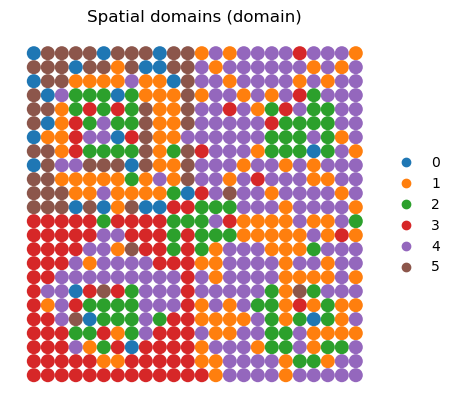

In [14]:
# 例如：在 ST 上分 8 个域
# use_multimodal=False -> 原来的 RNA-only
# use_multimodal=True  -> RNA + 第二模态(ADT/ATAC) 联合分域

adata_prep = assign_domains_only(
    adata_prep,
    k=6,
    beta=0.5,
    radius=20,
    use_raw=False,
    label_key='domain',

    # ===== 统一入口开关 =====
    use_multimodal=True,

    # ===== 多模态输入 =====
    adt_adata=adt_adata,
    mod2_kind='atac',      # 'adt' or 'atac'
    mod2_use_layer=None,
    mod2_do_clr=None,

    # ===== 特征参数 =====
    rna_n_pcs=30,
    mod2_dim=50,
    joint_pca_dim=20,      # 关键：建议显式设一个 joint PCA，减少 GMM 病态协方差

    # ===== 模态权重 =====
    rna_weight=1.0,
    mod2_weight=1.5,

    # ===== 更稳的 GMM 参数 =====
    gmm_covariance_type='auto',   # 自动 fallback: full -> diag -> tied
    gmm_reg_covar=1e-4,
    gmm_n_init=5,
)

import scanpy as sc
import pandas as pd

print("domain mode:", adata_prep.uns.get('domain_mode', 'unknown'))
print("domain feature info:", adata_prep.uns.get('domain_feature_info', {}))

if not pd.api.types.is_categorical_dtype(adata_prep.obs['domain']):
    adata_prep.obs['domain'] = adata_prep.obs['domain'].astype('category')

sc.pl.spatial(
    adata_prep,
    color='domain',
    spot_size=10,
    frameon=False,
    title='Spatial domains (domain)'
)


/tmp/ipykernel_26625/1873405371.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


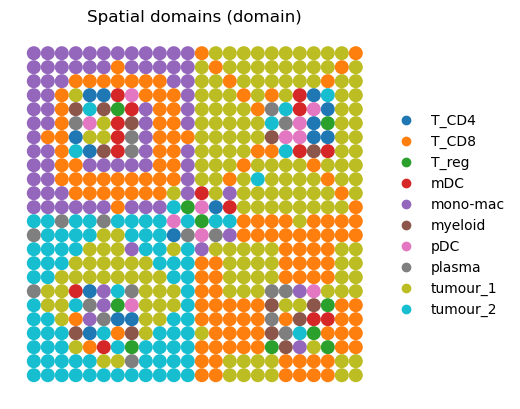

In [15]:
sc.pl.spatial(
    adata_prep,
    color='gt',
    spot_size=10,          # tune (0.5–2.5) depending on your coordinate scale
    frameon=False,
    title='Spatial domains (domain)'
)

In [16]:
# --- Model and deps ---
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gmean

import torch
import torch.nn as nn
import torch.nn.functional as F


# =====================
# 1) Prep data & graph
# =====================
def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)


def standardize_features(X):
    mu = X.mean(0, keepdims=True)
    sd = X.std(0, keepdims=True) + 1e-6
    return (X - mu) / sd


def build_knn_graph(coords, k=8, sigma=None):
    """
    coords: (N,D)
    k: neighbors per node (excluding self)
    sigma: if set, edge weight = exp(-d^2/(2*sigma^2)); else weight = 1
    returns normalized adjacency Â as torch.sparse_coo_tensor
    """
    N = coords.shape[0]
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='euclidean').fit(coords)
    dists, idx = nbrs.kneighbors(coords)

    rows = np.repeat(np.arange(N), k)
    cols = idx[:, 1:].ravel()

    if sigma is None:
        data = np.ones_like(rows, dtype=np.float32)
    else:
        data = np.exp(-(dists[:, 1:].ravel() ** 2) / (2.0 * sigma ** 2)).astype(np.float32)

    A = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=np.float32)
    A = A + A.T
    A.setdiag(1.0)

    deg = np.asarray(A.sum(1)).flatten()
    d_inv_sqrt = 1.0 / np.sqrt(deg + 1e-8)
    D_inv_sqrt = sp.diags(d_inv_sqrt.astype(np.float32))
    A_hat = (D_inv_sqrt @ A @ D_inv_sqrt).tocoo()

    indices = np.vstack([A_hat.row, A_hat.col])
    A_hat_t = torch.sparse_coo_tensor(
        indices, A_hat.data, (N, N), dtype=torch.float32
    ).coalesce()
    return A_hat_t


def build_batch_knn_subgraph_from_precomputed(
    batch_ids_np,
    knn_idx_np,
    knn_dist_np=None,
    sigma=None,
    device='cpu',
):
    """从预先计算好的全体 kNN（CPU numpy）里，构建 batch 内的归一化子图 Â。"""
    import numpy as _np
    import torch as _torch

    batch_ids_np = _np.asarray(batch_ids_np)
    B = int(batch_ids_np.shape[0])
    if B <= 0:
        raise ValueError('empty batch')

    N_total = int(knn_idx_np.shape[0])
    pos = _torch.full((N_total,), -1, dtype=_torch.int32)
    batch_ids_t = _torch.from_numpy(batch_ids_np.astype(_np.int64, copy=False))
    pos[batch_ids_t] = _torch.arange(B, dtype=_torch.int32)

    neigh = _torch.from_numpy(knn_idx_np[batch_ids_np].astype(_np.int64, copy=False))
    cols = pos[neigh]
    valid = cols >= 0

    rows = _torch.arange(B, dtype=_torch.int64).unsqueeze(1).expand_as(cols)
    row_idx = rows[valid]
    col_idx = cols[valid].to(_torch.int64)

    if (sigma is None) or (knn_dist_np is None):
        val = _torch.ones_like(row_idx, dtype=_torch.float32)
    else:
        d = _torch.from_numpy(knn_dist_np[batch_ids_np].astype(_np.float32, copy=False))
        d2 = (d[valid].to(_torch.float32)) ** 2
        val = _torch.exp(-d2 / (2.0 * float(sigma) ** 2))

    ii = _torch.cat([row_idx, col_idx], dim=0)
    jj = _torch.cat([col_idx, row_idx], dim=0)
    vv = _torch.cat([val, val], dim=0)

    self_idx = _torch.arange(B, dtype=_torch.int64)
    ii = _torch.cat([ii, self_idx], dim=0)
    jj = _torch.cat([jj, self_idx], dim=0)
    vv = _torch.cat([vv, _torch.ones(B, dtype=_torch.float32)], dim=0)

    A = _torch.sparse_coo_tensor(
        _torch.stack([ii, jj], dim=0), vv, (B, B), dtype=_torch.float32
    ).coalesce()

    deg = _torch.zeros(B, dtype=_torch.float32)
    deg.scatter_add_(0, A.indices()[0], A.values())
    d_inv_sqrt = _torch.rsqrt(deg + 1e-8)
    norm_val = A.values() * d_inv_sqrt[A.indices()[0]] * d_inv_sqrt[A.indices()[1]]

    A_hat = _torch.sparse_coo_tensor(
        A.indices(), norm_val, (B, B), dtype=_torch.float32
    ).coalesce()
    return A_hat.to(device)


# =========================
# 2) Loss helpers / templates
# =========================
def supcon_loss(z_proj, y, mask, tau=0.2):
    z = F.normalize(z_proj[mask], dim=1)
    y_lab = y[mask]
    if z.size(0) <= 1:
        return torch.tensor(0.0, device=z_proj.device)

    sim = torch.matmul(z, z.T) / tau
    sim = sim - torch.max(sim, dim=1, keepdim=True).values

    same = (y_lab.unsqueeze(0) == y_lab.unsqueeze(1))
    eye = torch.eye(same.size(0), dtype=torch.bool, device=z.device)
    pos_mask = same & (~eye)

    exp_sim = torch.exp(sim) * (~eye)
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    num = (exp_sim * pos_mask).sum(dim=1) + 1e-12

    valid = pos_mask.any(dim=1)
    if valid.float().sum() == 0:
        return torch.tensor(0.0, device=z.device)

    loss_i = -torch.log(num / denom).masked_select(valid)
    return loss_i.mean()


class CenterLoss(nn.Module):
    def __init__(self, n_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.zeros(n_classes, feat_dim))

    def forward(self, z, y, mask):
        z_lab = z[mask]
        y_lab = y[mask]
        if z_lab.size(0) == 0:
            return torch.tensor(0.0, device=z.device)
        c = self.centers.index_select(0, y_lab)
        return ((z_lab - c) ** 2).sum(dim=1).mean()


def mmd_rbf(x: torch.Tensor, y: torch.Tensor, gammas=(0.5, 1.0, 2.0, 4.0, 8.0)):
    x2 = torch.cdist(x, x, p=2).pow(2)
    y2 = torch.cdist(y, y, p=2).pow(2)
    xy2 = torch.cdist(x, y, p=2).pow(2)

    Kxx = 0.0
    Kyy = 0.0
    Kxy = 0.0
    for g in gammas:
        Kxx = Kxx + torch.exp(-g * x2)
        Kyy = Kyy + torch.exp(-g * y2)
        Kxy = Kxy + torch.exp(-g * xy2)

    Bx = x.shape[0]
    By = y.shape[0]
    if Bx > 1:
        Kxx = (Kxx.sum() - Kxx.diag().sum()) / (Bx * (Bx - 1))
    else:
        Kxx = Kxx.mean()
    if By > 1:
        Kyy = (Kyy.sum() - Kyy.diag().sum()) / (By * (By - 1))
    else:
        Kyy = Kyy.mean()

    Kxy = Kxy.mean()
    return Kxx + Kyy - 2 * Kxy


def coral_loss_efficient(x: torch.Tensor, y: torch.Tensor, eps=1e-5, batch_size=5000):
    x_centered = x - x.mean(dim=0, keepdim=True)
    y_centered = y - y.mean(dim=0, keepdim=True)

    Cx = torch.zeros(x.shape[1], x.shape[1], device=x.device)
    Cy = torch.zeros(y.shape[1], y.shape[1], device=y.device)

    for i in range(0, x.shape[0], batch_size):
        end = min(i + batch_size, x.shape[0])
        batch_x = x_centered[i:end]
        Cx += batch_x.T @ batch_x

    for i in range(0, y.shape[0], batch_size):
        end = min(i + batch_size, y.shape[0])
        batch_y = y_centered[i:end]
        Cy += batch_y.T @ batch_y

    Cx = Cx / (x.shape[0] - 1 + eps)
    Cy = Cy / (y.shape[0] - 1 + eps)

    return ((Cx - Cy).pow(2).sum()) / (4.0 * x.shape[1] * x.shape[1])


def coral_loss(x: torch.Tensor, y: torch.Tensor, eps=1e-5):
    if x.shape[0] > 10000 or y.shape[0] > 10000:
        return coral_loss_efficient(x, y, eps, batch_size=5000)

    x = x - x.mean(dim=0, keepdim=True)
    y = y - y.mean(dim=0, keepdim=True)
    Bx = x.shape[0]
    By = y.shape[0]
    Cx = (x.T @ x) / (Bx - 1 + eps)
    Cy = (y.T @ y) / (By - 1 + eps)
    d = x.shape[1]
    return ((Cx - Cy).pow(2).sum()) / (4.0 * d * d)


def make_srt_template(adata_srt, use_layer=None):
    X_srt_raw = _to_dense(adata_srt.layers[use_layer] if use_layer else adata_srt.X).astype(np.float32)
    genes_srt = pd.Index(adata_srt.var_names)

    mu_srt = X_srt_raw.mean(axis=0).astype(np.float32)
    sd_srt = (X_srt_raw.std(axis=0) + 1e-6).astype(np.float32)
    X_srt_std = ((X_srt_raw - mu_srt) / sd_srt).astype(np.float32)
    return X_srt_std, mu_srt, sd_srt, list(genes_srt)


def align_sc_to_srt_template(sc_adata, genes_srt, mu_srt, sd_srt,
                             sc_use_layer=None, fill_missing='srt_mean'):
    X_sc_raw = _to_dense(sc_adata.layers[sc_use_layer] if sc_use_layer else sc_adata.X).astype(np.float32)
    genes_sc = pd.Index(sc_adata.var_names)

    genes_srt = pd.Index(genes_srt)
    mu_srt = np.asarray(mu_srt, dtype=np.float32)
    sd_srt = np.asarray(sd_srt, dtype=np.float32)

    map_idx = genes_sc.get_indexer(genes_srt)

    N_sc, F_srt = X_sc_raw.shape[0], len(genes_srt)
    if fill_missing == 'srt_mean':
        base = np.broadcast_to(mu_srt, (N_sc, F_srt)).copy()
    elif fill_missing == 'zero':
        base = np.zeros((N_sc, F_srt), dtype=np.float32)
    else:
        fill_val = np.asarray(fill_missing, dtype=np.float32)
        if fill_val.size == 1:
            base = np.full((N_sc, F_srt), float(fill_val), dtype=np.float32)
        else:
            assert fill_val.shape[0] == F_srt
            base = np.broadcast_to(fill_val, (N_sc, F_srt)).copy()

    present_mask = (map_idx >= 0)
    if present_mask.any():
        base[:, present_mask] = X_sc_raw[:, map_idx[present_mask]]

    X_sc_std = ((base - mu_srt) / sd_srt).astype(np.float32)
    return X_sc_std, present_mask


def clr_normalization(matrix: np.ndarray) -> np.ndarray:
    mat = matrix.astype(np.float32, copy=True)
    mat = np.maximum(mat, 1e-10)
    row_gmeans = gmean(mat, axis=1, keepdims=True)
    return np.log(mat / row_gmeans).astype(np.float32, copy=False)


# =========================
# 3) Model
# =========================
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=True)
        self.dropout = dropout

    def forward(self, A_hat, X):
        X = F.dropout(X, p=self.dropout, training=self.training)
        XW = self.lin(X)
        if XW.dtype != torch.float32:
            XW = XW.float()
        if A_hat.dtype != torch.float32:
            A_hat = A_hat.float()
        H = torch.sparse.mm(A_hat, XW)
        return F.relu(H)


class GraphAutoencoder(nn.Module):
    def __init__(self, in_dim, hid_dim=64, z_dim=16, n_classes=5, dropout=0.1, proj_dim=32):
        super().__init__()
        self.enc1 = GCNLayer(in_dim, hid_dim, dropout=dropout)
        self.enc2 = GCNLayer(hid_dim, z_dim, dropout=dropout)
        self.dec_recon = nn.Linear(z_dim, in_dim)
        self.dec_cls = nn.Linear(z_dim, n_classes)
        self.proj = nn.Sequential(
            nn.Linear(z_dim, z_dim),
            nn.ReLU(inplace=True),
            nn.Linear(z_dim, proj_dim)
        )

    def forward(self, A_hat, X):
        h = self.enc1(A_hat, X)
        z = self.enc2(A_hat, h)
        x_hat = self.dec_recon(z)
        logits = self.dec_cls(z)
        z_proj = self.proj(z)
        return z, z_proj, x_hat, logits


class ResidualGatedFusion(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.mod2_proj = nn.Linear(z_dim, z_dim)
        self.gate = nn.Sequential(
            nn.Linear(2 * z_dim, z_dim),
            nn.ReLU(),
            nn.Linear(z_dim, z_dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(z_dim)

    def forward(self, z_rna, z_mod2):
        z_mod2 = self.mod2_proj(z_mod2)
        gate = self.gate(torch.cat([z_rna, z_mod2], dim=1))
        z_fused = z_rna + gate * z_mod2
        return self.norm(z_fused)


CrossModalityFusion = ResidualGatedFusion


class SRTMultimodalWrapper(nn.Module):
    def __init__(self, F_rna, F_mod2, hid_dim, z_dim, n_classes, dropout=0.1, proj_dim=32):
        super().__init__()
        head_dim = max(n_classes, 2)

        self.rna = GraphAutoencoder(
            in_dim=F_rna,
            hid_dim=hid_dim,
            z_dim=z_dim,
            n_classes=head_dim,
            dropout=dropout,
            proj_dim=proj_dim
        )
        self.mod2 = GraphAutoencoder(
            in_dim=F_mod2,
            hid_dim=hid_dim,
            z_dim=z_dim,
            n_classes=head_dim,
            dropout=dropout,
            proj_dim=proj_dim
        )

        self.fuse = ResidualGatedFusion(z_dim)

        self.cls_fused = nn.Linear(z_dim, head_dim)
        self.cls_rna = nn.Linear(z_dim, head_dim)

        self.proj_fused = nn.Sequential(
            nn.Linear(z_dim, z_dim),
            nn.ReLU(inplace=True),
            nn.Linear(z_dim, proj_dim)
        )

    def forward_srt(self, A_hat, X_rna, X_mod2):
        z_rna, _, x_hat_rna, _ = self.rna(A_hat, X_rna)
        z_mod2, _, x_hat_mod2, _ = self.mod2(A_hat, X_mod2)

        z_fused = self.fuse(z_rna, z_mod2)
        logits_fused = self.cls_fused(z_fused)
        logits_rna = self.cls_rna(z_rna)
        z_proj_fused = self.proj_fused(z_fused)

        return z_fused, z_proj_fused, logits_fused, x_hat_rna, x_hat_mod2, z_rna, z_mod2, logits_rna

    def forward_sc(self, A_hat_sc, X_sc):
        z_sc, z_proj_sc, x_hat_sc, _ = self.rna(A_hat_sc, X_sc)
        logits_sc = self.cls_rna(z_sc)
        return z_sc, z_proj_sc, logits_sc, x_hat_sc

    def forward(self, *args):
        if len(args) == 2:
            z_sc, z_proj_sc, logits_sc, x_hat_sc = self.forward_sc(*args)
            return z_sc, z_proj_sc, x_hat_sc, logits_sc
        elif len(args) == 3:
            return self.forward_srt(*args)
        else:
            raise ValueError(f"Unexpected number of args: {len(args)}")


def kd_loss(student_logits, teacher_logits, T=2.0):
    p_teacher = F.softmax(teacher_logits.detach() / T, dim=1)
    log_p_student = F.log_softmax(student_logits / T, dim=1)
    return F.kl_div(log_p_student, p_teacher, reduction='batchmean') * (T * T)


In [17]:
import torch.nn.functional as F

def _safe_n_components(n_obs, n_vars, requested_dim):
    if n_obs <= 1 or n_vars <= 1:
        return 1
    return int(max(1, min(int(requested_dim), int(n_obs - 1), int(n_vars - 1))))

def _preprocess_mod2_features(
    adata_mod2,
    mod2_kind='adt',
    use_layer=None,
    do_clr=True,
    out_dim=50,
    random_state=0,
):
    """
    第二模态预处理:
    - ADT : CLR -> z-score -> PCA
    - ATAC: TF-IDF -> log1p -> TruncatedSVD(LSI) -> z-score
    """
    from sklearn.decomposition import PCA, TruncatedSVD

    mod2_kind = str(mod2_kind).lower()
    if mod2_kind not in {'adt', 'atac'}:
        raise ValueError(f"mod2_kind must be 'adt' or 'atac', got {mod2_kind!r}")

    X_raw = adata_mod2.layers[use_layer] if (use_layer is not None) else adata_mod2.X

    if mod2_kind == 'adt':
        X_raw = _to_dense(X_raw).astype(np.float32)
        if do_clr:
            X_raw = clr_normalization(X_raw)

        mu = X_raw.mean(axis=0, keepdims=True).astype(np.float32)
        sd = (X_raw.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)
        X_std = ((X_raw - mu) / sd).astype(np.float32, copy=False)

        n_comp = _safe_n_components(X_std.shape[0], X_std.shape[1], out_dim)
        pca = PCA(n_components=n_comp, random_state=random_state, svd_solver='randomized')
        X_feat = pca.fit_transform(np.asarray(X_std)).astype(np.float32, copy=False)

        meta = {
            'mod2_kind': 'adt',
            'mod2_use_layer': use_layer,
            'mod2_do_clr': bool(do_clr),
            'mod2_n_comp': int(n_comp),
            'mod2_mu': mu.squeeze(0),
            'mod2_sd': sd.squeeze(0),
        }
        return X_feat, meta

    # ===== ATAC =====
    if sp.issparse(X_raw):
        X_sp = X_raw.tocsr().astype(np.float32)
    else:
        X_sp = sp.csr_matrix(np.asarray(X_raw, dtype=np.float32))

    row_sum = np.asarray(X_sp.sum(axis=1)).ravel().astype(np.float32)
    row_sum[row_sum <= 0] = 1.0
    tf = sp.diags(1.0 / row_sum) @ X_sp

    df = np.asarray((X_sp > 0).sum(axis=0)).ravel().astype(np.float32)
    idf = np.log(1.0 + X_sp.shape[0] / (df + 1.0)).astype(np.float32)

    tfidf = tf @ sp.diags(idf)
    tfidf = tfidf.tocsr()
    if tfidf.nnz > 0:
        tfidf.data = np.log1p(tfidf.data * 1e4).astype(np.float32, copy=False)

    n_comp = _safe_n_components(tfidf.shape[0], tfidf.shape[1], out_dim)
    svd = TruncatedSVD(n_components=n_comp, random_state=random_state)
    X_feat = svd.fit_transform(tfidf).astype(np.float32, copy=False)

    mu_feat = X_feat.mean(axis=0, keepdims=True).astype(np.float32)
    sd_feat = (X_feat.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)
    X_feat = ((X_feat - mu_feat) / sd_feat).astype(np.float32, copy=False)

    meta = {
        'mod2_kind': 'atac',
        'mod2_use_layer': use_layer,
        'mod2_do_clr': False,
        'mod2_n_comp': int(n_comp),
        'mod2_lsi_mu': mu_feat.squeeze(0),
        'mod2_lsi_sd': sd_feat.squeeze(0),
    }
    return X_feat, meta


def train_srt_gae(
    adata, sc_adata,
    adt_adata=None,                 # 兼容旧名字，实际表示第二模态
    use_layer='log1p',
    adt_use_layer=None,             # 不写时默认直接用 .X
    adt_do_clr=None,                # NEW: None 时根据 mod2_kind 自动决定
    mod2_kind='adt',                # 'adt' or 'atac'
    k=8, sigma=None,
    hid_dim=64, z_dim=16,
    lr=1e-3, weight_decay=1e-4,
    epochs=200,
    alpha=1.0,
    alpha_adt=1.0,
    beta=1.0,
    gamma=0.1,
    lam_con=1.0,
    lam_center=0.1,
    lam_decov=1e-3,
    tau=0.2,
    treat_unknown_as_unlabeled=True, unknown_label='Unknown',
    lam_mmd=0.1, lam_coral=0.1,
    lam_bal=0,
    lam_bal_1=0.1,
    lam_ctdom=0.0005,
    verbose=True,
    pca_dim=50,
    pca_dim_adt=None,               # ADT 时是 PCA dim；ATAC 时是 LSI dim
    use_amp=False,
    svd_if_sparse=True,
    pca_random_state=0,
    batch_size_srt=None,
    batch_size_sc=None,
    sc_knn_k=15,
    sc_knn_sigma=None,
    grad_accum_steps=1,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mod2_kind = str(mod2_kind).lower()
    if mod2_kind not in {'adt', 'atac'}:
        raise ValueError(f"mod2_kind must be 'adt' or 'atac', got {mod2_kind!r}")

    # 自动决定第二模态是否 CLR
    if adt_do_clr is None:
        adt_do_clr = (mod2_kind == 'adt')
    elif mod2_kind == 'atac':
        adt_do_clr = False

    # =========================
    # 单模态：尽量保持原逻辑
    # =========================
    if adt_adata is None:
        if use_layer is not None:
            import scanpy as sc
            for _ad in (adata, sc_adata):
                if use_layer not in _ad.layers:
                    _tmp = _ad.copy()
                    sc.pp.normalize_total(_tmp, target_sum=1e4)
                    sc.pp.log1p(_tmp)
                    _ad.layers[use_layer] = _tmp.X.copy()
                    del _tmp

        X_srt_std, mu_srt, sd_srt, genes_srt = make_srt_template(adata, use_layer=use_layer)
        X_sc_std, present_mask = align_sc_to_srt_template(
            sc_adata, genes_srt, mu_srt, sd_srt,
            sc_use_layer=use_layer, fill_missing='srt_mean'
        )

        from sklearn.decomposition import PCA, TruncatedSVD
        from sklearn.preprocessing import StandardScaler

        if X_srt_std.shape[1] <= 1:
            n_comp = 1
        else:
            n_comp = int(min(pca_dim, X_srt_std.shape[1] - 1))

        if svd_if_sparse and sp.issparse(X_srt_std):
            scaler = StandardScaler(with_mean=False)
            Xs = scaler.fit_transform(X_srt_std)
            Xc = scaler.transform(X_sc_std)
            svd = TruncatedSVD(n_components=n_comp, random_state=pca_random_state)
            X_srt_feat = svd.fit_transform(Xs).astype(np.float32, copy=False)
            X_sc_feat = svd.transform(Xc).astype(np.float32, copy=False)
        else:
            pca = PCA(n_components=n_comp, random_state=pca_random_state, svd_solver='randomized')
            X_srt_feat = pca.fit_transform(np.asarray(X_srt_std)).astype(np.float32, copy=False)
            X_sc_feat = pca.transform(np.asarray(X_sc_std)).astype(np.float32, copy=False)

        X = torch.from_numpy(X_srt_feat).to(device=device, non_blocking=True)
        X_sc_feat_cpu = np.asarray(X_sc_feat, dtype=np.float32, order='C')

        N, F_X = X.shape
        N_sc = int(X_sc_feat_cpu.shape[0])

        if batch_size_sc is None or batch_size_sc >= N_sc:
            batch_size_sc = N_sc

        nbrs_sc = NearestNeighbors(n_neighbors=int(sc_knn_k) + 1, metric='euclidean').fit(X_sc_feat_cpu)
        sc_dists_full, sc_idx_full = nbrs_sc.kneighbors(X_sc_feat_cpu)
        sc_knn_idx = sc_idx_full[:, 1:].astype(np.int64, copy=False)
        sc_knn_dist = sc_dists_full[:, 1:].astype(np.float32, copy=False)

        if 'cellType' in sc_adata.obs:
            ct_sc = sc_adata.obs['cellType'].astype('category')
            ct_classes = list(ct_sc.cat.categories)
            ct_codes = ct_sc.cat.codes.to_numpy().astype(np.int64, copy=False)
            has_ct_label = True
        else:
            ct_codes = None
            ct_classes = None
            has_ct_label = False

        coords = np.asarray(adata.obsm['spatial'])
        A_hat = build_knn_graph(coords, k=k, sigma=sigma).to(device)

        gt = adata.obs['domain'].astype('category')
        if unknown_label in gt.cat.categories:
            gt = gt.cat.remove_categories([unknown_label])

        mask_labeled = ~gt.isna().to_numpy()
        y_codes = gt.cat.codes.to_numpy().astype(np.int64)
        classes = list(gt.cat.categories)
        n_classes = len(classes)

        y = torch.tensor(y_codes, device=device, dtype=torch.long)
        mask = torch.tensor(mask_labeled, dtype=torch.bool, device=device)

        model = GraphAutoencoder(
            in_dim=F_X, hid_dim=hid_dim, z_dim=z_dim,
            n_classes=n_classes, dropout=0.1, proj_dim=32
        ).to(device)

        center_crit = CenterLoss(n_classes=n_classes, feat_dim=z_dim).to(device)
        opt = torch.optim.Adam([
            {'params': model.parameters(), 'lr': lr, 'weight_decay': weight_decay},
            {'params': center_crit.parameters(), 'lr': lr * 0.5, 'weight_decay': 0.0}
        ])

        use_amp = bool(use_amp and (device.type == 'cuda'))
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

        adata.uns['gae_template'] = {
            'use_layer': use_layer,
            'genes_srt': genes_srt,
            'mu_srt': mu_srt,
            'sd_srt': sd_srt,
        }
        adata.uns['gae_classes'] = list(classes)

        for epoch in range(1, epochs + 1):
            model.train()
            epoch_loss = 0.0
            num_batches = 0
            opt.zero_grad(set_to_none=True)

            for step in range(grad_accum_steps):
                if batch_size_sc < N_sc:
                    batch_sc_ids = np.random.choice(N_sc, size=int(batch_size_sc), replace=False).astype(np.int64)
                else:
                    batch_sc_ids = np.arange(N_sc, dtype=np.int64)

                X_sc_batch = torch.from_numpy(X_sc_feat_cpu[batch_sc_ids]).to(device=device, non_blocking=True)
                A_hat_sc_batch = build_batch_knn_subgraph_from_precomputed(
                    batch_sc_ids,
                    sc_knn_idx,
                    knn_dist_np=sc_knn_dist,
                    sigma=sc_knn_sigma,
                    device=device,
                )

                if has_ct_label and (ct_codes is not None):
                    ct_batch = torch.from_numpy(ct_codes[batch_sc_ids]).to(device=device, non_blocking=True)
                else:
                    ct_batch = None

                with torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16):
                    z, z_proj, x_hat, logits = model(A_hat, X)
                    z_sc, z_proj_sc, x_hat_sc, logits_sc = model(A_hat_sc_batch, X_sc_batch)

                    loss_recon = F.mse_loss(x_hat, X)

                    lab = y_codes[mask_labeled]
                    counts = np.bincount(lab, minlength=n_classes).astype(np.float32)
                    freq = counts / max(counts.sum(), 1.0)
                    w = 1.0 / (freq + 1e-6)
                    w = w / w.mean()
                    ce_weight = torch.tensor(w, device=device, dtype=torch.float32)

                    if mask.any():
                        loss_cls = F.cross_entropy(logits[mask], y[mask], weight=ce_weight)
                        loss_con = supcon_loss(z_proj, y, mask, tau=tau)
                        loss_ctr = center_crit(z, y, mask)
                    else:
                        loss_cls = torch.tensor(0.0, device=device)
                        loss_con = torch.tensor(0.0, device=device)
                        loss_ctr = torch.tensor(0.0, device=device)

                    z_smooth = z.float() if z.dtype != torch.float32 else z
                    A_hat_smooth = A_hat.float() if A_hat.dtype != torch.float32 else A_hat
                    smooth = torch.sparse.mm(A_hat_smooth, z_smooth) - z_smooth
                    loss_smooth = (smooth * smooth).sum() / N

                    if lam_decov > 0:
                        zc = z - z.mean(dim=0, keepdim=True)
                        C = (zc.T @ zc) / (N - 1)
                        decov = (C - torch.diag(torch.diag(C))).pow(2).mean()
                    else:
                        decov = torch.tensor(0.0, device=device)

                    mmd_loss_val = mmd_rbf(z_proj, z_proj_sc)
                    coral_loss_val = coral_loss(z_proj, z_proj_sc)

                    prior = torch.tensor(freq, device=device)
                    prob = F.softmax(logits, dim=1)
                    p_mean = prob[mask].mean(dim=0) if mask.any() else prob.mean(dim=0)
                    loss_bal = ((p_mean - prior) ** 2).sum()
                    loss_bal_1 = F.kl_div((p_mean + 1e-8).log(), prior, reduction='sum')

                    if has_ct_label and lam_ctdom > 0 and (ct_batch is not None) and (ct_classes is not None):
                        prob_sc = F.softmax(logits_sc, dim=1)
                        K = prob_sc.size(1)
                        p_global = prob_sc.mean(dim=0)
                        p_uni = torch.full_like(p_global, 1.0 / K)
                        loss_marg = F.kl_div((p_global + 1e-8).log(), p_uni, reduction='sum')

                        p_ct_list = []
                        ent_list = []
                        for t_id in range(len(ct_classes)):
                            mask_t = (ct_batch == t_id)
                            if mask_t.sum() < 20:
                                continue
                            p_t = prob_sc[mask_t].mean(dim=0)
                            p_ct_list.append(p_t)
                            ent_list.append(-(p_t * (p_t + 1e-8).log()).sum())

                        if len(p_ct_list) >= 2:
                            ent_cond = torch.stack(ent_list).mean()
                            pair_dist = 0.0
                            cnt = 0
                            for i in range(len(p_ct_list)):
                                for j in range(i + 1, len(p_ct_list)):
                                    pair_dist += ((p_ct_list[i] - p_ct_list[j]) ** 2).mean()
                                    cnt += 1
                            pair_dist = pair_dist / cnt
                            loss_ctdom = ent_cond + loss_marg - pair_dist
                        else:
                            loss_ctdom = torch.tensor(0.0, device=device)
                    else:
                        loss_ctdom = torch.tensor(0.0, device=device)

                    loss = (
                        alpha * loss_recon
                        + beta * loss_cls
                        + gamma * loss_smooth
                        + lam_con * loss_con
                        + lam_center * loss_ctr
                        + lam_decov * decov
                        + lam_mmd * mmd_loss_val
                        + lam_coral * coral_loss_val
                        + lam_bal * loss_bal
                        + lam_bal_1 * loss_bal_1
                        + lam_ctdom * loss_ctdom
                    )

                loss = loss / grad_accum_steps
                epoch_loss += loss.item()
                num_batches += 1
                scaler.scale(loss).backward()

            scaler.step(opt)
            scaler.update()

            if verbose and epoch % 25 == 0:
                avg_loss = epoch_loss / max(num_batches, 1)
                print(f"Ep{epoch:03d} | L={avg_loss:.3f} (avg over {num_batches} batches)")

        model.eval()
        with torch.no_grad():
            z, z_proj, x_hat, logits = model(A_hat, X)
            pred = logits.argmax(1).detach().cpu().numpy()

        adata.obsm['gae_latent'] = z.detach().cpu().numpy().astype(np.float32)
        x_hat_np = x_hat.detach().cpu().numpy().astype(np.float32)
        if x_hat_np.shape[1] == adata.n_vars:
            adata.layers['gae_recon'] = x_hat_np
        else:
            adata.obsm['gae_recon_feat'] = x_hat_np

        adata.obs['pred_gt'] = pd.Categorical.from_codes(pred, classes)
        return model, sc_knn_idx

    # =========================
    # 多模态：RNA + second modality
    # =========================
    common_spots = adata.obs_names.intersection(adt_adata.obs_names)
    if len(common_spots) == 0:
        raise ValueError("adata 与第二模态 adt_adata 没有共同的 obs_names（spots）。")

    idx_rna = adata.obs_names.get_indexer(common_spots)
    idx_mod2 = adt_adata.obs_names.get_indexer(common_spots)

    adata_mm = adata[idx_rna].copy()
    mod2_mm = adt_adata[idx_mod2].copy()

    if use_layer is not None:
        import scanpy as sc
        for _ad in (adata_mm, sc_adata):
            if use_layer not in _ad.layers:
                _tmp = _ad.copy()
                sc.pp.normalize_total(_tmp, target_sum=1e4)
                sc.pp.log1p(_tmp)
                _ad.layers[use_layer] = _tmp.X.copy()
                del _tmp

    X_srt_std, mu_srt, sd_srt, genes_srt = make_srt_template(adata_mm, use_layer=use_layer)
    X_sc_std, present_mask = align_sc_to_srt_template(
        sc_adata, genes_srt, mu_srt, sd_srt,
        sc_use_layer=use_layer, fill_missing='srt_mean'
    )

    from sklearn.decomposition import PCA, TruncatedSVD
    from sklearn.preprocessing import StandardScaler

    n_comp_rna = int(min(pca_dim, X_srt_std.shape[1] - 1)) if X_srt_std.shape[1] > 1 else 1
    if svd_if_sparse and sp.issparse(X_srt_std):
        scaler = StandardScaler(with_mean=False)
        Xs = scaler.fit_transform(X_srt_std)
        Xc = scaler.transform(X_sc_std)
        svd = TruncatedSVD(n_components=n_comp_rna, random_state=pca_random_state)
        X_srt_feat = svd.fit_transform(Xs).astype(np.float32, copy=False)
        X_sc_feat = svd.transform(Xc).astype(np.float32, copy=False)
    else:
        pca = PCA(n_components=n_comp_rna, random_state=pca_random_state, svd_solver='randomized')
        X_srt_feat = pca.fit_transform(np.asarray(X_srt_std)).astype(np.float32, copy=False)
        X_sc_feat = pca.transform(np.asarray(X_sc_std)).astype(np.float32, copy=False)

    mod2_dim = int(pca_dim if (pca_dim_adt is None) else pca_dim_adt)
    X_mod2_feat, mod2_meta = _preprocess_mod2_features(
        mod2_mm,
        mod2_kind=mod2_kind,
        use_layer=adt_use_layer,
        do_clr=adt_do_clr,
        out_dim=mod2_dim,
        random_state=pca_random_state,
    )

    X_rna = torch.from_numpy(X_srt_feat).to(device=device, non_blocking=True)
    X_mod2 = torch.from_numpy(X_mod2_feat).to(device=device, non_blocking=True)

    X_sc_feat_cpu = np.asarray(X_sc_feat, dtype=np.float32, order='C')
    N = X_rna.shape[0]
    N_sc = int(X_sc_feat_cpu.shape[0])

    if batch_size_sc is None or batch_size_sc >= N_sc:
        batch_size_sc = N_sc

    nbrs_sc = NearestNeighbors(n_neighbors=int(sc_knn_k) + 1, metric='euclidean').fit(X_sc_feat_cpu)
    sc_dists_full, sc_idx_full = nbrs_sc.kneighbors(X_sc_feat_cpu)
    sc_knn_idx = sc_idx_full[:, 1:].astype(np.int64, copy=False)
    sc_knn_dist = sc_dists_full[:, 1:].astype(np.float32, copy=False)

    coords = np.asarray(adata_mm.obsm['spatial'])
    A_hat = build_knn_graph(coords, k=k, sigma=sigma).to(device)

    gt = adata_mm.obs['domain'].astype('category')
    if unknown_label in gt.cat.categories:
        gt = gt.cat.remove_categories([unknown_label])

    mask_labeled = ~gt.isna().to_numpy()
    y_codes = gt.cat.codes.to_numpy().astype(np.int64)
    classes = list(gt.cat.categories)
    n_classes = len(classes)

    y = torch.tensor(y_codes, device=device, dtype=torch.long)
    mask = torch.tensor(mask_labeled, dtype=torch.bool, device=device)

    model = SRTMultimodalWrapper(
        F_rna=X_rna.shape[1],
        F_mod2=X_mod2.shape[1],
        hid_dim=hid_dim,
        z_dim=z_dim,
        n_classes=n_classes,
        dropout=0.1,
        proj_dim=32
    ).to(device)

    center_crit = CenterLoss(n_classes=n_classes, feat_dim=z_dim).to(device)
    opt = torch.optim.Adam([
        {'params': model.parameters(), 'lr': lr, 'weight_decay': weight_decay},
        {'params': center_crit.parameters(), 'lr': lr * 0.5, 'weight_decay': 0.0}
    ])

    use_amp = bool(use_amp and (device.type == 'cuda'))
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    adata.uns['gae_template'] = {
        'use_layer': use_layer,
        'genes_srt': genes_srt,
        'mu_srt': mu_srt,
        'sd_srt': sd_srt,
        'common_spots': list(common_spots),
        'mod2_kind': mod2_kind,
        'mod2_use_layer': adt_use_layer,
        'mod2_n_comp': int(mod2_meta['mod2_n_comp']),
        'mod2_do_clr': bool(mod2_meta['mod2_do_clr']),
    }
    adata.uns['gae_classes'] = list(classes)

    if mod2_kind == 'adt':
        adata.uns['gae_template']['mod2_mu'] = mod2_meta['mod2_mu']
        adata.uns['gae_template']['mod2_sd'] = mod2_meta['mod2_sd']
    else:
        adata.uns['gae_template']['mod2_lsi_mu'] = mod2_meta['mod2_lsi_mu']
        adata.uns['gae_template']['mod2_lsi_sd'] = mod2_meta['mod2_lsi_sd']

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        opt.zero_grad(set_to_none=True)

        for step in range(grad_accum_steps):
            with torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16):
                z_fused, z_proj_fused, logits_fused, x_hat_rna, x_hat_mod2, z_rna, z_mod2, logits_rna = model.forward_srt(
                    A_hat, X_rna, X_mod2
                )

                loss_recon_rna = F.mse_loss(x_hat_rna, X_rna)
                loss_recon_mod2 = F.mse_loss(x_hat_mod2, X_mod2)

                lab = y_codes[mask_labeled]
                counts = np.bincount(lab, minlength=n_classes).astype(np.float32)
                freq = counts / max(counts.sum(), 1.0)
                w = 1.0 / (freq + 1e-6)
                w = w / w.mean()
                ce_weight = torch.tensor(w, device=device, dtype=torch.float32)

                if mask.any():
                    loss_cls_fused = F.cross_entropy(logits_fused[mask], y[mask], weight=ce_weight)
                    loss_cls_rna = F.cross_entropy(logits_rna[mask], y[mask], weight=ce_weight)
                    loss_kd_val = kd_loss(logits_rna[mask], logits_fused[mask], T=2.0)
                    loss_con = supcon_loss(z_proj_fused, y, mask, tau=tau)
                    loss_ctr = center_crit(z_fused, y, mask)
                else:
                    loss_cls_fused = torch.tensor(0.0, device=device)
                    loss_cls_rna = torch.tensor(0.0, device=device)
                    loss_kd_val = torch.tensor(0.0, device=device)
                    loss_con = torch.tensor(0.0, device=device)
                    loss_ctr = torch.tensor(0.0, device=device)

                z_smooth = z_fused.float() if z_fused.dtype != torch.float32 else z_fused
                A_hat_smooth = A_hat.float() if A_hat.dtype != torch.float32 else A_hat
                smooth = torch.sparse.mm(A_hat_smooth, z_smooth) - z_smooth
                loss_smooth = (smooth * smooth).sum() / N

                if lam_decov > 0:
                    zc = z_fused - z_fused.mean(dim=0, keepdim=True)
                    C = (zc.T @ zc) / (N - 1)
                    decov = (C - torch.diag(torch.diag(C))).pow(2).mean()
                else:
                    decov = torch.tensor(0.0, device=device)

                loss = (
                    alpha * loss_recon_rna
                    + alpha_adt * loss_recon_mod2
                    + beta * loss_cls_fused
                    + 0.5 * beta * loss_cls_rna
                    + 0.5 * beta * loss_kd_val
                    + gamma * loss_smooth
                    + lam_con * loss_con
                    + lam_center * loss_ctr
                    + lam_decov * decov
                )

            loss = loss / grad_accum_steps
            epoch_loss += loss.item()
            num_batches += 1
            scaler.scale(loss).backward()

        scaler.step(opt)
        scaler.update()

        if verbose and epoch % 25 == 0:
            avg_loss = epoch_loss / max(num_batches, 1)
            print(f"Ep{epoch:03d} | L={avg_loss:.3f} (avg over {num_batches} batches)")

    model.eval()
    with torch.no_grad():
        z_fused, z_proj_fused, logits_fused, x_hat_rna, x_hat_mod2, z_rna, z_mod2, logits_rna = model.forward_srt(
            A_hat, X_rna, X_mod2
        )
        pred = logits_fused.argmax(1).detach().cpu().numpy()

    z_fused_np = z_fused.detach().cpu().numpy().astype(np.float32)
    z_rna_np = z_rna.detach().cpu().numpy().astype(np.float32)
    z_mod2_np = z_mod2.detach().cpu().numpy().astype(np.float32)

    z_full = np.full((adata.n_obs, z_dim), np.nan, dtype=np.float32)
    z_full[idx_rna] = z_fused_np
    adata.obsm['gae_latent'] = z_full

    z_full_rna = np.full((adata.n_obs, z_dim), np.nan, dtype=np.float32)
    z_full_rna[idx_rna] = z_rna_np
    adata.obsm['gae_latent_rna'] = z_full_rna

    z_full_mod2 = np.full((adt_adata.n_obs, z_dim), np.nan, dtype=np.float32)
    z_full_mod2[idx_mod2] = z_mod2_np
    adt_adata.obsm['gae_latent_mod2'] = z_full_mod2
    if mod2_kind == 'adt':
        adt_adata.obsm['gae_latent_adt'] = z_full_mod2
    else:
        adt_adata.obsm['gae_latent_atac'] = z_full_mod2

    pred_labels = np.array([None] * adata.n_obs, dtype=object)
    for i, p in zip(idx_rna, pred):
        pred_labels[i] = classes[p]
    adata.obs['pred_gt'] = pd.Categorical(pred_labels, categories=classes)

    return model, sc_knn_idx


In [18]:
#### Model training
# If your adata is raw counts, first do:
# import scanpy as sc
# sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata)

model, sc_knn_idx = train_srt_gae(
    adata_prep, sc_adata, adt_adata,
    use_layer='log1p',     # or the name of your normalized/log1p layer
    mod2_kind='atac',      # ADT ATAC 切换 预处理
    k=6, sigma=None,       # SRT 空间图参数
    hid_dim=128, z_dim=32,
    epochs=2024, alpha=1.0, beta=1.0, gamma=0.1,
    batch_size_sc=512,     # 关键：把 scRNA 改成 mini-batch（256/512 都可以）
    sc_knn_k=15,           # scRNA 在低维特征空间预计算 kNN
    sc_knn_sigma=None,
    treat_unknown_as_unlabeled=True, unknown_label='Unknown',
    lam_mmd=0.1, lam_coral=0,
    lam_bal=0,
    lam_bal_1=0.1,
    lam_ctdom=0.0005,
    verbose=True,
    pca_dim=50,
    pca_dim_adt=None,
    use_amp=False,
    svd_if_sparse=True,
    pca_random_state=0,
    batch_size_srt=None,
    grad_accum_steps=1
)

# Results:
# - adata.obsm['gae_latent'] : (N, z_dim) embedding
# - adata.layers['gae_recon'] or adata.obsm['gae_recon_feat']
# - adata.obs['pred_gt']     : predicted domain label


/tmp/ipykernel_26625/469075454.py:481: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_26625/469075454.py:510: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16):
/tmp/ipykernel_26625/1098153790.py:130: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.ht

Ep025 | L=18.729 (avg over 1 batches)
Ep050 | L=17.722 (avg over 1 batches)
Ep075 | L=16.530 (avg over 1 batches)
Ep100 | L=15.654 (avg over 1 batches)
Ep125 | L=14.930 (avg over 1 batches)
Ep150 | L=14.292 (avg over 1 batches)
Ep175 | L=13.767 (avg over 1 batches)
Ep200 | L=13.285 (avg over 1 batches)
Ep225 | L=12.863 (avg over 1 batches)
Ep250 | L=12.658 (avg over 1 batches)
Ep275 | L=12.292 (avg over 1 batches)
Ep300 | L=12.040 (avg over 1 batches)
Ep325 | L=11.855 (avg over 1 batches)
Ep350 | L=11.638 (avg over 1 batches)
Ep375 | L=11.504 (avg over 1 batches)
Ep400 | L=11.482 (avg over 1 batches)
Ep425 | L=11.240 (avg over 1 batches)
Ep450 | L=11.140 (avg over 1 batches)
Ep475 | L=10.988 (avg over 1 batches)
Ep500 | L=10.910 (avg over 1 batches)
Ep525 | L=10.728 (avg over 1 batches)
Ep550 | L=10.790 (avg over 1 batches)
Ep575 | L=10.871 (avg over 1 batches)
Ep600 | L=10.695 (avg over 1 batches)
Ep625 | L=10.659 (avg over 1 batches)
Ep650 | L=10.557 (avg over 1 batches)
Ep675 | L=10

In [21]:
adata, sc_adata,adt_adata, adata_prep

(AnnData object with n_obs × n_vars = 576 × 90052
     obs: 'cell_count', 'region_id', 'second_sampling', 'gt'
     uns: 'density', 'proportion_names'
     obsm: 'proportions', 'spatial',
 AnnData object with n_obs × n_vars = 1717 × 90052
     obs: 'spot_id', 'cell_type', 'CellType'
     obsm: 'spatial'
     layers: 'log1p',
 AnnData object with n_obs × n_vars = 576 × 53451
     obs: 'cell_count', 'region_id'
     uns: 'density', 'proportion_names'
     obsm: 'proportions', 'spatial', 'gae_latent_mod2', 'gae_latent_atac',
 AnnData object with n_obs × n_vars = 576 × 1000
     obs: 'cell_count', 'region_id', 'second_sampling', 'gt', 'domain', 'pred_gt'
     var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'density', 'proportion_names', 'log1p', 'hvg', 'domain_domain_genes', 'domain_mode', 'domain_common_spots', 'domain_feature_info', 'domain_colors', 'gt_colors', 'gae_template', 'gae_classes'
     obsm: 'proportions', 'spatial', 'gae_

/opt/micromamba/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 16:22:15.008344: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 16:22:15.062299: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 16:22:16.462516: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slig

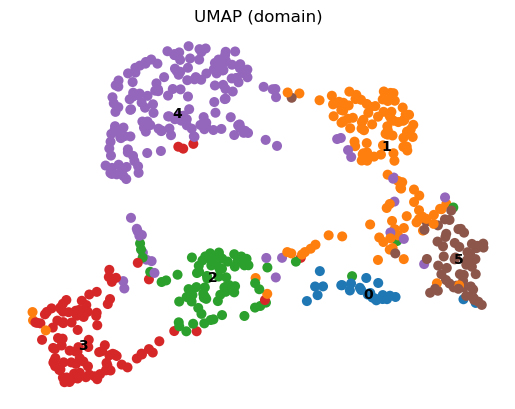

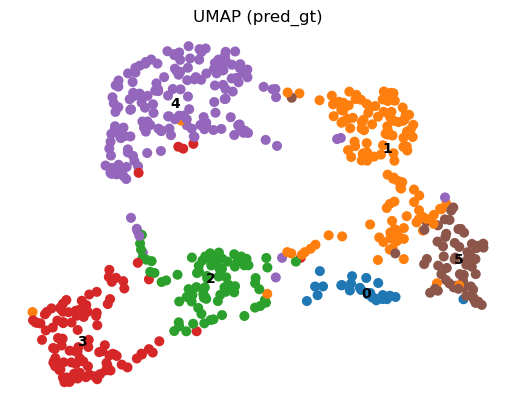

In [22]:
import scanpy as sc
import numpy as np
import pandas as pd
####DEBUG ::: add single cell mapping info?
### sc_adata.obs.cellType? umap

# Ensure your model run saved this:
Z = adata_prep.obsm.get('gae_latent')
assert Z is not None, "No embedding found at adata.obsm['gae_latent']"

# UMAP from the embedding
sc.pp.neighbors(adata_prep, use_rep='gae_latent', n_neighbors=15, metric='cosine')
sc.tl.umap(adata_prep, min_dist=0.3, spread=1.0)

for col in ['domain', 'pred_gt']:
    if col in adata_prep.obs and not pd.api.types.is_categorical_dtype(adata_prep.obs[col]):
        adata_prep.obs[col] = adata.obs[col].astype('category')

# Ground-truth domain
sc.pl.umap(adata_prep, color='domain', frameon=False, legend_loc='on data', title='UMAP (domain)')

# If you also have model predictions from the decoder:
if 'pred_gt' in adata_prep.obs:
    sc.pl.umap(adata_prep, color='pred_gt', frameon=False, legend_loc='on data', title='UMAP (pred_gt)')

In [23]:
print('pred_domain' in sc_adata.obs.columns)
print('CellType'   in sc_adata.obs.columns)


False
True


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_celltype_by_pred_domain(adata, ct_key='cellType', dom_key='pred_domain',
                                 sort_by_total=True, figsize=(8,4), annotate=False):
    """
    Stacked bar plot:
      - x-axis: cell types
      - bar height: #cells per cell type
      - colored segments: counts of each pred_domain within the cell type
    """
    # sanity checks
    if ct_key not in adata.obs or dom_key not in adata.obs:
        raise KeyError(f"'{ct_key}' or '{dom_key}' not found in adata.obs")

    ct = adata.obs[ct_key].astype('category')
    dom = adata.obs[dom_key].astype('category')

    # counts matrix: rows=cellType, cols=pred_domain
    M = pd.crosstab(ct, dom).astype(int)

    # order cell types by total count
    totals = M.sum(axis=1)
    if sort_by_total:
        M = M.loc[totals.sort_values(ascending=False).index]
        totals = totals.loc[M.index]

    # colors (one color per domain)
    K = M.shape[1]
    cmap = ListedColormap(plt.cm.tab20.colors[:K])
    dom_colors = {d: cmap(i) for i, d in enumerate(M.columns)}

    # plot
    ax = plt.figure(figsize=figsize).gca()
    bottom = np.zeros(M.shape[0], dtype=float)
    x = np.arange(M.shape[0])

    for j, d in enumerate(M.columns):
        vals = M[d].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=dom_colors[d], label=str(d), width=0.8, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in M.index], rotation=45, ha='right')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'Cells per {ct_key} colored by {dom_key}')
    ax.legend(title=dom_key, bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
    ax.set_xlim(-0.6, len(x)-0.4)

    # optional annotations: show totals on top or percentages inside segments
    if annotate:
        for i, total in enumerate(totals):
            ax.text(i, total + max(totals)*0.01, str(total), ha='center', va='bottom', fontsize=8)
        # Example for percent labels per segment (commented; can clutter):
        # for i in range(M.shape[0]):
        #     cum = 0
        #     for d in M.columns:
        #         v = M.iloc[i][d]
        #         if v > 0:
        #             ax.text(i, cum + v/2, f"{100*v/float(totals.iloc[i]):.0f}%", ha='center', va='center', fontsize=7, color='white')
        #         cum += v

    plt.tight_layout()
    plt.show()

In [25]:
# 对全量 scRNA 细胞先做一次“不建图（identity graph）”的快速临时预测，
# 再做均衡抽样，并在子集上按训练时同样的特征空间做正式推理。

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn.functional as F
import scanpy as sc

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)

def _build_identity_graph(n, device):
    idx = np.vstack([np.arange(n), np.arange(n)])
    return torch.sparse_coo_tensor(
        idx,
        np.ones(n, dtype=np.float32),
        (n, n),
        dtype=torch.float32,
        device=device,
    ).coalesce()

def _get_celltype_key(adata):
    for key in ['CellType', 'cellType']:
        if key in adata.obs:
            return key
    raise KeyError("sc_adata.obs 里没有 'CellType' 或 'cellType'。")

def _get_training_template(adata_train, train_layer='log1p'):
    if 'gae_template' not in adata_train.uns:
        raise KeyError("adata_train.uns['gae_template'] 不存在。请先重新运行 train_srt_gae(...)。")

    tpl = adata_train.uns['gae_template']
    use_layer = tpl.get('use_layer', train_layer)
    genes_srt = pd.Index(tpl['genes_srt'])
    mu_srt = np.asarray(tpl['mu_srt'], dtype=np.float32)
    sd_srt = np.asarray(tpl['sd_srt'], dtype=np.float32)

    common_spots = tpl.get('common_spots', None)
    if common_spots is not None:
        common_spots = pd.Index(common_spots)

    return use_layer, genes_srt, mu_srt, sd_srt, common_spots

def _infer_domain_classes(adata_train, unknown_label='Unknown'):
    if 'pred_gt' in adata_train.obs:
        ser = adata_train.obs['pred_gt'].astype('category')
        return list(ser.cat.categories)

    if 'domain' in adata_train.obs:
        ser = adata_train.obs['domain'].astype('category')
        if unknown_label in ser.cat.categories:
            ser = ser.cat.remove_categories([unknown_label])
        return list(ser.cat.categories)

    raise KeyError("无法从 adata_train.obs['pred_gt'] 或 adata_train.obs['domain'] 推断类别。")

def _ensure_layer(adata_obj, layer_name):
    if layer_name is None or layer_name in adata_obj.layers:
        return
    tmp = adata_obj.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    adata_obj.layers[layer_name] = tmp.X.copy()
    del tmp

def _fit_srt_reducer_from_training(
    adata_train,
    train_layer='log1p',
    pca_dim=50,
    svd_if_sparse=True,
    pca_random_state=0,
):
    use_layer, genes_srt, mu_srt, sd_srt, common_spots = _get_training_template(
        adata_train, train_layer=train_layer
    )

    if common_spots is not None and len(common_spots) > 0:
        common_spots = common_spots.intersection(adata_train.obs_names)
        adata_ref = adata_train[common_spots].copy()
    else:
        adata_ref = adata_train

    _ensure_layer(adata_ref, use_layer)

    X_srt_std, _ = align_sc_to_srt_template(
        adata_ref,
        genes_srt,
        mu_srt,
        sd_srt,
        sc_use_layer=use_layer,
        fill_missing='srt_mean'
    )

    if X_srt_std.shape[1] <= 1:
        n_comp = 1
    else:
        n_comp = int(min(pca_dim, X_srt_std.shape[1] - 1))

    prep = {
        'use_layer': use_layer,
        'genes_srt': genes_srt,
        'mu_srt': mu_srt,
        'sd_srt': sd_srt,
        'n_comp': n_comp,
        'kind': None,
        'scaler': None,
        'reducer': None,
    }

    if svd_if_sparse and sp.issparse(X_srt_std):
        scaler = StandardScaler(with_mean=False)
        Xs = scaler.fit_transform(X_srt_std)

        svd = TruncatedSVD(n_components=n_comp, random_state=pca_random_state)
        svd.fit(Xs)

        prep['kind'] = 'svd'
        prep['scaler'] = scaler
        prep['reducer'] = svd
    else:
        Xs = np.asarray(_to_dense(X_srt_std), dtype=np.float32)
        pca = PCA(n_components=n_comp, random_state=pca_random_state, svd_solver='randomized')
        pca.fit(Xs)

        prep['kind'] = 'pca'
        prep['reducer'] = pca

    return prep

def _transform_sc_like_training(sc_adata, prep):
    _ensure_layer(sc_adata, prep['use_layer'])

    X_sc_std, _ = align_sc_to_srt_template(
        sc_adata,
        prep['genes_srt'],
        prep['mu_srt'],
        prep['sd_srt'],
        sc_use_layer=prep['use_layer'],
        fill_missing='srt_mean'
    )

    if prep['kind'] == 'svd':
        Xc = prep['scaler'].transform(X_sc_std)
        X_feat = prep['reducer'].transform(Xc).astype(np.float32, copy=False)
    else:
        Xc = np.asarray(_to_dense(X_sc_std), dtype=np.float32)
        X_feat = prep['reducer'].transform(Xc).astype(np.float32, copy=False)

    return np.asarray(X_feat, dtype=np.float32, order='C')

def _forward_sc_compatible(model, A_sc, X_sc):
    if hasattr(model, 'forward_sc'):
        z_sc, z_proj_sc, logits_sc, x_hat_sc = model.forward_sc(A_sc, X_sc)
    else:
        z_sc, z_proj_sc, x_hat_sc, logits_sc = model(A_sc, X_sc)
    return z_sc, z_proj_sc, x_hat_sc, logits_sc

def _provisional_pred(
    sc_adata,
    adata_train,
    model,
    train_layer='log1p',
    target_sum=1e4,
    device=None,
    A_sc=None,
    pca_dim=50,
    svd_if_sparse=True,
    pca_random_state=0,
    unknown_label='Unknown',
):
    """
    用训练好的模型，对 sc_adata 全体细胞做一次快速临时预测。
    关键点：
    1. 复用训练时保存的 SRT 模板；
    2. 重新按训练时同样的 SRT 参考数据拟合 PCA/SVD；
    3. 直接走新的 forward_sc 语义。
    """
    if device is None:
        device = next(model.parameters()).device

    classes = _infer_domain_classes(adata_train, unknown_label=unknown_label)
    prep = _fit_srt_reducer_from_training(
        adata_train,
        train_layer=train_layer,
        pca_dim=pca_dim,
        svd_if_sparse=svd_if_sparse,
        pca_random_state=pca_random_state,
    )

    X_sc_feat = _transform_sc_like_training(sc_adata, prep)
    X_t = torch.from_numpy(X_sc_feat).to(device=device, non_blocking=True)

    if A_sc is None or (isinstance(A_sc, (int, float)) and A_sc == 0):
        A = _build_identity_graph(X_sc_feat.shape[0], device=device)
    else:
        A = A_sc.to(device)

    model.eval()
    with torch.no_grad():
        z_sc, z_proj_sc, x_hat_sc, logits_sc = _forward_sc_compatible(model, A, X_t)
        proba = F.softmax(logits_sc, dim=1).cpu().numpy()

    if proba.shape[1] != len(classes):
        print(f"警告: 模型输出维度 {proba.shape[1]} 与类别数 {len(classes)} 不匹配。")
        if proba.shape[1] > len(classes):
            proba = proba[:, :len(classes)]
        else:
            padded = np.zeros((proba.shape[0], len(classes)), dtype=np.float32)
            padded[:, :proba.shape[1]] = proba
            proba = padded

    pred_idx = proba.argmax(axis=1)
    pred_idx = np.clip(pred_idx, 0, len(classes) - 1)

    print(f"训练数据中的类别: {classes}")
    print(f"Logits 形状: {logits_sc.shape}")
    print("临时预测分布:")
    uniq, cnt = np.unique(pred_idx, return_counts=True)
    for i, c in zip(uniq, cnt):
        print(f"  类别 {classes[i]}: {c} 个细胞")

    return pred_idx, proba

def _balanced_indices_by_ct_and_pred(
    sc_adata, pred_idx, proba, classes,
    ct_key='CellType', max_per_type=500, domain_balance='equal', rng_seed=0
):
    """
    在 cellType × provisional domain 上做均衡抽样。
    """
    rng = np.random.default_rng(rng_seed)
    ct = sc_adata.obs[ct_key].astype('category')
    ct_cats = list(ct.cat.categories)
    dom_cats = list(classes)

    df = pd.DataFrame({
        'ct': ct.astype(str).values,
        'dom': pd.Categorical.from_codes(pred_idx, dom_cats).astype(str),
        'row': np.arange(sc_adata.n_obs)
    })

    prob_df = pd.DataFrame(proba, index=sc_adata.obs_names, columns=dom_cats)
    df['conf'] = prob_df.to_numpy()[np.arange(sc_adata.n_obs), pred_idx]

    A = df.groupby(['ct', 'dom']).size().unstack(fill_value=0).reindex(
        index=ct_cats, columns=dom_cats, fill_value=0
    )
    avail_ct = A.sum(axis=1)
    avail_dom = A.sum(axis=0)

    R = pd.Series({ct_: min(max_per_type, int(avail_ct[ct_])) for ct_ in ct_cats})
    total_target = int(R.sum())
    if total_target == 0:
        raise ValueError("No available cells to sample with the requested constraints.")

    if domain_balance == 'equal':
        base = total_target // len(dom_cats)
        C = pd.Series({d: min(int(avail_dom[d]), base) for d in dom_cats})
        rem = total_target - int(C.sum())
        if rem > 0:
            order = sorted(dom_cats, key=lambda d: avail_dom[d] - C[d], reverse=True)
            for d in order:
                if rem == 0:
                    break
                if C[d] < avail_dom[d]:
                    C[d] += 1
                    rem -= 1
    elif domain_balance == 'proportional':
        C = (avail_dom / avail_dom.sum() * total_target).round().astype(int)
        over = (C - avail_dom).clip(lower=0)
        C -= over
        diff = total_target - int(C.sum())
        if diff > 0:
            order = (avail_dom - C).sort_values(ascending=False).index
            for d in order:
                if diff == 0:
                    break
                if C[d] < avail_dom[d]:
                    C[d] += 1
                    diff -= 1
        elif diff < 0:
            order = C.sort_values(ascending=False).index
            for d in order:
                if diff == 0:
                    break
                if C[d] > 0:
                    C[d] -= 1
                    diff += 1
    else:
        raise ValueError("domain_balance must be 'equal' or 'proportional'.")

    P_row = A.div(A.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    Q = (P_row.mul(R, axis=0)).round().astype(int)
    Q = np.minimum(Q, A)

    row_def = (R - Q.sum(axis=1)).astype(int)
    for ct_ in ct_cats:
        deficit = int(row_def.get(ct_, 0))
        if deficit <= 0:
            continue
        room = (A.loc[ct_] - Q.loc[ct_]).clip(lower=0)
        order = room.sort_values(ascending=False).index
        for d in order:
            if deficit == 0:
                break
            add = min(deficit, int(room[d]))
            Q.loc[ct_, d] += add
            deficit -= add

    col_def = (C - Q.sum(axis=0)).astype(int)
    for d in dom_cats:
        deficit = int(col_def.get(d, 0))
        if deficit <= 0:
            continue
        room_ct = (A[d] - Q[d]).clip(lower=0)
        slack_ct = (R - Q.sum(axis=1)).clip(lower=0)
        score = (pd.concat([room_ct, slack_ct], axis=1).min(axis=1)).sort_values(ascending=False)
        for ct_ in score.index:
            if deficit == 0:
                break
            can = int(min(room_ct[ct_], slack_ct[ct_]))
            if can <= 0:
                continue
            add = min(deficit, can)
            Q.loc[ct_, d] += add
            deficit -= add

    Q = np.minimum(Q, A)

    keep = []
    grouped = df.groupby(['ct', 'dom'], sort=False)
    for ct_ in ct_cats:
        for d in dom_cats:
            need = int(Q.loc[ct_, d]) if (ct_ in Q.index and d in Q.columns) else 0
            if need <= 0:
                continue
            if (ct_, d) not in grouped.groups:
                continue
            rows = grouped.get_group((ct_, d)).sort_values('conf', ascending=False)['row'].to_numpy()
            keep.append(rows[:need])

    if not keep:
        raise ValueError("No cells selected after balancing—check availability and targets.")

    keep_idx = np.sort(np.concatenate(keep))
    return keep_idx

def embed_and_predict_sc(
    sc_adata,
    adata_train,
    model,
    train_layer='log1p',
    k_sc=8,
    target_sum=1e4,
    use_identity_graph=False,
    max_per_type=1000,
    rng_seed=0,
    domain_balance='equal',
    A_sc=None,
    pca_dim=50,
    svd_if_sparse=True,
    pca_random_state=0,
    unknown_label='Unknown',
):
    device = next(model.parameters()).device
    model.eval()

    classes = _infer_domain_classes(adata_train, unknown_label=unknown_label)
    ct_key = _get_celltype_key(sc_adata)

    prep = _fit_srt_reducer_from_training(
        adata_train,
        train_layer=train_layer,
        pca_dim=pca_dim,
        svd_if_sparse=svd_if_sparse,
        pca_random_state=pca_random_state,
    )

    # ---- PASS 1: provisional predictions on ALL cells ----
    pred_idx_full, proba_full = _provisional_pred(
        sc_adata=sc_adata,
        adata_train=adata_train,
        model=model,
        train_layer=train_layer,
        target_sum=target_sum,
        device=device,
        A_sc=A_sc,
        pca_dim=pca_dim,
        svd_if_sparse=svd_if_sparse,
        pca_random_state=pca_random_state,
        unknown_label=unknown_label,
    )

    # ---- Balanced subset across cellType and provisional pred_domain ----
    keep_idx = _balanced_indices_by_ct_and_pred(
        sc_adata,
        pred_idx_full,
        proba_full,
        classes,
        ct_key=ct_key,
        max_per_type=max_per_type,
        domain_balance=domain_balance,
        rng_seed=rng_seed,
    )
    sc_sub = sc_adata[keep_idx].copy()

    pred_idx_prelim_sub = pred_idx_full[keep_idx]
    proba_prelim_sub = proba_full[keep_idx, :]

    sc_sub.obs['pred_domain_prelim'] = pd.Categorical.from_codes(
        pred_idx_prelim_sub,
        classes
    )

    # ---- PASS 2: features in the SAME training space ----
    X_full_feat = _transform_sc_like_training(sc_adata, prep)
    X_sub_feat = X_full_feat[keep_idx]
    X_t = torch.from_numpy(X_sub_feat).to(device=device, non_blocking=True)

    if use_identity_graph:
        A_sub = _build_identity_graph(X_sub_feat.shape[0], device=device)
    else:
        A_sub = build_knn_graph(X_sub_feat, k=k_sc, sigma=None).to(device)

    with torch.no_grad():
        z_sc, z_proj_sc, x_hat_sc, logits_sc = _forward_sc_compatible(model, A_sub, X_t)
        prob_sc = F.softmax(logits_sc, dim=1).cpu().numpy()

    if prob_sc.shape[1] != len(classes):
        print(f"警告: 模型输出维度 {prob_sc.shape[1]} 与类别数 {len(classes)} 不匹配。")
        if prob_sc.shape[1] > len(classes):
            prob_sc = prob_sc[:, :len(classes)]
        else:
            new_prob_sc = np.zeros((prob_sc.shape[0], len(classes)), dtype=np.float32)
            new_prob_sc[:, :prob_sc.shape[1]] = prob_sc
            prob_sc = new_prob_sc

    pred_idx_pass2 = prob_sc.argmax(axis=1)

    print(f"PASS2 logits 形状: {logits_sc.shape}")
    print(f"PASS2 概率矩阵形状: {prob_sc.shape}")
    print(f"PASS2 预测索引范围: {pred_idx_pass2.min()} 到 {pred_idx_pass2.max()}")

    # ---- PASS2 之后的兜底修正 ----
    pred_idx_final = pred_idx_pass2.copy()

    dom_counts_pass2 = np.bincount(pred_idx_pass2, minlength=len(classes))
    min_cells_default = 20
    min_cells_per_domain_final = {name: min_cells_default for name in classes}
    if 'domain1' in min_cells_per_domain_final:
        min_cells_per_domain_final['domain1'] = 50

    for d, dom_name in enumerate(classes):
        target_min = min_cells_per_domain_final.get(dom_name, min_cells_default)
        current = int(dom_counts_pass2[d])

        if current >= target_min:
            continue

        mask_sub = (pred_idx_prelim_sub == d)
        if not np.any(mask_sub):
            continue

        cand_idx_sub = np.where(mask_sub)[0]
        scores = proba_prelim_sub[cand_idx_sub, d]
        order = np.argsort(scores)[::-1]
        cand_idx_sub = cand_idx_sub[order]

        need_extra = target_min - current
        rescued = 0

        for idx_sub in cand_idx_sub:
            if rescued >= need_extra:
                break
            if pred_idx_final[idx_sub] == d:
                continue
            pred_idx_final[idx_sub] = d
            rescued += 1

    # ---- write outputs ----
    sc_sub.obsm['gae_latent'] = z_sc.cpu().numpy().astype(np.float32)
    sc_sub.obs['pred_domain'] = pd.Categorical.from_codes(pred_idx_final, classes)
    sc_sub.obsm['pred_domain_proba'] = pd.DataFrame(
        prob_sc,
        index=sc_sub.obs_names,
        columns=classes,
    )

    ct_counts = sc_sub.obs[ct_key].value_counts().to_dict()
    dom_counts = sc_sub.obs['pred_domain'].value_counts().to_dict()
    sc_sub.uns['subsample_info'] = {
        'strategy': 'balanced_ct_x_pred_domain',
        'max_per_type': int(max_per_type),
        'domain_balance': domain_balance,
        'rng_seed': int(rng_seed),
        'celltype_key': ct_key,
        'kept_counts_by_cellType': ct_counts,
        'kept_counts_by_pred_domain': dom_counts,
    }

    print("最终预测分布:")
    for i, dom_name in enumerate(classes):
        count = np.sum(pred_idx_final == i)
        print(f"  类别 {dom_name}: {count} 个细胞")

    return sc_sub


In [26]:
def make_srt_template(adata, use_layer='log1p'):
    """
    从训练数据创建模板：标准化表达矩阵、均值、标准差和基因列表
    """
    # 获取表达矩阵
    if use_layer in adata.layers:
        X = adata.layers[use_layer]
    else:
        X = adata.X
    
    # 转换为密集数组
    X_dense = _to_dense(X)
    
    # 计算均值和标准差
    mu = X_dense.mean(axis=0, keepdims=True).astype(np.float32)
    sd = X_dense.std(axis=0, keepdims=True).astype(np.float32) + 1e-6
    
    # 标准化
    X_std = (X_dense - mu) / sd
    
    # 获取基因列表
    genes = adata.var_names.tolist()
    
    return X_std, mu.ravel(), sd.ravel(), genes

GAE classes: ['0', '1', '2', '3', '4', '5']
训练数据中的类别: ['0', '1', '2', '3', '4', '5']
Logits 形状: torch.Size([1717, 6])
临时预测分布:
  类别 0: 46 个细胞
  类别 1: 68 个细胞
  类别 2: 20 个细胞
  类别 3: 960 个细胞
  类别 4: 331 个细胞
  类别 5: 292 个细胞
预测结果统计:
pred_domain
3    960
4    331
5    292
1     68
0     46
2     20
Name: count, dtype: int64


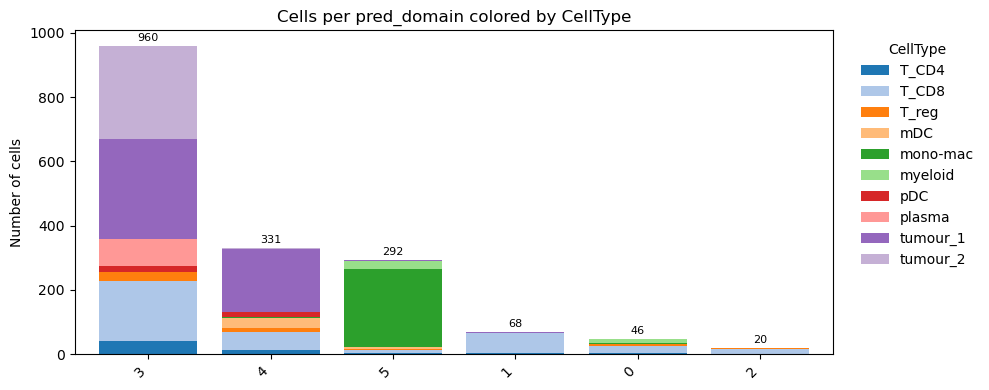

In [27]:
import numpy as np
import pandas as pd
import torch
import scanpy as sc

# ========= 0. 指定训练用的空间数据 =========
adata_train = adata_prep

# ========= 1. 确保训练数据里有 log1p =========
if "log1p" not in adata_train.layers:
    ad_tmp = adata_train.copy()
    sc.pp.normalize_total(ad_tmp, target_sum=1e4)
    sc.pp.log1p(ad_tmp)
    adata_train.layers["log1p"] = ad_tmp.X.copy()
    del ad_tmp

# ========= 2. 定义 domain 类别顺序（要和训练时一致）=========
if "gae_classes" in adata_train.uns:
    classes = list(adata_train.uns["gae_classes"])
else:
    # 尝试从训练数据中获取类别
    if "domain" in adata_train.obs.columns:
        label_key = "domain"
        classes = list(adata_train.obs[label_key].astype("category").cat.categories)
    elif "pred_gt" in adata_train.obs.columns:
        label_key = "pred_gt"
        classes = list(adata_train.obs[label_key].astype("category").cat.categories)
    else:
        # 如果都没有，先设为空，让模型推断
        classes = []

print("GAE classes:", classes)

# ========= 3. 给 sc_adata 建 identity graph（全细胞；简单可靠）=========
device = next(model.parameters()).device

N = sc_adata.n_obs
idx = np.vstack([np.arange(N), np.arange(N)])
A_sc = torch.sparse_coo_tensor(
    idx,
    np.ones(N, dtype=np.float32),
    (N, N),
    dtype=torch.float32,
).coalesce()

# ========= 4. 用 _provisional_pred 对"全体 sc 细胞"做预测 =========
pred_idx_full, proba_full = _provisional_pred(
    sc_adata=sc_adata,
    adata_train=adata_train,
    model=model,
    train_layer="log1p",
    target_sum=1e4,
    device=device,
    A_sc=A_sc,
)

# ========= 5. 如果 classes 为空，从预测结果推断 =========
if not classes:
    # 从预测结果中获取唯一的预测值
    unique_preds = np.unique(pred_idx_full)
    classes = [str(i) for i in range(int(unique_preds.max()) + 1)]
    print(f"从预测结果推断的类别: {classes}")

# ========= 6. 确保预测索引在有效范围内 =========
if len(classes) > 0:
    pred_idx_full = np.clip(pred_idx_full, 0, len(classes)-1)

# ========= 7. 写回 sc_adata.obs =========
sc_adata.obs["pred_domain"] = pd.Categorical.from_codes(pred_idx_full, classes)

# 确保概率矩阵维度正确
if proba_full.shape[1] > len(classes):
    proba_full = proba_full[:, :len(classes)]
elif proba_full.shape[1] < len(classes):
    # 填充零
    padded_proba = np.zeros((proba_full.shape[0], len(classes)))
    padded_proba[:, :proba_full.shape[1]] = proba_full
    proba_full = padded_proba

sc_adata.obsm["pred_domain_proba"] = pd.DataFrame(
    proba_full,
    index=sc_adata.obs_names,
    columns=classes,
)

print("预测结果统计:")
print(sc_adata.obs["pred_domain"].value_counts())

# ========= 8. 全细胞统计图（每个 domain 的 cellType 构成）=========
plot_celltype_by_pred_domain(
    sc_adata,
    ct_key="pred_domain",   # x 轴: 预测 domain
    dom_key="CellType",     # 颜色: cellType
    sort_by_total=True,
    figsize=(10, 4),
    annotate=True,
)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def plot_spatial_pies(
    st_adata,
    spot_type_prop,                  # DataFrame: index = spot ids, columns = cell types, values in [0,1]
    coord_key='spatial',             # st_adata.obsm key with (x,y) coords
    radius=15,                       # pie radius in data units (adjust for your slide scale)
    alpha=0.95,
    max_types_per_spot=None,         # e.g., 4 -> keep top-4 types per spot for readability
    celltype_colors=None,            # dict {cell_type: color}; else auto palette
    background='white',              # background color of axes
    edgecolor='none',                # pie edge color
    linewidth=0.0,
    legend=True,
    figsize=(8, 10)
):
    # --- align and fetch coordinates ---
    coords = np.asarray(st_adata.obsm[coord_key])[:, :2]
    spot_index = st_adata.obs_names
    # align rows to st_adata order
    prop = spot_type_prop.reindex(spot_index).fillna(0.0).copy()

    # normalize rows to sum=1 (safety)
    s = prop.sum(axis=1).replace(0, np.nan)
    prop = prop.div(s, axis=0).fillna(0.0)

    cell_types = prop.columns.tolist()

    # --- colors ---
    if celltype_colors is None:
        # auto palette
        #import matplotlib.cm as cm
        #cmap = cm.get_cmap('tab20', len(cell_types))
        #个人修改
        import matplotlib.pyplot as plt  # 改用 pyplot
        cmap = plt.get_cmap('tab20', len(cell_types))  # plt.get_cmap 替代 cm.get_cmap
        #
        celltype_colors = {ct: cmap(i) for i, ct in enumerate(cell_types)}
    colors = [celltype_colors[ct] for ct in cell_types]

    # --- helper to create wedges for one spot ---
    def wedges_for_row(center, proportions):
        vals = proportions.values.astype(float)
        if max_types_per_spot is not None and max_types_per_spot < len(vals):
            # keep only top-k and renormalize
            topk = np.argpartition(-vals, max_types_per_spot-1)[:max_types_per_spot]
            mask = np.zeros_like(vals, dtype=bool); mask[topk] = True
            vals = np.where(mask, vals, 0.0)
            total = vals.sum()
            vals = vals / total if total > 0 else vals

        # build wedges (angles in degrees)
        wedges = []
        start = 0.0
        for frac, col in zip(vals, colors):
            if frac <= 0:
                continue
            theta = frac * 360.0
            wedges.append(Wedge(center, r=radius, theta1=start, theta2=start+theta, facecolor=col,
                                edgecolor=edgecolor, linewidth=linewidth))
            start += theta
        return wedges

    # --- make all pies ---
    patches = []
    for (x, y), (_, row) in zip(coords, prop.iterrows()):
        patches.extend(wedges_for_row((x, y), row))

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor(background)
    pc = PatchCollection(patches, match_original=True, alpha=alpha)
    ax.add_collection(pc)

    # axes limits to fit all pies
    xmin, ymin = coords.min(axis=0) - radius*1.2
    xmax, ymax = coords.max(axis=0) + radius*1.2
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymax, ymin)  # flip y if your image origin is top-left
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('Spot-wise cell-type proportions (pie charts)')

    # legend
    if legend:
        # dummy handles
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=celltype_colors[ct], label=ct) for ct in cell_types]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title='Cell type')

    plt.tight_layout()
    plt.show()
    return fig, ax


In [29]:
# 查看 sc_adata.obs 的前几行数据
print("sc_adata.obs 的前5行数据:")
print(sc_adata.obs.head())

# 查看所有的列名
print("\nsc_adata.obs 的所有列名:")
print(sc_adata.obs.columns.tolist())

# 查看每个列的数据类型
print("\nsc_adata.obs 各列数据类型:")
print(sc_adata.obs.dtypes)

# 查找包含 'cell' 或 'type' 的列名
celltype_columns = [col for col in sc_adata.obs.columns if 'cell' in col.lower() or 'type' in col.lower()]
print(f"\n可能包含细胞类型信息的列: {celltype_columns}")

# 如果有找到候选列，查看它们的前几个唯一值
for col in celltype_columns:
    print(f"\n列 '{col}' 的唯一值统计:")
    print(f"  数据类型: {sc_adata.obs[col].dtype}")
    unique_vals = sc_adata.obs[col].astype(str).unique()
    print(f"  唯一值数量: {len(unique_vals)}")
    print(f"  前10个唯一值: {unique_vals[:10]}")
    # 如果是category类型，显示所有类别
    if str(sc_adata.obs[col].dtype) == 'category':
        print(f"  所有类别: {list(sc_adata.obs[col].cat.categories)}")

# 查看是否有 'pred_domain' 列（这是另一个我们要用的列）
if 'pred_domain' in sc_adata.obs.columns:
    print(f"\n'pred_domain' 列的唯一值统计:")
    print(f"  数据类型: {sc_adata.obs['pred_domain'].dtype}")
    unique_vals = sc_adata.obs['pred_domain'].astype(str).unique()
    print(f"  唯一值数量: {len(unique_vals)}")
    print(f"  前10个唯一值: {unique_vals[:10]}")
    # 如果是category类型，显示所有类别
    if str(sc_adata.obs['pred_domain'].dtype) == 'category':
        print(f"  所有类别: {list(sc_adata.obs['pred_domain'].cat.categories)}")
else:
    print("\n警告: 'pred_domain' 列不存在于 sc_adata.obs 中")

# 对于所有category类型的列，显示每个列中有多少种类的值
print("\n所有category类型的列及其类别数量:")
category_columns = sc_adata.obs.select_dtypes(include=['category']).columns
if len(category_columns) > 0:
    for col in category_columns:
        n_categories = len(sc_adata.obs[col].cat.categories)
        print(f"  '{col}': {n_categories} 个类别")
        print(f"    类别列表: {list(sc_adata.obs[col].cat.categories)}")
else:
    print("  没有category类型的列")

# 对于所有object/string类型的列，显示每个列中有多少不同的值
print("\n所有object/string类型的列及其唯一值数量:")
object_columns = sc_adata.obs.select_dtypes(include=['object']).columns
if len(object_columns) > 0:
    for col in object_columns:
        n_unique = sc_adata.obs[col].nunique()
        print(f"  '{col}': {n_unique} 个不同值")
        print(f"    前5个值: {list(sc_adata.obs[col].unique()[:5])}")
else:
    print("  没有object类型的列")

sc_adata.obs 的前5行数据:
     spot_id cell_type  CellType pred_domain
0_1        0  mono-mac  mono-mac           5
1_11       1  mono-mac  mono-mac           5
1_16       1  mono-mac  mono-mac           5
1_17       1  mono-mac  mono-mac           5
2_23       2  mono-mac  mono-mac           5

sc_adata.obs 的所有列名:
['spot_id', 'cell_type', 'CellType', 'pred_domain']

sc_adata.obs 各列数据类型:
spot_id        category
cell_type      category
CellType       category
pred_domain    category
dtype: object

可能包含细胞类型信息的列: ['cell_type', 'CellType']

列 'cell_type' 的唯一值统计:
  数据类型: category
  唯一值数量: 10
  前10个唯一值: ['mono-mac' 'T_CD4' 'T_CD8' 'tumour_2' 'tumour_1' 'T_reg' 'pDC' 'myeloid'
 'plasma' 'mDC']
  所有类别: ['T_CD4', 'T_CD8', 'T_reg', 'mDC', 'mono-mac', 'myeloid', 'pDC', 'plasma', 'tumour_1', 'tumour_2']

列 'CellType' 的唯一值统计:
  数据类型: category
  唯一值数量: 10
  前10个唯一值: ['mono-mac' 'T_CD4' 'T_CD8' 'tumour_2' 'tumour_1' 'T_reg' 'pDC' 'myeloid'
 'plasma' 'mDC']
  所有类别: ['T_CD4', 'T_CD8', 'T_reg', 'mDC', 'mono-

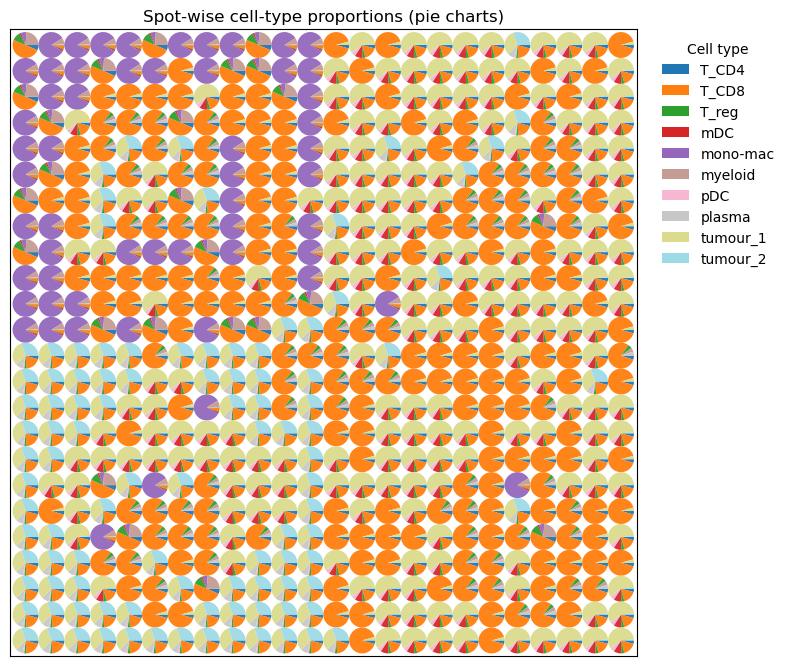

In [30]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'CellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


训练数据中的类别: ['0', '1', '2', '3', '4', '5']
Logits 形状: torch.Size([1717, 6])
临时预测分布:
  类别 0: 46 个细胞
  类别 1: 68 个细胞
  类别 2: 20 个细胞
  类别 3: 960 个细胞
  类别 4: 331 个细胞
  类别 5: 292 个细胞
PASS2 logits 形状: torch.Size([1707, 6])
PASS2 概率矩阵形状: (1707, 6)
PASS2 预测索引范围: 0 到 5
最终预测分布:
  类别 0: 29 个细胞
  类别 1: 62 个细胞
  类别 2: 20 个细胞
  类别 3: 994 个细胞
  类别 4: 333 个细胞
  类别 5: 269 个细胞
AnnData object with n_obs × n_vars = 1707 × 90052
    obs: 'spot_id', 'cell_type', 'CellType', 'pred_domain', 'pred_domain_prelim'
    uns: 'subsample_info'
    obsm: 'spatial', 'pred_domain_proba', 'gae_latent'
    layers: 'log1p'


/tmp/ipykernel_26625/2275875752.py:39: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):


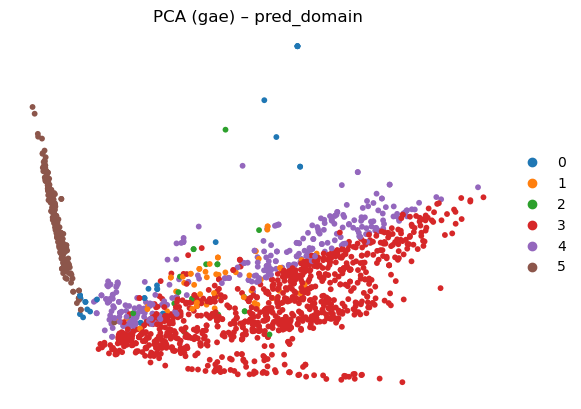

/tmp/ipykernel_26625/2275875752.py:39: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):


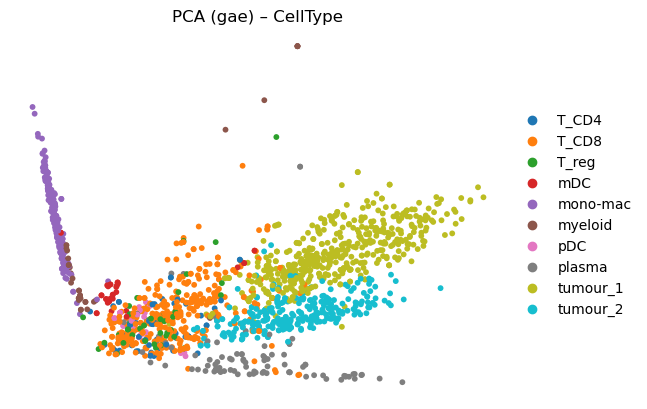

In [31]:
from sklearn.decomposition import PCA
import scanpy as sc
import anndata as ad

# 1. 读入 sc 数据
# sc_adata = ad.read_h5ad('/dongqishi/cellmap/MOB/MOB_sce.h5ad')

# 2. 确保有 log1p 层
if 'log1p' not in sc_adata.layers:
    tmp = sc_adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    sc_adata.layers['log1p'] = tmp.X.copy()
    del tmp

# 3. 用训练好的 model + adata_prep 做预测（不要传 model1/A_sc）
sc_adata = embed_and_predict_sc(
    sc_adata=sc_adata,
    adata_train=adata_prep,
    model=model,
    train_layer='log1p',
    k_sc=8,
    max_per_type=500,
    target_sum=1e4,
    use_identity_graph=False,   # 或者保持默认，关键是不传旧图
    A_sc=None
)

print(sc_adata)

# 4. 拿 embedding 做 PCA & 可视化
Z = sc_adata.obsm['gae_latent']

pca = PCA(n_components=20, random_state=0)
sc_adata.obsm['X_pca_gae'] = pca.fit_transform(Z)

for col in ['pred_domain', 'CellType']:
    if col in sc_adata.obs:
        if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):
            sc_adata.obs[col] = sc_adata.obs[col].astype('category')
        sc.pl.embedding(
            sc_adata,
            basis='pca_gae',
            color=col,
            frameon=False,
            title=f'PCA (gae) – {col}'
        )


Kept 1707 / 1707 cells (dropped 0).


/tmp/ipykernel_26625/1070417269.py:32: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):


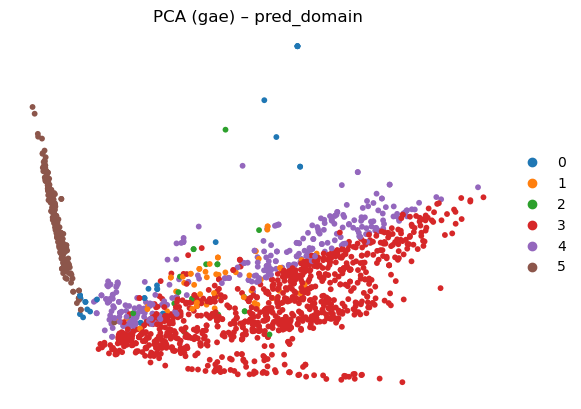

/tmp/ipykernel_26625/1070417269.py:32: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):


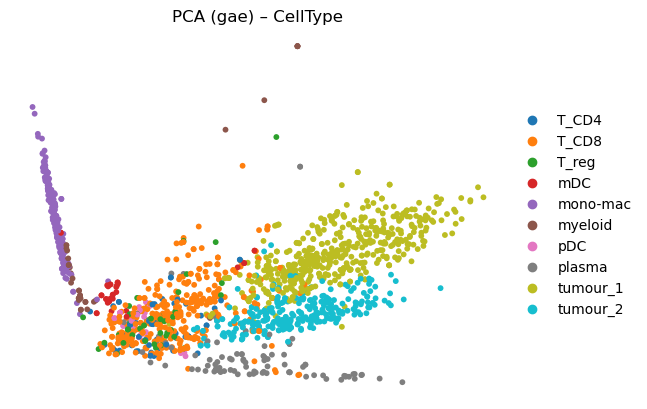

In [33]:
import numpy as np
import pandas as pd

# 1) Get the proba matrix (we stored it as a DataFrame; handle array too)
proba = sc_adata.obsm['pred_domain_proba']
if isinstance(proba, np.ndarray):
    proba_df = pd.DataFrame(proba, index=sc_adata.obs_names)
else:
    proba_df = proba  # already a DataFrame

# 2) Build keep mask: max prob per cell ≥ 0.5 (ignoring NaNs)
rowmax = proba_df.max(axis=1, skipna=True)
keep = rowmax >= 0.1

# 3) Subset AnnData
sc_adata_filtered = sc_adata[keep].copy()

# (optional) See how many were dropped
n_drop = (~keep).sum()
print(f"Kept {keep.sum()} / {len(keep)} cells (dropped {n_drop}).")

# 1) take the embedding you saved earlier
Z = sc_adata_filtered.obsm['gae_latent']   # shape (n_spots, z_dim)

# 2) PCA on the embedding
pca = PCA(n_components=20, random_state=0)
sc_adata_filtered.obsm['X_pca_gae'] = pca.fit_transform(Z)

# Plot PCA/UMAP of the sc embeddings, colored by predicted domain:
for col in ['pred_domain', 'CellType']:
    if col in sc_adata_filtered.obs:
        if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):
            sc_adata_filtered.obs[col] = sc_adata_filtered.obs[col].astype('category')
        sc.pl.embedding(sc_adata_filtered, basis='pca_gae', color=col, frameon=False, title=f'PCA (gae) – {col}')

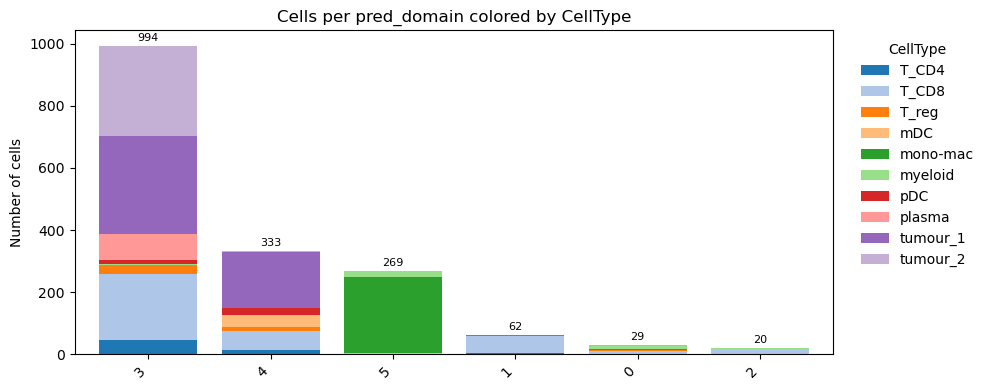

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_celltype_by_pred_domain(adata, ct_key='CellType', dom_key='pred_domain',
                                 sort_by_total=True, figsize=(8,4), annotate=False):
    """
    Stacked bar plot:
      - x-axis: cell types
      - bar height: #cells per cell type
      - colored segments: counts of each pred_domain within the cell type
    """
    # sanity checks
    if ct_key not in adata.obs or dom_key not in adata.obs:
        raise KeyError(f"'{ct_key}' or '{dom_key}' not found in adata.obs")

    ct = adata.obs[ct_key].astype('category')
    dom = adata.obs[dom_key].astype('category')

    # counts matrix: rows=cellType, cols=pred_domain
    M = pd.crosstab(ct, dom).astype(int)

    # order cell types by total count
    totals = M.sum(axis=1)
    if sort_by_total:
        M = M.loc[totals.sort_values(ascending=False).index]
        totals = totals.loc[M.index]

    # colors (one color per domain)
    K = M.shape[1]
    cmap = ListedColormap(plt.cm.tab20.colors[:K])
    dom_colors = {d: cmap(i) for i, d in enumerate(M.columns)}

    # plot
    ax = plt.figure(figsize=figsize).gca()
    bottom = np.zeros(M.shape[0], dtype=float)
    x = np.arange(M.shape[0])

    for j, d in enumerate(M.columns):
        vals = M[d].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=dom_colors[d], label=str(d), width=0.8, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in M.index], rotation=45, ha='right')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'Cells per {ct_key} colored by {dom_key}')
    ax.legend(title=dom_key, bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
    ax.set_xlim(-0.6, len(x)-0.4)

    # optional annotations: show totals on top or percentages inside segments
    if annotate:
        for i, total in enumerate(totals):
            ax.text(i, total + max(totals)*0.01, str(total), ha='center', va='bottom', fontsize=8)
        # Example for percent labels per segment (commented; can clutter):
        # for i in range(M.shape[0]):
        #     cum = 0
        #     for d in M.columns:
        #         v = M.iloc[i][d]
        #         if v > 0:
        #             ax.text(i, cum + v/2, f"{100*v/float(totals.iloc[i]):.0f}%", ha='center', va='center', fontsize=7, color='white')
        #         cum += v

    plt.tight_layout()
    plt.show()

# usage:
plot_celltype_by_pred_domain(sc_adata_filtered, ct_key='pred_domain', dom_key='CellType', sort_by_total=True, figsize=(10,4), annotate=True)


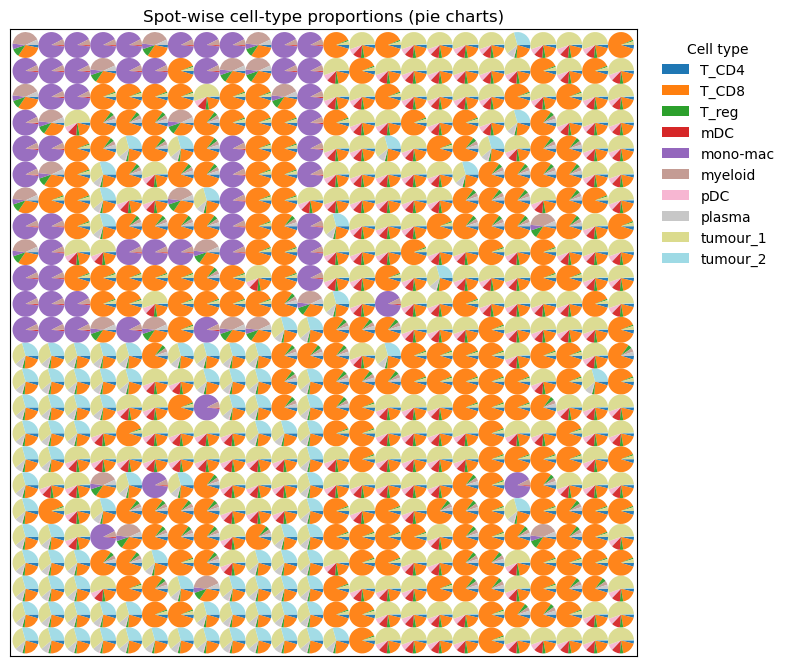

In [35]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'CellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


In [36]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import issparse, csr_matrix

def _to_dense(X):
    return X.A if issparse(X) else np.asarray(X)

def _to_dense(X):
    if issparse(X):
        return X.toarray()   # 用 toarray() 代替 .A
    else:
        return np.asarray(X)

def _add_noise(X, sigma=0.01, nonneg=False, integer=False, clip_min=0.0):
    """
    Add small Gaussian noise. If `integer` is True, round to ints (for raw counts).
    """
    Xn = X + np.random.normal(0.0, sigma, size=X.shape).astype(np.float32)
    if nonneg:
        Xn = np.maximum(Xn, clip_min)
    if integer:
        Xn = np.rint(Xn).astype(np.int32)
    return Xn

def augment_domains_equalize(
    adata,
    domain_key='pred_domain',
    ct_key='cellType',
    layer=None,                 # None -> use .X ; else use adata.layers[layer]
    target_per_domain=None,     # None -> max count among domains; or int (e.g., 600)
    keep_ct_proportions=True,   # maintain cellType proportions within each domain
    noise_sigma=0.01,           # std of Gaussian jitter in the working space
    nonneg=True,                # clip to >=0 after noise
    integer=False,              # round to ints (set True if you're augmenting raw counts)
    random_state=0
):
    """
    Returns NEW AnnData where each `pred_domain` has (approximately) equal number of cells
    via oversampling with light noise. Metadata is copied; new obs_names get suffixes.
    """
    rng = np.random.default_rng(random_state)

    # --- inputs & working matrix ---
    assert domain_key in adata.obs, f"'{domain_key}' not found in adata.obs"
    assert ct_key in adata.obs, f"'{ct_key}' not found in adata.obs"

    dom = adata.obs[domain_key].astype('category')
    ct  = adata.obs[ct_key].astype('category')

    X_base = adata.layers[layer] if layer is not None else adata.X
    X_np = _to_dense(X_base).astype(np.float32)

    # --- counts & targets ---
    counts = dom.value_counts()
    if counts.empty:
        raise ValueError("No domains found.")
    if target_per_domain is None:
        target_per_domain = int(counts.max())
    target_per_domain = int(target_per_domain)

    # --- collect augmented rows ---
    aug_rows = []
    aug_obs  = []
    aug_uns  = []  # not used; placeholder if you want to track provenance per row

    # precompute index lists per (domain, cellType)
    df_idx = (
        pd.DataFrame({'row': np.arange(adata.n_obs), 'dom': dom.astype(str).values, 'ct': ct.astype(str).values})
        .groupby(['dom','ct'])['row'].apply(np.array)
    )
    # domain-only groups
    dom_groups = pd.Series(np.arange(adata.n_obs)).groupby(dom.astype(str).values).apply(np.array)

    for d, idx_dom in dom_groups.items():
        n_cur = idx_dom.size
        if n_cur >= target_per_domain:
            continue
        deficit = target_per_domain - n_cur

        if keep_ct_proportions:
            # split deficit across cell types proportionally (at least 1 if available)
            ct_counts = (ct.iloc[idx_dom].astype(str).value_counts()).reindex(ct.cat.categories.astype(str), fill_value=0)
            if ct_counts.sum() == 0:
                continue
            props = (ct_counts / ct_counts.sum()).to_numpy()
            alloc = np.floor(props * deficit).astype(int)
            # distribute remainder
            rem = deficit - alloc.sum()
            order = np.argsort(-props)  # highest proportion first
            for a in order:
                if rem == 0: break
                alloc[a] += 1; rem -= 1
            for ct_name, need in zip(ct.cat.categories.astype(str), alloc):
                if need <= 0: continue
                key = (d, ct_name)
                if key not in df_idx.index: 
                    continue
                pool = df_idx.loc[key]
                if pool.size == 0: 
                    continue
                # sample with replacement from this (domain, cellType) pool
                pick = rng.choice(pool, size=need, replace=True)
                aug_rows.append(pick)
        else:
            # ignore cellType proportions; sample from domain pool
            pick = rng.choice(idx_dom, size=deficit, replace=True)
            aug_rows.append(pick)

    if len(aug_rows) == 0:
        # nothing to add; return a copy
        return adata.copy()

    aug_idx = np.concatenate(aug_rows)
    X_aug  = X_np[aug_idx].copy()
    # X_aug  = _add_noise(X_aug, sigma=noise_sigma, nonneg=nonneg, integer=integer, clip_min=0.0)

    # --- build new obs for augmented cells (copy rows, tweak names) ---
    obs_aug = adata.obs.iloc[aug_idx].copy()
    # ensure unique names: append suffix with running counter
    base_names = adata.obs_names.to_numpy()
    aug_names = [f"{base_names[i]}__aug{j}" for j, i in enumerate(aug_idx)]
    obs_aug.index = pd.Index(aug_names)

    # --- assemble final AnnData: original + augmented ---
    # stack matrices
    X_new = np.vstack([X_np, X_aug]).astype(np.float32)
    obs_new = pd.concat([adata.obs, obs_aug], axis=0)
    var_new = adata.var.copy()

    # layers: if you augmented a layer, carry all layers forward (augmented layer updated, others duplicated)
    layers_new = {}
    for key, arr in adata.layers.items():
        arr_np = _to_dense(arr).astype(np.float32)
        if key == layer or (layer is None and key is None):
            # for the working layer (or .X if layer is None), use X_new later
            continue
        # duplicate selected rows for augmented records (noisy versions are only in the working matrix)
        layers_new[key] = np.vstack([arr_np, arr_np[aug_idx]]).astype(np.float32)

    # obsm/obsp: duplicate rows if present (no noise)
    obsm_new = {}
    for key, M in adata.obsm.items():
        M_np = np.asarray(M)
        obsm_new[key] = np.vstack([M_np, M_np[aug_idx]])

    obsp_new = {}
    for key, M in adata.obsp.items():
        # leave pairwise mats as-is (they won’t match new size); drop them
        # (recompute neighbors/graphs later on augmented data)
        continue

    # create AnnData
    ad_out = ad.AnnData(
        X=X_new if layer is None else _to_dense(adata.X),  # if augmenting .X, use X_new; else keep original .X
        obs=obs_new,
        var=var_new,
        obsm=obsm_new
    )
    # set layers
    if layer is None:
        # we already set X_new with noise; copy other layers
        for k, L in layers_new.items():
            ad_out.layers[k] = L
    else:
        # we augmented a specific layer: set that layer to X_new; copy other layers; update .X with original stacking
        ad_out.layers = layers_new
        ad_out.layers[layer] = X_new

    # provenance
    ad_out.uns = adata.uns.copy()
    ad_out.uns['domain_augmentation'] = {
        'domain_key': domain_key,
        'ct_key': ct_key,
        'target_per_domain': target_per_domain,
        'keep_ct_proportions': keep_ct_proportions,
        'noise_sigma': float(noise_sigma),
        'nonneg': bool(nonneg),
        'integer': bool(integer),
        'augmented_n': int(len(aug_idx)),
        'random_state': int(random_state),
    }

    return ad_out


In [37]:
sc_adata_filtered = augment_domains_equalize(
    sc_adata_filtered,
    domain_key='pred_domain',
    ct_key='CellType',
    layer=None,          # or None to work on .X
    target_per_domain=None, # None -> use max domain count
    keep_ct_proportions=True,
    noise_sigma=0.01,
    nonneg=True,
    integer=False,
    random_state=0
)

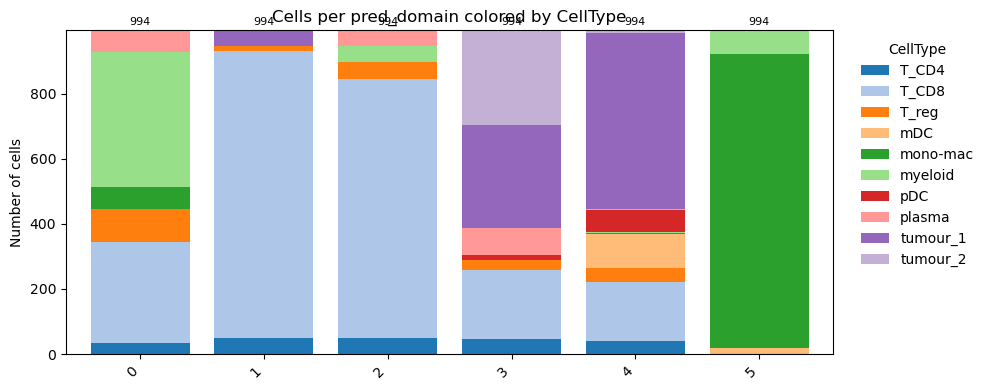

In [39]:

plot_celltype_by_pred_domain(sc_adata_filtered, ct_key='pred_domain', dom_key='CellType', sort_by_total=True, figsize=(10,4), annotate=True)


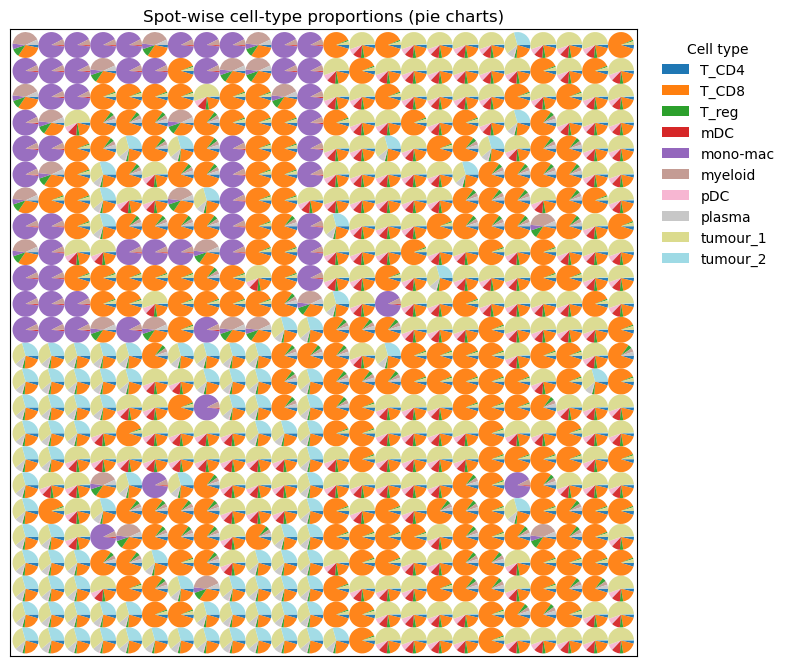

In [40]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'CellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


In [42]:
import torch
import torch.nn.functional as F

def ot_match_prob(
    X, Y,
    metric: str = "cosine",      # "cosine" or "euclidean"
    eps: float = 0.05,           # entropic regularization
    iters: int = 80,             # Sinkhorn iterations
    row_mass=None,               # shape [N], default: ones
    col_mass=None,               # shape [M], default: uniform scaled so sum == N
    standardize: bool = False,   # z-score features before computing cost
    device:str = None,
    return_torch: bool = True,   # return torch.Tensor (else numpy)
):
    """
    X: (N, D) cells/features
    Y: (M, D) spots/features
    Returns P: (N, M) row-stochastic soft matching probabilities.
    """
    # ---- to torch ----
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    Xt = torch.as_tensor(X, dtype=torch.float32, device=device)
    Yt = torch.as_tensor(Y, dtype=torch.float32, device=device)
    N, D = Xt.shape; M, D2 = Yt.shape
    assert D == D2, "Feature dims must match"

    # ---- optional standardization (joint z-score) ----
    if standardize:
        Z = torch.cat([Xt, Yt], dim=0)
        mu = Z.mean(dim=0, keepdim=True)
        sd = Z.std(dim=0, keepdim=True) + 1e-6
        Xt = (Xt - mu) / sd
        Yt = (Yt - mu) / sd

    # ---- cost matrix C (smaller is better) ----
    if metric.lower() == "cosine":
        # cosine distance = 1 - cosine similarity
        Xt_n = F.normalize(Xt, dim=1)
        Yt_n = F.normalize(Yt, dim=1)
        C = 1.0 - torch.matmul(Xt_n, Yt_n.T)  # [N,M]
    elif metric.lower() == "euclidean":
        # squared Euclidean distance
        x2 = (Xt**2).sum(dim=1, keepdim=True)        # [N,1]
        y2 = (Yt**2).sum(dim=1, keepdim=True).T      # [1,M]
        C = x2 + y2 - 2.0 * Xt @ Yt.T                # [N,M]
        C = torch.clamp(C, min=0.0)
    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    # ---- entropic kernel ----
    K = torch.exp(-C / eps).clamp(min=1e-12)

    # ---- marginals ----
    if row_mass is None:
        r = torch.ones(N, device=device)
    else:
        r = torch.as_tensor(row_mass, dtype=torch.float32, device=device)
        assert r.shape == (N,)

    if col_mass is None:
        c = torch.full((M,), float(N) / M, device=device)
    else:
        c = torch.as_tensor(col_mass, dtype=torch.float32, device=device)
        assert c.shape == (M,)
        # scale so sum(c) ~= sum(r)
        c = c * (r.sum() / (c.sum() + 1e-12))

    # ---- Sinkhorn (balanced) ----
    u = torch.ones_like(r)
    v = torch.ones_like(c)
    for _ in range(iters):
        Kv = K @ v + 1e-12
        u = r / Kv
        KTu = K.T @ u + 1e-12
        v = c / KTu

    P = (u[:, None] * K) * v[None, :]        # [N,M]
    # numerical tidy: ensure exact row-stochastic if r==1
    if row_mass is None:
        P = P / (P.sum(dim=1, keepdim=True) + 1e-12)

    return P if return_torch else P.detach().cpu().numpy()


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cells_spatial(
    sc_adata,
    df_xy,                 # DataFrame indexed by cell IDs, with columns ['x','y']
    color_keys=('pred_domain','CellType'),
    s=6, alpha=0.85, figsize=(6,5), title_prefix=''
):
    # 1) align rows (keep only cells present in both)
    idx = sc_adata.obs_names.intersection(df_xy.index)
    if len(idx) == 0:
        raise ValueError("No overlapping cell IDs between sc_adata and df_xy.")
    xy = df_xy.loc[idx, ['x','y']].astype(float).to_numpy()

    def _plot_one(color_key):
        if color_key not in sc_adata.obs:
            raise KeyError(f"'{color_key}' not found in sc_adata.obs")
        cats = sc_adata.obs.loc[idx, color_key].astype('category')
        categories = list(cats.cat.categories)

        # color palette
        # use tab20/tab20b/tab20c concatenated if many categories
        base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
        if len(categories) > len(base):
            # repeat if needed (rare)
            rep = int(np.ceil(len(categories)/len(base)))
            palette = (base * rep)[:len(categories)]
        else:
            palette = base[:len(categories)]
        color_map = dict(zip(categories, palette))

        plt.figure(figsize=figsize)
        for cat in categories:
            m = (cats == cat).to_numpy()
            if not m.any(): 
                continue
            plt.scatter(xy[m, 0], xy[m, 1],
                        s=s, alpha=alpha, c=[color_map[cat]],
                        label=str(cat), edgecolors='none')

        plt.gca().set_aspect('equal', adjustable='datalim')
        plt.xlabel('x'); plt.ylabel('y')
        ttl = f"{title_prefix}{color_key}"
        plt.title(ttl)
        # move legend outside if many entries
        ncat = len(categories)
        if ncat <= 12:
            plt.legend(frameon=False, markerscale=2)
        else:
            plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)
        plt.tight_layout()
        plt.show()

    # 2) make the two plots
    for key in color_keys:
        _plot_one(key)


In [44]:
import numpy as np
import pandas as pd
import torch
from scipy.optimize import linear_sum_assignment

# 你已有的 OT 内核（保持不变）
# def ot_match_prob(...): ...

def map_cells_to_spots_dom_ct(
    sc_adata, st_adata,
    emb_key_sc='gae_latent', emb_key_st='gae_latent',
    sc_domain_key='pred_domain', st_domain_key='gt',
    sc_type_key='CellType',
    metric='cosine', eps=0.05, iters=200,
    standardize=False,
    assignment_mode='argmax',   # 'argmax' / 'balanced'
    random_state=0,
    keep_P_full=False,         # True 才保存完整 P（非常占显存/内存，不推荐）
    store_topk=None,           # int: 仅保存每个 cell 的 top-k (idx,val) 到 CPU
    device=None,               # 'cuda'/'cpu'/None
):
    """
    低显存版本：按 (domain × cellType) 分桶做 OT / 落位，但默认不保存完整 P。

    Returns:
      P_stats: dict[(domain, cellType)] -> dict，其中包含：
        - 'col_sum': np.ndarray [Ns_domain]（float32, CPU）
        - 'idx_st': np.ndarray [Ns_domain]（该 domain 下 spot 的全局索引）
        - 可选：'topk_idx','topk_val'（CPU；topk_val 为 float16）
        - 可选：'P'（仅 keep_P_full=True 时；torch.Tensor）
      assigned_spot_for_cell: pd.Series (index=sc cells) -> mapped spot (global names)
      spot_type_prop: DataFrame (spots x cellTypes) proportions（硬指派得到）
    """
    rng = np.random.default_rng(random_state)

    # --- embedding 与标签 ---
    Z_sc = np.asarray(sc_adata.obsm[emb_key_sc], dtype=np.float32)
    Z_st = np.asarray(st_adata.obsm[emb_key_st], dtype=np.float32)

    sc_dom = sc_adata.obs[sc_domain_key].astype('category')
    st_dom = st_adata.obs[st_domain_key].astype('category')
    sc_ct  = sc_adata.obs[sc_type_key].astype('category')

    sc_index = sc_adata.obs_names
    st_index = st_adata.obs_names

    domains = [d for d in sc_dom.cat.categories if d in set(st_dom.cat.categories)]
    cell_types = list(sc_ct.cat.categories)
    if len(domains) == 0:
        raise ValueError("No overlapping domain labels between sc_adata and st_adata.")

    # 默认设备：优先 CUDA
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    P_stats = {}
    assigned_spot_for_cell = pd.Series(index=sc_index, dtype='object')

    for d in domains:  # 先按 domain 分桶
        idx_st = np.where(st_dom.values == d)[0]
        if len(idx_st) == 0:
            continue
        Y = Z_st[idx_st]  # Ns × D

        # 再按 cellType 细分
        for t in cell_types:
            mask_sc = (sc_dom.values == d) & (sc_ct.values == t)
            idx_sc = np.where(mask_sc)[0]
            if len(idx_sc) == 0:
                continue

            X = Z_sc[idx_sc]  # Nc × D

            # —— OT ——（P 在 GPU 上产生，但我们立即“压缩/落盘”到 CPU）——
            P = ot_match_prob(
                X, Y,
                metric=metric, eps=eps, iters=iters,
                row_mass=None, col_mass=None,
                standardize=standardize,
                device=device,
                return_torch=True
            )  # [Nc, Ns]

            # 只保留列和（用于 soft pie / 后续统计），避免保存完整 P
            col_sum = P.sum(dim=0).detach().cpu().numpy().astype(np.float32, copy=False)

            entry = {'col_sum': col_sum, 'idx_st': idx_st.astype(np.int64, copy=False)}
            if keep_P_full:
                entry['P'] = P  # 注意：这会非常占显存/内存
            if store_topk is not None and int(store_topk) > 0:
                k = int(min(store_topk, P.shape[1]))
                v, ii = torch.topk(P, k=k, dim=1)
                entry['topk_idx'] = ii.detach().cpu().numpy().astype(np.int32, copy=False)
                entry['topk_val'] = v.detach().cpu().numpy().astype(np.float16, copy=False)

            P_stats[(d, t)] = entry

            # —— 硬指派（默认 argmax；balanced 会很慢/占内存）——
            if assignment_mode == 'balanced':
                # SciPy 匈牙利算法在 CPU 上跑；这里按桶临时转 numpy（不存下来）
                Pn = P.detach().cpu().numpy().astype(np.float32, copy=False)
                Nc, Ns = Pn.shape

                q, r = divmod(Nc, Ns)
                caps = np.full(Ns, q, dtype=int)
                order = np.arange(Ns)  # 或 rng.permutation(Ns)
                caps[order[:r]] += 1

                col_ids = np.repeat(np.arange(Ns), caps)      # len = Nc
                P_exp = Pn[:, col_ids]                        # (Nc × Nc) 可能很大！
                cost = -np.log(P_exp + 1e-12)
                row_ind, col_ind = linear_sum_assignment(cost)
                spot_local = col_ids[col_ind]
            else:
                spot_local = P.argmax(dim=1).detach().cpu().numpy()

            mapped_global = pd.Index(st_index[idx_st][spot_local])
            assigned_spot_for_cell.iloc[idx_sc] = mapped_global.values

            # 释放 GPU 临时量
            if not keep_P_full:
                del P
                if device == "cuda":
                    torch.cuda.empty_cache()

    assigned_spot_for_cell = assigned_spot_for_cell.dropna()

    # --- 聚合成 spot × cellType 的计数/占比（硬指派） ---
    df_map = pd.DataFrame({
        'cell': assigned_spot_for_cell.index,
        'spot': assigned_spot_for_cell.values,
        'CellType': sc_ct.reindex(assigned_spot_for_cell.index).astype('category').astype(str)
    })
    counts = df_map.groupby(['spot', 'CellType']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=cell_types, fill_value=0)

    spot_totals = counts.sum(axis=1).replace(0, np.nan)
    spot_type_prop = counts.div(spot_totals, axis=0).fillna(0.0)
    spot_type_prop = spot_type_prop.reindex(st_index, fill_value=0.0)

    for ct in spot_type_prop.columns:
        st_adata.obs[f'prop_{ct}'] = spot_type_prop[ct].astype(np.float32)
    st_adata.obs['mapped_cell_count'] = counts.sum(axis=1).reindex(st_index).fillna(0).astype(int)

    return P_stats, assigned_spot_for_cell, spot_type_prop


In [45]:
def build_spot_type_prop_soft(P_stats, sc_adata, st_adata,
                              sc_domain_key='pred_domain', st_domain_key='domain',
                              sc_type_key='CellType'):
    """
    从低内存表示（P_stats 的 col_sum）构造 soft 版 spot×cellType 占比。
    兼容旧版：如果 entry 里有 'P'（完整矩阵），也能工作。
    """
    import numpy as np
    import pandas as pd

    st_dom = st_adata.obs[st_domain_key].astype('category')
    st_index = st_adata.obs_names
    cell_types = list(sc_adata.obs[sc_type_key].astype('category').cat.categories)

    out = pd.DataFrame(0.0, index=st_index, columns=cell_types)

    for (d, t), entry in P_stats.items():
        if d not in st_dom.cat.categories:
            continue
        idx_st = entry.get('idx_st', None)
        if idx_st is None:
            idx_st = np.where(st_dom.values == d)[0]

        if isinstance(entry, dict) and 'col_sum' in entry:
            mass = entry['col_sum']  # (Ns_dom,)
        elif isinstance(entry, dict) and 'P' in entry:
            P = entry['P']
            mass = P.detach().cpu().numpy().sum(axis=0)
        else:
            # 兼容极端情况：entry 直接就是矩阵
            P = entry
            mass = P.detach().cpu().numpy().sum(axis=0)

        out.loc[st_index[idx_st], t] += mass

    row_sum = out.sum(axis=1).replace(0, np.nan)
    return out.div(row_sum, axis=0).fillna(0.0)


/tmp/ipykernel_26625/3578071492.py:41: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  C = 1.0 - torch.matmul(Xt_n, Yt_n.T)  # [N,M]
/tmp/ipykernel_26625/3578071492.py:73: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses 

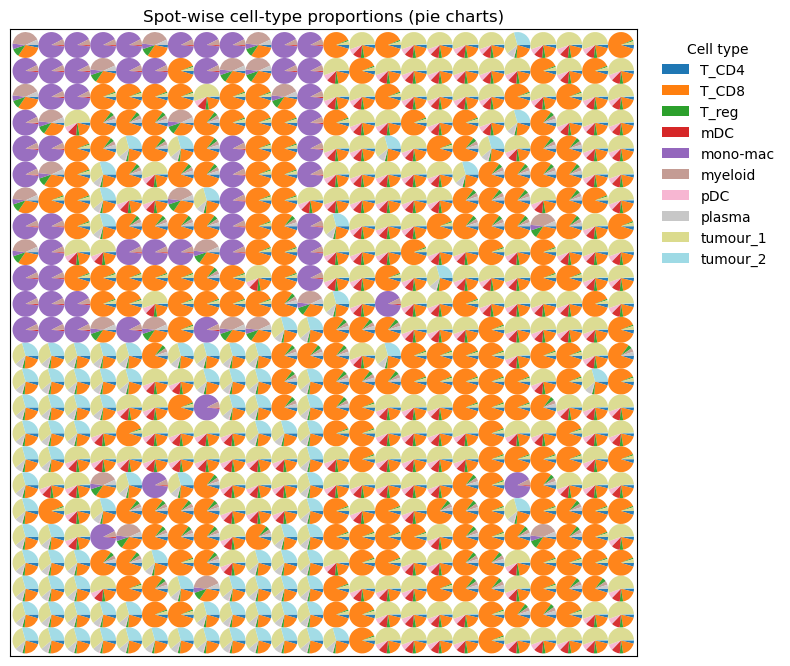

In [46]:
P_full, assigned, spot_type_prop = map_cells_to_spots_dom_ct(
    sc_adata_filtered, adata_prep,
    emb_key_sc='gae_latent', emb_key_st='gae_latent',
    sc_domain_key='pred_domain', st_domain_key='domain',
    sc_type_key='CellType',
    metric='cosine', eps=0.05, iters=200,   #0.05，200 10.30为了渐变改动
    standardize=False,
    assignment_mode='argmax'      # 或 'balanced'
)

spot_type_prop_soft = build_spot_type_prop_soft(P_full, sc_adata_filtered, adata_prep)
_ = plot_spatial_pies(adata_prep, spot_type_prop_soft, coord_key='spatial', radius=5, legend=True)

In [47]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

def _largest_remainder_rounding(x, total=None):
    """
    将非负实数向量 x 整数化，使和为 total（默认 round(sum(x))）。
    采用最大余数法（Hamilton method）。
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0.0, None)
    if total is None:
        total = int(np.rint(x.sum()))
    base = np.floor(x).astype(int)
    rem = total - base.sum()
    if rem < 0:
        # 罕见：浮点误差或 total 过小，回退到直接 round 并微调
        base = np.round(x).astype(int)
        diff = total - base.sum()
        if diff == 0:
            return base
        # 按小数部分远离 round 的方向微调
        frac = x - np.floor(x)
        order = np.argsort(frac)  # 从小到大
        ptr = 0
        while diff != 0 and ptr < len(order):
            j = order[ptr] if diff > 0 else order[-(ptr+1)]
            base[j] += 1 if diff > 0 else -1
            diff = total - base.sum()
            ptr += 1
        return np.clip(base, 0, None)
    if rem == 0:
        return base
    # 分配给小数部分最大的前 rem 个
    frac = x - np.floor(x)
    order = np.argsort(-frac)  # 从大到小
    base[order[:rem]] += 1
    return base

def hard_assign_cells_from_soft(
    P_full, sc_adata, st_adata,
    sc_domain_key='pred_domain', st_domain_key='gt', sc_type_key='CellType',
    p_eps=1e-12, random_state=0
):
    """
    用软分配 P_full 在每个 domain 内做容量约束匈牙利求解。
    修改以处理 P_full 的新结构。
    """
    rng = np.random.default_rng(random_state)

    st_dom = st_adata.obs[st_domain_key].astype('category')
    sc_dom = sc_adata.obs[sc_domain_key].astype('category')
    sc_ct  = sc_adata.obs[sc_type_key].astype('category')

    st_index = st_adata.obs_names
    sc_index = sc_adata.obs_names

    domains = [d for d in sc_dom.cat.categories if d in set(st_dom.cat.categories)]

    assigned_spot = pd.Series(index=sc_index, dtype=object)

    for d in domains:
        # 该域的 spots
        idx_st = np.where(st_dom.values == d)[0]
        Ns = len(idx_st)
        if Ns == 0:
            continue

        # 收集该域所有类型的 (cells, P)
        rows_all = []
        idx_sc_all = []

        for t in sc_ct.cat.categories:
            key = (d, t)
            if key not in P_full:
                continue
            
            P_dict = P_full[key]
            
            # 检查是否有完整的概率矩阵
            if 'P' in P_dict:
                # 有完整的概率矩阵
                P = P_dict['P']
                if hasattr(P, 'detach'):
                    Pn = P.detach().cpu().numpy()
                else:
                    Pn = np.asarray(P, dtype=float)
            elif 'col_sum' in P_dict:
                # 只有列和，创建均匀分布的概率矩阵
                col_sum = np.asarray(P_dict['col_sum'], dtype=float)
                
                # 获取该类型的细胞索引
                mask_sc = (sc_dom.values == d) & (sc_ct.values == t)
                idx_sc = np.where(mask_sc)[0]
                Nc_type = len(idx_sc)
                
                if Nc_type == 0:
                    continue
                
                # 创建均匀分布的概率矩阵
                # 每个细胞分配到每个spot的概率 = spot的概率总和 / 细胞数
                Pn = np.tile(col_sum / Nc_type, (Nc_type, 1))
                
                # 确保每行和为1（归一化）
                row_sums = Pn.sum(axis=1, keepdims=True)
                row_sums[row_sums == 0] = 1  # 避免除以零
                Pn = Pn / row_sums
            else:
                # 没有概率信息，跳过
                continue
            
            # 获取该类型的细胞索引（如果还没获取）
            if 'idx_sc' not in locals():
                mask_sc = (sc_dom.values == d) & (sc_ct.values == t)
                idx_sc = np.where(mask_sc)[0]
            
            # 检查维度
            if Pn.shape[0] != len(idx_sc) or Pn.shape[1] != Ns:
                print(f"警告: 维度不匹配 domain={d}, type={t}: P={Pn.shape}, rows={len(idx_sc)}, cols={Ns}")
                # 调整维度
                if Pn.shape[0] < len(idx_sc):
                    # 重复行
                    repeat_times = len(idx_sc) // Pn.shape[0] + 1
                    Pn = np.tile(Pn, (repeat_times, 1))[:len(idx_sc)]
                elif Pn.shape[0] > len(idx_sc):
                    # 截断行
                    Pn = Pn[:len(idx_sc)]
                
                if Pn.shape[1] < Ns:
                    # 填充零列
                    padding = np.zeros((Pn.shape[0], Ns - Pn.shape[1]))
                    Pn = np.hstack([Pn, padding])
                elif Pn.shape[1] > Ns:
                    # 截断列
                    Pn = Pn[:, :Ns]
            
            rows_all.append(Pn)
            idx_sc_all.append(idx_sc)

        if not rows_all:
            continue

        P_all = np.vstack(rows_all)                 # (Nc_dom, Ns)
        idx_sc_all = np.concatenate(idx_sc_all)     # (Nc_dom,)
        Nc_dom = P_all.shape[0]

        # 列容量：按列和的期望人数整数化
        col_mass = P_all.sum(axis=0)                # (Ns,)
        if col_mass.sum() <= 0:
            # 退化情况：全 0，均匀容量
            caps_total = _largest_remainder_rounding(np.ones(Ns) * (Nc_dom / max(Ns,1)), total=Nc_dom)
        else:
            caps_total = _largest_remainder_rounding(col_mass, total=Nc_dom)

        # 扩展列并匈牙利
        col_ids = np.repeat(np.arange(Ns), caps_total)  # 长度 Nc_dom
        if col_ids.size != Nc_dom:
            raise RuntimeError("Capacity expansion size mismatch.")

        P_exp = P_all[:, col_ids]                       # (Nc_dom, Nc_dom)
        cost  = -np.log(P_exp + p_eps)

        row_ind, col_ind = linear_sum_assignment(cost)
        spot_local = col_ids[col_ind]                   # (Nc_dom,)

        # 写回全局 spot 名
        mapped_global = pd.Index(st_index[idx_st][spot_local])
        assigned_spot.iloc[idx_sc_all] = mapped_global.values

    # 极少数没覆盖的（比如没有 domain 交集），丢弃
    assigned_spot = assigned_spot.dropna()

    return assigned_spot


In [48]:
# 细胞→spot 的指派结果不变：每个细胞仍然分到它的那个 spot，没有丢任何一个，也不会多用。
#裁剪做的事：对已经分到第 j 个 spot 的细胞，如果该细胞的合成坐标离这个 spot 太远（超过允许半径），就沿着“细胞 → spot”的直线把点拉回到半径边界内。指派不变、容量不变、assigned_spot_for_cell_soft 不变。
#影响范围：只改变散点坐标图的“云”轮廓，让它不跑出原始位点边界太远；不会改变柱状/饼图里的spot_type_prop、spot_type_prop_soft等占比与计数。
import numpy as np
import pandas as pd
from scipy.spatial import KDTree, ConvexHull
from matplotlib.path import Path

# —— 通用：在任意“inside(p)”定义的区域内做 Bridson Poisson 采样 ——
def poisson_disk_in_region(inside_fn, mins, maxs, r, k=30, seed=0):
    rng = np.random.default_rng(seed)
    cell = r/np.sqrt(2)
    nx = int(np.ceil((maxs[0]-mins[0])/cell)); ny = int(np.ceil((maxs[1]-mins[1])/cell))
    grid = -np.ones((nx, ny), dtype=int)
    def gcoords(p): return (np.floor((p - mins)/cell)).astype(int)

    # seed
    for _ in range(2000):
        p0 = rng.uniform(mins, maxs)
        if inside_fn(p0): break
    else:
        raise RuntimeError("Failed to seed inside support region.")
    samples=[p0]; active=[0]; gx,gy=gcoords(p0); grid[gx,gy]=0

    def valid(p):
        if not inside_fn(p): return False
        gx,gy=gcoords(p)
        if gx<0 or gy<0 or gx>=nx or gy>=ny: return False
        i0=max(gx-2,0); i1=min(gx+3,nx); j0=max(gy-2,0); j1=min(gy+3,ny)
        for ix in range(i0,i1):
            for iy in range(j0,j1):
                s=grid[ix,iy]
                if s==-1: continue
                if np.linalg.norm(samples[s]-p) < r: return False
        return True

    while active:
        i = rng.choice(active)
        c = samples[i]; found=False
        for _ in range(k):
            rad = rng.uniform(r, 2*r); ang = rng.uniform(0, 2*np.pi)
            cand = c + rad*np.array([np.cos(ang), np.sin(ang)])
            if valid(cand):
                samples.append(cand); active.append(len(samples)-1)
                gx,gy=gcoords(cand); grid[gx,gy]=len(samples)-1; found=True; break
        if not found: active.remove(i)
    return np.asarray(samples, dtype=np.float32)

def _parse_xy_str(arr_like):
    s = pd.Series(arr_like, dtype=str).str.strip().str.lower().str.replace('×','x', regex=False)
    xy = np.vstack(s.str.split('x', n=1, expand=True).astype(float).to_numpy())
    return xy  # (N,2)

from typing import Optional  # <— 新增

def assign_cell_locations_from_coord_strings(
    assigned_spot_for_cell: pd.Series,
    st_adata=None,  # 新增：空间数据的AnnData对象
    min_dist=None, 
    k_nn=8, 
    seed=0,
    support_mode: str = 'union_disks',
    support_radius_factor: float = 1.1,
    clip_to_spot: bool = False,
    clip_radius_factor: float = 1.3,
    clip_radius_abs: Optional[float] = None
):
    """
    返回细胞合成坐标，并带两道"防越界"护栏。
    修改：支持从空间数据中获取spot坐标
    """
    rng = np.random.default_rng(seed)

    # 1) capacities & unique spots
    spot_str = assigned_spot_for_cell.astype(str).values
    unique_spots, inverse = np.unique(spot_str, return_inverse=True)
    cap = np.bincount(inverse)
    S = len(unique_spots); N = len(spot_str)

    # 2) 获取spot坐标 - 新增逻辑
    if st_adata is not None:
        # 从空间数据中获取spot坐标
        print(f"从空间数据中获取 {S} 个spot的坐标...")
        
        # 检查spot是否在空间数据中
        missing_spots = set(unique_spots) - set(st_adata.obs_names)
        if missing_spots:
            print(f"警告: {len(missing_spots)} 个spot不在空间数据中")
            if len(missing_spots) > 10:
                print(f"例如: {list(missing_spots)[:10]}")
        
        # 尝试从不同的地方获取坐标
        XY_spot = np.zeros((S, 2), dtype=np.float32)
        
        for i, spot in enumerate(unique_spots):
            if spot in st_adata.obs_names:
                idx = st_adata.obs_names.get_loc(spot)
                
                # 首先尝试从obs中获取x,y列
                if 'x' in st_adata.obs.columns and 'y' in st_adata.obs.columns:
                    XY_spot[i, 0] = float(st_adata.obs['x'].iloc[idx])
                    XY_spot[i, 1] = float(st_adata.obs['y'].iloc[idx])
                # 尝试从obsm['spatial']获取
                elif 'spatial' in st_adata.obsm:
                    XY_spot[i, :] = st_adata.obsm['spatial'][idx, :2]
                # 尝试从其他可能的列获取
                elif 'X' in st_adata.obs.columns and 'Y' in st_adata.obs.columns:
                    XY_spot[i, 0] = float(st_adata.obs['X'].iloc[idx])
                    XY_spot[i, 1] = float(st_adata.obs['Y'].iloc[idx])
                else:
                    # 如果都没有，使用索引作为伪坐标
                    XY_spot[i, 0] = i % 100
                    XY_spot[i, 1] = i // 100
            else:
                # spot不在数据中，使用伪坐标
                XY_spot[i, 0] = i % 100
                XY_spot[i, 1] = i // 100
        
        print(f"spot坐标范围: x=[{XY_spot[:, 0].min():.2f}, {XY_spot[:, 0].max():.2f}], "
              f"y=[{XY_spot[:, 1].min():.2f}, {XY_spot[:, 1].max():.2f}]")
    else:
        # 如果没有提供空间数据，尝试解析坐标字符串
        try:
            XY_spot = _parse_xy_str(unique_spots)
        except:
            raise ValueError("无法解析spot坐标，请提供st_adata参数或确保spot标识符是坐标字符串")

    # 2.1 估计全局/局部最近邻尺度（用于支持域半径与裁剪半径）
    if S > 1:
        tree_spot = KDTree(XY_spot)
        # 最近邻（排除自身，取第2个）
        dists, _ = tree_spot.query(XY_spot, k=min(4, S))  # (S, k)
        # 对每个 spot 的局部尺度取第2小距离（或第k小的中位数）
        local_scale = dists[:, 1] if dists.shape[1] >= 2 else np.full(S, np.median(dists))
        global_scale = np.median(local_scale) if S > 1 else (np.max(XY_spot, axis=0) - np.min(XY_spot, axis=0)).mean()
    else:
        local_scale = np.array([1.0])
        global_scale = 1.0

    # 3) 构造采样支持域
    if support_mode == 'convex_hull' or S < 3:
        # 原来的凸包（S<3 时做轻微外扩的矩形）
        if S >= 3:
            hull = ConvexHull(XY_spot)
            poly = XY_spot[hull.vertices]
            Ppoly = Path(poly)
            mins = poly.min(axis=0); maxs = poly.max(axis=0)
            inside_fn = lambda p: Ppoly.contains_point(p)
        else:
            mins = XY_spot.min(axis=0); maxs = XY_spot.max(axis=0)
            pad = 0.05*(maxs - mins + 1e-6)
            mins = mins - pad; maxs = maxs + pad
            inside_fn = lambda p: (mins[0] <= p[0] <= maxs[0]) and (mins[1] <= p[1] <= maxs[1])
    elif support_mode == 'union_disks':
        # 用"spot 的并集缓冲圆"作为支持域：p 若在任一圆内即有效
        R = support_radius_factor * global_scale
        mins = XY_spot.min(axis=0) - R
        maxs = XY_spot.max(axis=0) + R
        if S > 1:
            tree_spot = KDTree(XY_spot)
            def inside_fn(p):
                # 快速近邻查询：如果与最近 spot 的距离 <= R 就算 inside
                dist, _ = tree_spot.query(p, k=1)
                return dist <= R
        else:
            def inside_fn(p):
                return np.linalg.norm(p - XY_spot[0]) <= R
    else:
        raise ValueError(f"Unknown support_mode: {support_mode}")

    # 4) blue-noise 采样（≈N）
    # 若未指定 min_dist，则按支持域面积粗估（凸包情况）；union_disks 下用全局尺度
    if min_dist is None:
        if support_mode == 'convex_hull' and S >= 3:
            area = ConvexHull(XY_spot).volume
            min_dist = 0.9*np.sqrt(area / (N*np.pi))
        else:
            min_dist = 0.6 * global_scale  # 更保守一些，避免过稀
    
    print(f"使用 min_dist={min_dist:.4f}, global_scale={global_scale:.4f}")
    
    pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed)
    tries=0
    while pts.shape[0] < N and tries < 5:
        min_dist *= 0.9
        pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed+tries+1)
        tries += 1
    if pts.shape[0] > N:
        pts = pts[rng.choice(pts.shape[0], size=N, replace=False)]
    elif pts.shape[0] < N:
        # 兜底：均匀拒绝采样直到补足
        extra=[]
        for _ in range(200000):
            q = rng.uniform(mins, maxs)
            if inside_fn(q): extra.append(q)
            if len(extra)+pts.shape[0] >= N: break
        if extra: pts = np.vstack([pts, np.asarray(extra, dtype=np.float32)])

    # 5) capacity-respecting 最近邻分配到 spots（与你原逻辑一致）
    if S > 1:
        tree = KDTree(XY_spot)
        kq = min(k_nn, S)
        _, knn_idx = tree.query(pts, k=kq)
        if knn_idx.ndim == 1: knn_idx = knn_idx[:, None]
    else:
        knn_idx = np.zeros((len(pts), 1), dtype=int)

    remaining = cap.copy()
    assigned_point_to_spot = -np.ones(N, dtype=int)
    for p in rng.permutation(N):
        for j in knn_idx[p]:
            if remaining[j] > 0:
                assigned_point_to_spot[p] = j
                remaining[j] -= 1
                break
        if assigned_point_to_spot[p] < 0:
            order = np.argsort(np.linalg.norm(XY_spot - pts[p], axis=1))
            for j in order:
                if remaining[j] > 0:
                    assigned_point_to_spot[p] = j
                    remaining[j] -= 1
                    break
    if (assigned_point_to_spot < 0).any() or remaining.sum() != 0:
        raise RuntimeError("Capacity assignment failed; try larger k_nn or smaller min_dist.")

    # 6) （新增）按 spot 做半径裁剪，限制每个 cell 不要离其 spot 太远
    if clip_to_spot:
        # 每个 spot 的裁剪半径：优先绝对值，其次自适应（= factor * 局部最近邻尺度）
        if clip_radius_abs is not None:
            r_clip = np.full(S, float(clip_radius_abs), dtype=float)
        else:
            r_clip = clip_radius_factor * local_scale  # (S,)

        # 投影：dist > r_clip_j 时，沿方向缩放到半径上
        delta = pts - XY_spot[assigned_point_to_spot]
        dist = np.linalg.norm(delta, axis=1) + 1e-12
        r_allowed = r_clip[assigned_point_to_spot]
        over = dist > r_allowed
        if np.any(over):
            scale = (r_allowed[over] / dist[over])[:, None]
            pts[over] = XY_spot[assigned_point_to_spot[over]] + delta[over] * scale

    # 7) map points to cells per spot；随机配对避免偏置
    cell_xy = np.zeros((N,2), dtype=np.float32)
    per_spot_points = {j: [] for j in range(S)}
    for p, j in enumerate(assigned_point_to_spot):
        per_spot_points[j].append(p)
    for j in range(S):
        pts_j = np.asarray(per_spot_points[j], int)
        cells_j = np.where(inverse == j)[0]
        m = min(len(pts_j), len(cells_j))
        perm = rng.permutation(m)
        cell_xy[cells_j[:m]] = pts[pts_j[perm]]

    return pd.DataFrame(cell_xy, index=assigned_spot_for_cell.index, columns=['x','y'])


In [49]:
# 先检查 P_full 的结构
print(f"P_full 类型: {type(P_full)}")
if isinstance(P_full, dict):
    print(f"P_full 键的数量: {len(P_full)}")
    # 打印前几个键值对
    for i, (key, value) in enumerate(list(P_full.items())[:5]):
        print(f"\n键 {i}: {key}")
        print(f"  值的类型: {type(value)}")
        if isinstance(value, dict):
            print(f"  值是一个字典，包含键: {list(value.keys())}")
            # 打印字典的第一个值
            if value:
                first_subkey = list(value.keys())[0]
                first_subvalue = value[first_subkey]
                print(f"  第一个子键 '{first_subkey}' 的类型: {type(first_subvalue)}")
                if hasattr(first_subvalue, 'shape'):
                    print(f"  第一个子值的形状: {first_subvalue.shape}")
        elif hasattr(value, 'shape'):
            print(f"  值的形状: {value.shape}")
        else:
            print(f"  值的内容: {value}")
else:
    print(f"P_full 不是字典: {P_full}")

P_full 类型: <class 'dict'>
P_full 键的数量: 37

键 0: ('0', 'T_CD4')
  值的类型: <class 'dict'>
  值是一个字典，包含键: ['col_sum', 'idx_st']
  第一个子键 'col_sum' 的类型: <class 'numpy.ndarray'>
  第一个子值的形状: (25,)

键 1: ('0', 'T_CD8')
  值的类型: <class 'dict'>
  值是一个字典，包含键: ['col_sum', 'idx_st']
  第一个子键 'col_sum' 的类型: <class 'numpy.ndarray'>
  第一个子值的形状: (25,)

键 2: ('0', 'T_reg')
  值的类型: <class 'dict'>
  值是一个字典，包含键: ['col_sum', 'idx_st']
  第一个子键 'col_sum' 的类型: <class 'numpy.ndarray'>
  第一个子值的形状: (25,)

键 3: ('0', 'mono-mac')
  值的类型: <class 'dict'>
  值是一个字典，包含键: ['col_sum', 'idx_st']
  第一个子键 'col_sum' 的类型: <class 'numpy.ndarray'>
  第一个子值的形状: (25,)

键 4: ('0', 'myeloid')
  值的类型: <class 'dict'>
  值是一个字典，包含键: ['col_sum', 'idx_st']
  第一个子键 'col_sum' 的类型: <class 'numpy.ndarray'>
  第一个子值的形状: (25,)


In [ ]:
assigned_spot_for_cell_soft = hard_assign_cells_from_soft(
    P_full,
    sc_adata=sc_adata_filtered,
    st_adata=adata_prep,
    sc_domain_key='pred_domain',
    st_domain_key='domain',
    sc_type_key='CellType',
    p_eps=1e-12,
    random_state=0
)


out_soft = assign_cell_locations_from_coord_strings(
    assigned_spot_for_cell_soft,
    st_adata=adata_prep,  # 传入空间数据
    min_dist=None,
    k_nn=8,
    seed=0,
    support_mode='union_disks',
    support_radius_factor=1.1,
    clip_to_spot=True,
    clip_radius_factor=1.3,
    clip_radius_abs=None
)


从空间数据中获取 576 个spot的坐标...
spot坐标范围: x=[0.00, 230.00], y=[0.00, 230.00]
使用 min_dist=6.0000, global_scale=10.0000


In [ ]:
plot_cells_spatial(sc_adata_filtered, out_soft, color_keys=('pred_domain','CellType'), s=5)

In [ ]:
# 记录SIMO算法总流程结束时间
simo_end_time = time.time()
elapsed_seconds = simo_end_time - simo_start_time
print(f"算法总流程耗时: {elapsed_seconds:.2f} 秒")

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings("ignore")


# =========================================================
# 0) 选择预测结果
#    soft:
# pred_df = spot_type_prop_soft.copy()
#    hard:
# pred_df = spot_type_prop.copy()
# =========================================================
pred_df = spot_type_prop_soft.copy()

out_dir = Path("./spot_proportion_metrics")
out_dir.mkdir(parents=True, exist_ok=True)

out_spot = out_dir / "spot_level_metrics.csv"
out_summary = out_dir / "spot_level_summary.csv"


# =========================================================
# 1) 工具函数
# =========================================================
def normalize_index(idx):
    return pd.Index(pd.Series(idx).astype(str).str.replace(r'["\']', '', regex=True).str.strip())


def normalize_columns(cols):
    return pd.Index(pd.Series(cols).astype(str).str.replace(r'["\']', '', regex=True).str.strip())


def get_truth_prop_from_adata(adata, obsm_key="proportions", names_key="proportion_names"):
    if obsm_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{obsm_key}'] 不存在。")

    X = adata.obsm[obsm_key]

    if isinstance(X, pd.DataFrame):
        truth_df = X.copy()
        truth_df.index = adata.obs_names.astype(str)
        if names_key in adata.uns and len(truth_df.columns) != len(adata.uns[names_key]):
            truth_df.columns = list(map(str, adata.uns[names_key]))
        return truth_df

    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"adata.obsm['{obsm_key}'] 应为二维矩阵，当前 shape={X.shape}")

    if names_key not in adata.uns:
        raise KeyError(f"adata.uns['{names_key}'] 不存在，无法获取 cell type 名称。")

    cell_types = list(map(str, adata.uns[names_key]))
    if len(cell_types) != X.shape[1]:
        raise ValueError(
            f"cell type 数量和 proportion 列数不一致: {len(cell_types)} vs {X.shape[1]}"
        )

    return pd.DataFrame(X, index=adata.obs_names.astype(str), columns=cell_types)


def row_normalize(df):
    s = df.sum(axis=1).replace(0, np.nan)
    return df.div(s, axis=0).fillna(0.0)


def uqi(x, y, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mu_x, mu_y = x.mean(), y.mean()
    var_x, var_y = x.var(), y.var()
    cov_xy = np.mean((x - mu_x) * (y - mu_y))
    return float((4 * cov_xy * mu_x * mu_y) / ((var_x + var_y) * (mu_x**2 + mu_y**2) + eps))


def ergas(rmse_list, mean_list, h_over_l=1.0, eps=1e-12):
    rmse_arr = np.asarray(rmse_list, dtype=float)
    mean_arr = np.asarray(mean_list, dtype=float)
    return float(100.0 * h_over_l * np.sqrt(np.mean((rmse_arr ** 2) / (mean_arr ** 2 + eps))))


# =========================================================
# 2) 对齐 GT / Pred
# =========================================================
truth_df = get_truth_prop_from_adata(adata).copy()
pred_df = pred_df.copy()

truth_df.index = normalize_index(truth_df.index)
truth_df.columns = normalize_columns(truth_df.columns)

pred_df.index = normalize_index(pred_df.index)
pred_df.columns = normalize_columns(pred_df.columns)

common_spots = truth_df.index.intersection(pred_df.index)
if len(common_spots) == 0:
    raise ValueError("GT 和预测结果没有共同 spots。")

truth_df = truth_df.loc[common_spots].copy()
pred_df = pred_df.loc[common_spots].copy()

all_ct = sorted(set(truth_df.columns).union(set(pred_df.columns)))
truth_df = truth_df.reindex(columns=all_ct, fill_value=0.0)
pred_df = pred_df.reindex(columns=all_ct, fill_value=0.0)

# 推荐：按每个 spot 归一化为概率分布
truth_df = row_normalize(truth_df)
pred_df = row_normalize(pred_df)

truth_df = truth_df.sort_index().sort_index(axis=1)
pred_df = pred_df.sort_index().sort_index(axis=1)

ref = np.nan_to_num(truth_df.values, nan=0.0)
pred = np.nan_to_num(pred_df.values, nan=0.0)


# =========================================================
# 3) 逐个 spot 计算 composition 指标
# =========================================================
rows = []
rmse_list = []
mean_truth_list = []

for i, spot in enumerate(truth_df.index):
    x = ref[i, :]
    y = pred[i, :]

    # PCC / SPCC
    if np.all(x == x[0]) or np.all(y == y[0]):
        pcc = np.nan
        spcc = np.nan
    else:
        pcc, _ = pearsonr(x, y)
        spcc, _ = spearmanr(x, y)

    # SSIM：对 1×K composition 向量计算
    x_norm = x / (x.sum() + 1e-12)
    y_norm = y / (y.sum() + 1e-12)
    try:
        dr = max(x_norm.max(), y_norm.max()) - min(x_norm.min(), y_norm.min())
        if dr == 0:
            ssim_val = 1.0
        else:
            # win_size=1 通常不稳定，因此这里更保守：
            # 对短向量直接返回 nan；对足够长的向量用最小奇数窗口
            k = len(x_norm)
            if k < 3:
                ssim_val = np.nan
            else:
                win = min(7, k)
                if win % 2 == 0:
                    win -= 1
                if win < 3:
                    ssim_val = np.nan
                else:
                    ssim_val = float(
                        ssim(
                            x_norm.reshape(1, -1),
                            y_norm.reshape(1, -1),
                            data_range=dr,
                            win_size=win,
                            channel_axis=None,
                        )
                    )
    except Exception:
        ssim_val = np.nan

    # RMSE
    rmse_val = float(np.sqrt(mean_squared_error(x, y)))

    # JS
    try:
        js_val = float(jensenshannon(x_norm, y_norm))
    except Exception:
        js_val = np.nan

    # UQI
    uqi_val = uqi(x, y)

    mean_truth = float(x.mean())

    rmse_list.append(rmse_val)
    mean_truth_list.append(mean_truth)

    rows.append(
        {
            "spot": spot,
            "PCC": pcc,
            "SPCC": spcc,
            "SSIM": ssim_val,
            "RMSE": rmse_val,
            "JS": js_val,
            "UQI": uqi_val,
            "mean_truth": mean_truth,
        }
    )

spot_metrics = pd.DataFrame(rows)


# =========================================================
# 4) 全局汇总
# =========================================================
summary = {
    "n_spots_used": int(truth_df.shape[0]),
    "n_celltypes_used": int(truth_df.shape[1]),
    "PCC_mean": float(spot_metrics["PCC"].mean()),
    "SPCC_mean": float(spot_metrics["SPCC"].mean()),
    "SSIM_mean": float(spot_metrics["SSIM"].mean()),
    "RMSE_mean": float(spot_metrics["RMSE"].mean()),
    "JS_mean": float(spot_metrics["JS"].mean()),
    "UQI_mean": float(spot_metrics["UQI"].mean()),
    "ERGAS": float(ergas(rmse_list, mean_truth_list)),
}

summary_df = pd.DataFrame([summary])


# =========================================================
# 5) 保存
# =========================================================
spot_metrics.to_csv(out_spot, index=False)
summary_df.to_csv(out_summary, index=False)


# =========================================================
# 6) 打印
# =========================================================
print("=== Spot-level summary ===")
print(pd.Series(summary))

print("\n=== Spot-level metrics (head) ===")
print(spot_metrics.head())

print("\nSaved:")
print(out_spot)
print(out_summary)

In [ ]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import jensenshannon
from skimage.metrics import structural_similarity as ssim
import numpy as np
import pandas as pd


def uqi(x, y, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    cov = np.mean((x - mx) * (y - my))

    denom = (vx + vy) * (mx**2 + my**2) + eps
    return (4 * cov * mx * my) / denom


def safe_ssim_1d(x, y, eps=1e-12):
    """
    对 1D proportion 向量安全计算 SSIM，避免直接对 1×K 输入导致 nan。
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # 归一化为 proportion
    x = x / (x.sum() + eps)
    y = y / (y.sum() + eps)

    # 完全相同
    if np.allclose(x, y, atol=1e-12):
        return 1.0

    k = len(x)
    if k < 3:
        return np.nan

    data_range = max(x.max(), y.max()) - min(x.min(), y.min())
    if data_range <= eps:
        return 1.0

    # SSIM 要求 win_size 为奇数，且 <= 每个维度
    win = min(7, k)
    if win % 2 == 0:
        win -= 1
    if win < 3:
        return np.nan

    # 把 1D 向量扩成 win×K 的伪图像
    x_img = np.tile(x, (win, 1))
    y_img = np.tile(y, (win, 1))

    try:
        return float(
            ssim(
                x_img,
                y_img,
                data_range=data_range,
                win_size=win,
                channel_axis=None,
            )
        )
    except Exception:
        return np.nan


# ===== 这里开始是“计算指标”的主体部分 =====
# 假设：
# ref  = truth_df.values   # shape: n_spots × n_celltypes
# pred = pred_df.values    # shape: n_spots × n_celltypes
# truth_df.index 是 spot 名称

rows = []
rmse_list = []
mean_truth_list = []

for i, spot in enumerate(truth_df.index):
    x = ref[i, :]
    y = pred[i, :]

    # PCC / SPCC
    if np.all(x == x[0]) or np.all(y == y[0]):
        pcc = np.nan
        spcc = np.nan
    else:
        pcc, _ = pearsonr(x, y)
        spcc, _ = spearmanr(x, y)

    # SSIM（修正后）
    ssim_val = safe_ssim_1d(x, y)

    # RMSE
    rmse_val = float(np.sqrt(mean_squared_error(x, y)))

    # JS distance
    x_norm = x / (x.sum() + 1e-12)
    y_norm = y / (y.sum() + 1e-12)
    try:
        js_val = float(jensenshannon(x_norm, y_norm))
    except Exception:
        js_val = np.nan

    # UQI
    uqi_val = uqi(x, y)

    mean_truth = float(x.mean())

    rmse_list.append(rmse_val)
    mean_truth_list.append(mean_truth)

    rows.append(
        {
            "spot": spot,
            "PCC": pcc,
            "SPCC": spcc,
            "SSIM": ssim_val,
            "RMSE": rmse_val,
            "JS": js_val,
            "UQI": uqi_val,
            "mean_truth": mean_truth,
        }
    )

metrics_df = pd.DataFrame(rows)

# 如果你后面还要算 ERGAS，可接这个：
mean_rmse = np.nanmean(rmse_list)
mean_truth_global = np.nanmean(mean_truth_list)
ergas = 100 * mean_rmse / (mean_truth_global + 1e-12)

summary = {
    "mean_PCC": metrics_df["PCC"].mean(skipna=True),
    "mean_SPCC": metrics_df["SPCC"].mean(skipna=True),
    "mean_SSIM": metrics_df["SSIM"].mean(skipna=True),
    "mean_RMSE": metrics_df["RMSE"].mean(skipna=True),
    "mean_JS": metrics_df["JS"].mean(skipna=True),
    "mean_UQI": metrics_df["UQI"].mean(skipna=True),
    "ERGAS": ergas,
}

print(metrics_df.head())
print(summary)

In [ ]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path


def _find_celltype_col(obs):
    for c in ["cell_type", "cellType", "CellType"]:
        if c in obs.columns:
            return c
    raise KeyError("在 adata.obs 里没找到 cell type 列，尝试过: cell_type / cellType / CellType")


def _strip_aug_suffix(cell_ids):
    """
    把增强后细胞名里的 __aug123 去掉，映射回原始 cell_id
    """
    s = pd.Index(cell_ids).astype(str)
    return s.str.replace(r"__aug\d+$", "", regex=True)


def _adata_spatial_to_df(adata, spatial_key="spatial", celltype_col=None):
    """
    从 AnnData 提取坐标和 cell_type
    返回 DataFrame:
      index: 当前对象里的 cell_id
      columns: x, y, cell_type, orig_cell_id
    """
    if spatial_key not in adata.obsm:
        raise KeyError(f"{spatial_key!r} 不在 adata.obsm 中")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm[{spatial_key!r}] 不是合法的二维坐标，shape={xy.shape}")

    if celltype_col is None:
        celltype_col = _find_celltype_col(adata.obs)

    df = pd.DataFrame(
        {
            "x": xy[:, 0],
            "y": xy[:, 1],
            "cell_type": adata.obs[celltype_col].astype(str).values,
        },
        index=adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _pred_coords_to_df(pred_coords, pred_adata=None, pred_celltype_col=None):
    """
    pred_coords 支持两种输入：
    1) DataFrame，index 是 cell_id，列里至少有 x / y
    2) ndarray，此时必须提供 pred_adata 用来拿 index 和 cell_type
    """
    if isinstance(pred_coords, pd.DataFrame):
        if not {"x", "y"}.issubset(pred_coords.columns):
            raise ValueError("pred_coords 如果是 DataFrame，必须包含列: x, y")

        df = pred_coords.copy()
        df.index = df.index.astype(str)
        df.index.name = "cell_id"

        if pred_adata is not None:
            if pred_celltype_col is None:
                pred_celltype_col = _find_celltype_col(pred_adata.obs)
            obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
            obs_ct.index = pred_adata.obs_names.astype(str)
            df["cell_type"] = obs_ct.reindex(df.index).values
        elif "cell_type" not in df.columns:
            df["cell_type"] = np.nan

        df["orig_cell_id"] = _strip_aug_suffix(df.index)
        return df[["x", "y", "cell_type", "orig_cell_id"]]

    arr = np.asarray(pred_coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"pred_coords 不是合法二维坐标，shape={arr.shape}")

    if pred_adata is None:
        raise ValueError("当 pred_coords 是 ndarray 时，必须传 pred_adata 用来提供 cell_id 和 cell_type")

    if arr.shape[0] != pred_adata.n_obs:
        raise ValueError(
            f"pred_coords 行数和 pred_adata.n_obs 不一致: {arr.shape[0]} vs {pred_adata.n_obs}"
        )

    if pred_celltype_col is None:
        pred_celltype_col = _find_celltype_col(pred_adata.obs)

    df = pd.DataFrame(
        {
            "x": arr[:, 0],
            "y": arr[:, 1],
            "cell_type": pred_adata.obs[pred_celltype_col].astype(str).values,
        },
        index=pred_adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def calculate_map_vs_gt_distance(
    sc_adata_gt,
    pred_coords,
    pred_adata=None,
    gt_spatial_key="spatial",
    pred_spatial_key="spatial",
    gt_celltype_col=None,
    pred_celltype_col=None,
    pixel_size=None,
    experiment_json=None,
    out_dir=None,
    prefix="map_vs_gt",
):
    """
    计算 map 后坐标 与 GT 坐标的距离。

    参数
    ----
    sc_adata_gt : AnnData
        GT 单细胞对象。GT 坐标来自 sc_adata_gt.obsm[gt_spatial_key]
    pred_coords :
        预测坐标。推荐传 out_soft（DataFrame，index=cell_id, columns=['x','y']）
        也支持直接传 sc_adata_filtered.obsm['spatial']，但这通常不是 mapping 后坐标
    pred_adata : AnnData
        当 pred_coords 是 ndarray 时必须提供；当 pred_coords 是 DataFrame 时建议也提供，
        这样能自动补 cell_type
    pixel_size : float, optional
        若已知像素大小，则额外输出 um 距离
    experiment_json : str/Path, optional
        若不直接给 pixel_size，可从 experiment.xenium 里读取 pixel_size
    out_dir : str/Path, optional
        若提供则保存多个 csv
    """

    # ---------- GT ----------
    gt_df = _adata_spatial_to_df(
        sc_adata_gt,
        spatial_key=gt_spatial_key,
        celltype_col=gt_celltype_col,
    ).rename(
        columns={
            "x": "gt_x",
            "y": "gt_y",
            "cell_type": "gt_cell_type",
        }
    )

    # GT 不需要 strip aug，orig_cell_id 就等于自己
    gt_df["orig_cell_id"] = gt_df.index.astype(str)

    # ---------- Pred ----------
    if isinstance(pred_coords, np.ndarray):
        pred_df = _pred_coords_to_df(
            pred_coords,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )
    elif isinstance(pred_coords, pd.DataFrame):
        pred_df = _pred_coords_to_df(
            pred_coords,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )
    else:
        # 允许用户直接传 AnnData
        if hasattr(pred_coords, "obsm") and hasattr(pred_coords, "obs"):
            pred_df = _adata_spatial_to_df(
                pred_coords,
                spatial_key=pred_spatial_key,
                celltype_col=pred_celltype_col,
            )
        else:
            raise TypeError("pred_coords 必须是 DataFrame / ndarray / AnnData")

    pred_df = pred_df.rename(
        columns={
            "x": "pred_x",
            "y": "pred_y",
            "cell_type": "pred_cell_type",
        }
    )

    # ---------- Merge ----------
    merged = pred_df.merge(
        gt_df[["gt_x", "gt_y", "gt_cell_type", "orig_cell_id"]],
        on="orig_cell_id",
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError("预测坐标和 GT 在 cell_id 上没有交集。请检查 index / obs_names 是否一致。")

    # ---------- Distance ----------
    dx = merged["pred_x"] - merged["gt_x"]
    dy = merged["pred_y"] - merged["gt_y"]
    merged["dx"] = dx
    merged["dy"] = dy
    merged["dist_fullres_px"] = np.sqrt(dx * dx + dy * dy)

    # ---------- pixel_size ----------
    if pixel_size is None and experiment_json is not None:
        with open(experiment_json, "r", encoding="utf-8") as f:
            exp = json.load(f)
        pixel_size = float(exp.get("pixel_size", 1.0))

    if pixel_size is not None:
        merged["dist_um"] = merged["dist_fullres_px"] * float(pixel_size)

    # ---------- Cell type check ----------
    merged["cell_type_match"] = (
        merged["pred_cell_type"].astype(str) == merged["gt_cell_type"].astype(str)
    )

    # ---------- Min distance per original cell ----------
    min_idx = merged.groupby("orig_cell_id")["dist_fullres_px"].idxmin()
    min_df = merged.loc[min_idx].copy().sort_values("dist_fullres_px")

    # ---------- Summary overall ----------
    summary = {
        "n_pred_rows": int(len(pred_df)),
        "n_merged_rows": int(len(merged)),
        "n_unique_orig_cells": int(min_df["orig_cell_id"].nunique()),
        "cell_type_match_rate": float(min_df["cell_type_match"].mean()),
        "mean_dist_fullres_px": float(min_df["dist_fullres_px"].mean()),
        "median_dist_fullres_px": float(min_df["dist_fullres_px"].median()),
        "p90_dist_fullres_px": float(min_df["dist_fullres_px"].quantile(0.90)),
        "p95_dist_fullres_px": float(min_df["dist_fullres_px"].quantile(0.95)),
    }
    if "dist_um" in min_df.columns:
        summary.update(
            {
                "mean_dist_um": float(min_df["dist_um"].mean()),
                "median_dist_um": float(min_df["dist_um"].median()),
                "p90_dist_um": float(min_df["dist_um"].quantile(0.90)),
                "p95_dist_um": float(min_df["dist_um"].quantile(0.95)),
            }
        )

    summary_df = pd.DataFrame([summary])

    # ---------- Summary by cell type ----------
    by_ct = (
        min_df.groupby("gt_cell_type")
        .agg(
            n=("orig_cell_id", "count"),
            mean_dist_fullres_px=("dist_fullres_px", "mean"),
            median_dist_fullres_px=("dist_fullres_px", "median"),
            p90_dist_fullres_px=("dist_fullres_px", lambda s: s.quantile(0.90)),
            p95_dist_fullres_px=("dist_fullres_px", lambda s: s.quantile(0.95)),
            cell_type_match_rate=("cell_type_match", "mean"),
        )
        .sort_values("median_dist_fullres_px")
        .reset_index()
    )

    if "dist_um" in min_df.columns:
        by_ct_um = (
            min_df.groupby("gt_cell_type")["dist_um"]
            .agg(
                mean_dist_um="mean",
                median_dist_um="median",
                p90_dist_um=lambda s: s.quantile(0.90),
                p95_dist_um=lambda s: s.quantile(0.95),
            )
            .reset_index()
        )
        by_ct = by_ct.merge(by_ct_um, on="gt_cell_type", how="left")

    # ---------- Save ----------
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        merged.to_csv(out_dir / f"{prefix}_all_rows.csv", index=False)
        min_df.to_csv(out_dir / f"{prefix}_min_per_orig_cell.csv", index=False)
        summary_df.to_csv(out_dir / f"{prefix}_summary.csv", index=False)
        by_ct.to_csv(out_dir / f"{prefix}_summary_by_cell_type.csv", index=False)

    return {
        "pred_df": pred_df,
        "gt_df": gt_df,
        "merged": merged,
        "min_df": min_df,
        "summary_df": summary_df,
        "by_cell_type_df": by_ct,
    }

In [ ]:
res = calculate_map_vs_gt_distance(
    sc_adata_gt=sc_adata,          # GT
    pred_coords=out_soft,          # map 后的坐标，DataFrame(index=cell_id, columns=['x','y'])
    pred_adata=sc_adata_filtered,  # 用来补 pred_cell_type
    gt_spatial_key="spatial",
    gt_celltype_col="cell_type",   # 或不写，让函数自动找
    # pred_celltype_col="cell_type",  # 你的 filtered 里大概率是 cellType
    pred_celltype_col="CellType", 
    out_dir="./coord_distance_output",
    prefix="out_soft_vs_gt",
)

print("=== Overall summary ===")
print(res["summary_df"])

print("\n=== By cell type ===")
print(res["by_cell_type_df"].head())

print("\n=== Per original cell (min distance) ===")
print(res["min_df"].head())

# 新距离

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree


def _find_celltype_col(obs):
    for c in ["cell_type", "cellType", "CellType"]:
        if c in obs.columns:
            return c
    raise KeyError("在 adata.obs 里没找到 cell type 列，尝试过: cell_type / cellType / CellType")


def _strip_aug_suffix(cell_ids):
    s = pd.Index(cell_ids).astype(str)
    return s.str.replace(r"__aug\d+$", "", regex=True)


def _adata_spatial_to_df(adata, spatial_key="spatial", celltype_col=None):
    if spatial_key not in adata.obsm:
        raise KeyError(f"{spatial_key!r} 不在 adata.obsm 中")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm[{spatial_key!r}] 不是合法二维坐标，shape={xy.shape}")

    if celltype_col is None:
        celltype_col = _find_celltype_col(adata.obs)

    df = pd.DataFrame(
        {
            "x": xy[:, 0],
            "y": xy[:, 1],
            "cell_type": adata.obs[celltype_col].astype(str).values,
        },
        index=adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _pred_coords_to_df(pred_coords, pred_adata=None, pred_celltype_col=None):
    if isinstance(pred_coords, pd.DataFrame):
        if not {"x", "y"}.issubset(pred_coords.columns):
            raise ValueError("pred_coords 如果是 DataFrame，必须包含列: x, y")

        df = pred_coords.copy()
        df.index = df.index.astype(str)
        df.index.name = "cell_id"

        if pred_adata is not None:
            if pred_celltype_col is None:
                pred_celltype_col = _find_celltype_col(pred_adata.obs)
            obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
            obs_ct.index = pred_adata.obs_names.astype(str)
            df["cell_type"] = obs_ct.reindex(df.index).values
        elif "cell_type" not in df.columns:
            df["cell_type"] = np.nan

        df["orig_cell_id"] = _strip_aug_suffix(df.index)
        return df[["x", "y", "cell_type", "orig_cell_id"]]

    arr = np.asarray(pred_coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"pred_coords 不是合法二维坐标，shape={arr.shape}")

    if pred_adata is None:
        raise ValueError("当 pred_coords 是 ndarray 时，必须传 pred_adata")

    if arr.shape[0] != pred_adata.n_obs:
        raise ValueError(f"pred_coords 行数和 pred_adata.n_obs 不一致: {arr.shape[0]} vs {pred_adata.n_obs}")

    if pred_celltype_col is None:
        pred_celltype_col = _find_celltype_col(pred_adata.obs)

    df = pd.DataFrame(
        {
            "x": arr[:, 0],
            "y": arr[:, 1],
            "cell_type": pred_adata.obs[pred_celltype_col].astype(str).values,
        },
        index=pred_adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _spot_centers_from_assignment(
    assigned_spot_for_cell,
    st_adata,
    spot_coord_key="spatial",
    pred_adata=None,
    pred_celltype_col=None,
):
    if spot_coord_key not in st_adata.obsm:
        raise KeyError(f"{spot_coord_key!r} 不在 st_adata.obsm 中")

    assigned = assigned_spot_for_cell.dropna().astype(str).copy()
    assigned.index = assigned.index.astype(str)

    spot_xy = np.asarray(st_adata.obsm[spot_coord_key], dtype=float)
    if spot_xy.ndim != 2 or spot_xy.shape[1] < 2:
        raise ValueError(f"st_adata.obsm[{spot_coord_key!r}] 不是合法二维坐标，shape={spot_xy.shape}")

    spot_df = pd.DataFrame(
        {
            "x": spot_xy[:, 0],
            "y": spot_xy[:, 1],
        },
        index=st_adata.obs_names.astype(str),
    )

    missing_spots = pd.Index(assigned.unique()).difference(spot_df.index)
    if len(missing_spots) > 0:
        raise KeyError(f"有 assignment 指向的 spot 不在 st_adata.obs_names 中，例如: {list(missing_spots[:10])}")

    pred_df = spot_df.loc[assigned.values].copy()
    pred_df.index = assigned.index
    pred_df.index.name = "cell_id"

    if pred_adata is not None:
        if pred_celltype_col is None:
            pred_celltype_col = _find_celltype_col(pred_adata.obs)
        obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
        obs_ct.index = pred_adata.obs_names.astype(str)
        pred_df["cell_type"] = obs_ct.reindex(pred_df.index).values
    else:
        pred_df["cell_type"] = np.nan

    pred_df["orig_cell_id"] = _strip_aug_suffix(pred_df.index)
    return pred_df[["x", "y", "cell_type", "orig_cell_id"]]


def _collapse_duplicate_predictions(pred_df, duplicate_policy="error"):
    dup_mask = pred_df["orig_cell_id"].duplicated(keep=False)
    if not dup_mask.any():
        return pred_df.copy()

    if duplicate_policy == "error":
        dup_ids = pred_df.loc[dup_mask, "orig_cell_id"].unique().tolist()
        raise ValueError(
            "同一个 orig_cell_id 出现了多个预测。"
            "请优先传未 augmentation 的映射结果；"
            f"重复示例: {dup_ids[:10]}"
        )

    if duplicate_policy == "first":
        out = pred_df.drop_duplicates(subset="orig_cell_id", keep="first").copy()
        return out

    if duplicate_policy == "mean":
        def _mode_or_first(s):
            s = s.dropna().astype(str)
            if len(s) == 0:
                return np.nan
            m = s.mode()
            return m.iloc[0] if len(m) else s.iloc[0]

        out = (
            pred_df.groupby("orig_cell_id", as_index=False)
            .agg(
                x=("x", "mean"),
                y=("y", "mean"),
                cell_type=("cell_type", _mode_or_first),
            )
            .rename(columns={"orig_cell_id": "orig_cell_id"})
        )
        out["cell_id"] = out["orig_cell_id"]
        out = out.set_index("cell_id")
        return out[["x", "y", "cell_type", "orig_cell_id"]]

    raise ValueError("duplicate_policy 必须是: error / first / mean")


def _estimate_spot_nn_px(st_adata, spot_coord_key="spatial"):
    xy = np.asarray(st_adata.obsm[spot_coord_key], dtype=float)[:, :2]
    if xy.shape[0] < 2:
        return np.nan
    tree = cKDTree(xy)
    dists, _ = tree.query(xy, k=2)
    return float(np.median(dists[:, 1]))


def _resolve_missing_penalty(gt_df, st_adata=None, spot_coord_key="spatial", missing_penalty="bbox_diag"):
    xy = gt_df[["gt_x", "gt_y"]].to_numpy()
    bbox_diag = float(np.linalg.norm(xy.max(axis=0) - xy.min(axis=0)))

    if isinstance(missing_penalty, (int, float)):
        return float(missing_penalty)

    if missing_penalty == "bbox_diag":
        return bbox_diag

    if missing_penalty == "half_bbox_diag":
        return 0.5 * bbox_diag

    if missing_penalty == "spot_nn_x2":
        if st_adata is None:
            raise ValueError("missing_penalty='spot_nn_x2' 时必须提供 st_adata")
        spot_nn = _estimate_spot_nn_px(st_adata, spot_coord_key=spot_coord_key)
        return 2.0 * float(spot_nn)

    raise ValueError("missing_penalty 只能是数值、bbox_diag、half_bbox_diag、spot_nn_x2")


def calculate_mapping_distance_coverage_aware(
    sc_adata_gt,
    eval_cell_ids=None,
    pred_mode="spot_center",         # "spot_center" or "coords"
    assigned_spot_for_cell=None,     # pred_mode="spot_center" 时必需
    pred_coords=None,                # pred_mode="coords" 时必需
    pred_adata=None,
    st_adata=None,                   # pred_mode="spot_center" 时必需；也用于 spot_nn 阈值
    gt_spatial_key="spatial",
    pred_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col=None,
    pred_celltype_col=None,
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    pixel_size=None,
    experiment_json=None,
    out_dir=None,
    prefix="mapping_eval",
):
    """
    一个 coverage-aware 的全量映射评估。

    核心思想：
    1) 先固定同一批 eval cells（推荐传未 augmentation 的 sc_adata_map.obs_names）
    2) 对每个 eval cell：
       - 如果有预测，算距离
       - 如果没预测，用 missing_penalty 惩罚
    3) 同时报 coverage 和 mapped-only / penalized 两套指标

    推荐：
      - 你们方法的主指标：pred_mode='spot_center'
      - out_soft 只做辅指标：pred_mode='coords'
    """

    # ---------- GT ----------
    gt_df = _adata_spatial_to_df(
        sc_adata_gt,
        spatial_key=gt_spatial_key,
        celltype_col=gt_celltype_col,
    ).rename(
        columns={
            "x": "gt_x",
            "y": "gt_y",
            "cell_type": "gt_cell_type",
        }
    )
    gt_df["orig_cell_id"] = gt_df.index.astype(str)

    if eval_cell_ids is not None:
        eval_ids = pd.Index(eval_cell_ids).astype(str)
        eval_ids = _strip_aug_suffix(eval_ids)
        gt_df = gt_df.loc[gt_df["orig_cell_id"].isin(eval_ids)].copy()

    if len(gt_df) == 0:
        raise ValueError("筛选后的 gt_df 为空，请检查 eval_cell_ids 是否和 GT 的 cell_id 对齐。")

    # ---------- Pred ----------
    if pred_mode == "spot_center":
        if assigned_spot_for_cell is None or st_adata is None:
            raise ValueError("pred_mode='spot_center' 时，必须提供 assigned_spot_for_cell 和 st_adata")

        pred_df = _spot_centers_from_assignment(
            assigned_spot_for_cell=assigned_spot_for_cell,
            st_adata=st_adata,
            spot_coord_key=spot_coord_key,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )

    elif pred_mode == "coords":
        if pred_coords is None:
            raise ValueError("pred_mode='coords' 时，必须提供 pred_coords")

        if hasattr(pred_coords, "obsm") and hasattr(pred_coords, "obs"):
            pred_df = _adata_spatial_to_df(
                pred_coords,
                spatial_key=pred_spatial_key,
                celltype_col=pred_celltype_col,
            )
        else:
            pred_df = _pred_coords_to_df(
                pred_coords,
                pred_adata=pred_adata,
                pred_celltype_col=pred_celltype_col,
            )
    else:
        raise ValueError("pred_mode 必须是 'spot_center' 或 'coords'")

    pred_df = _collapse_duplicate_predictions(pred_df, duplicate_policy=duplicate_policy)
    pred_df = pred_df.rename(
        columns={
            "x": "pred_x",
            "y": "pred_y",
            "cell_type": "pred_cell_type",
        }
    )

    # 明确把 NaN 坐标视作“未映射”
    bad_xy = pred_df[["pred_x", "pred_y"]].isna().any(axis=1)
    if bad_xy.any():
        pred_df.loc[bad_xy, ["pred_x", "pred_y"]] = np.nan

    # ---------- left merge: 保留全部 eval GT ----------
    eval_df = gt_df.merge(
        pred_df[["pred_x", "pred_y", "pred_cell_type", "orig_cell_id"]],
        on="orig_cell_id",
        how="left",
    )

    eval_df["is_mapped"] = eval_df["pred_x"].notna() & eval_df["pred_y"].notna()

    dx = eval_df["pred_x"] - eval_df["gt_x"]
    dy = eval_df["pred_y"] - eval_df["gt_y"]
    eval_df["dx"] = dx
    eval_df["dy"] = dy
    eval_df["dist_fullres_px"] = np.sqrt(dx * dx + dy * dy)

    # mapped 子集上的 cell type match
    eval_df["cell_type_match"] = (
        eval_df["pred_cell_type"].astype(str) == eval_df["gt_cell_type"].astype(str)
    )
    eval_df.loc[~eval_df["is_mapped"], "cell_type_match"] = False

    # ---------- 缺失惩罚 ----------
    if pixel_size is None and experiment_json is not None:
        with open(experiment_json, "r", encoding="utf-8") as f:
            exp = json.load(f)
        pixel_size = float(exp.get("pixel_size", 1.0))

    miss_penalty_px = _resolve_missing_penalty(
        gt_df=eval_df[["gt_x", "gt_y"]].rename(columns={"gt_x": "gt_x", "gt_y": "gt_y"}),
        st_adata=st_adata,
        spot_coord_key=spot_coord_key,
        missing_penalty=missing_penalty,
    )

    eval_df["dist_penalized_px"] = eval_df["dist_fullres_px"].fillna(miss_penalty_px)

    if pixel_size is not None:
        eval_df["dist_um"] = eval_df["dist_fullres_px"] * float(pixel_size)
        eval_df["dist_penalized_um"] = eval_df["dist_penalized_px"] * float(pixel_size)

    # ---------- 阈值命中率（全部 eval cells）----------
    spot_nn_px = np.nan
    if st_adata is not None:
        try:
            spot_nn_px = _estimate_spot_nn_px(st_adata, spot_coord_key=spot_coord_key)
        except Exception:
            spot_nn_px = np.nan

    if not np.isnan(spot_nn_px):
        thr_half = 0.5 * spot_nn_px
        thr_one = 1.0 * spot_nn_px
        eval_df["hit_half_nn"] = eval_df["dist_penalized_px"] <= thr_half
        eval_df["hit_one_nn"] = eval_df["dist_penalized_px"] <= thr_one
    else:
        thr_half = np.nan
        thr_one = np.nan

    mapped_df = eval_df.loc[eval_df["is_mapped"]].copy()

    # ---------- Summary ----------
    summary = {
        "n_eval_cells": int(len(eval_df)),
        "n_mapped_cells": int(eval_df["is_mapped"].sum()),
        "coverage": float(eval_df["is_mapped"].mean()),
        "missing_penalty_px": float(miss_penalty_px),
        "conditional_mean_dist_px": float(mapped_df["dist_fullres_px"].mean()) if len(mapped_df) else np.nan,
        "conditional_median_dist_px": float(mapped_df["dist_fullres_px"].median()) if len(mapped_df) else np.nan,
        "conditional_p90_dist_px": float(mapped_df["dist_fullres_px"].quantile(0.90)) if len(mapped_df) else np.nan,
        "conditional_p95_dist_px": float(mapped_df["dist_fullres_px"].quantile(0.95)) if len(mapped_df) else np.nan,
        "penalized_mean_dist_px": float(eval_df["dist_penalized_px"].mean()),
        "penalized_median_dist_px": float(eval_df["dist_penalized_px"].median()),
        "penalized_p90_dist_px": float(eval_df["dist_penalized_px"].quantile(0.90)),
        "penalized_p95_dist_px": float(eval_df["dist_penalized_px"].quantile(0.95)),
        "mapped_cell_type_match_rate": float(mapped_df["cell_type_match"].mean()) if len(mapped_df) else np.nan,
        "all_cell_type_match_rate": float(eval_df["cell_type_match"].mean()),
        "spot_nn_px": float(spot_nn_px) if not np.isnan(spot_nn_px) else np.nan,
        "hit_half_nn_all": float(eval_df["hit_half_nn"].mean()) if "hit_half_nn" in eval_df.columns else np.nan,
        "hit_one_nn_all": float(eval_df["hit_one_nn"].mean()) if "hit_one_nn" in eval_df.columns else np.nan,
    }

    if pixel_size is not None:
        summary.update(
            {
                "conditional_mean_dist_um": float(mapped_df["dist_um"].mean()) if len(mapped_df) else np.nan,
                "conditional_median_dist_um": float(mapped_df["dist_um"].median()) if len(mapped_df) else np.nan,
                "penalized_mean_dist_um": float(eval_df["dist_penalized_um"].mean()),
                "penalized_median_dist_um": float(eval_df["dist_penalized_um"].median()),
            }
        )

    summary_df = pd.DataFrame([summary])

    # ---------- By cell type ----------
    rows = []
    for ct, sub in eval_df.groupby("gt_cell_type"):
        mapped_sub = sub.loc[sub["is_mapped"]]
        row = {
            "gt_cell_type": ct,
            "n_eval": int(len(sub)),
            "n_mapped": int(sub["is_mapped"].sum()),
            "coverage": float(sub["is_mapped"].mean()),
            "conditional_mean_dist_px": float(mapped_sub["dist_fullres_px"].mean()) if len(mapped_sub) else np.nan,
            "conditional_median_dist_px": float(mapped_sub["dist_fullres_px"].median()) if len(mapped_sub) else np.nan,
            "penalized_mean_dist_px": float(sub["dist_penalized_px"].mean()),
            "penalized_median_dist_px": float(sub["dist_penalized_px"].median()),
            "mapped_cell_type_match_rate": float(mapped_sub["cell_type_match"].mean()) if len(mapped_sub) else np.nan,
            "all_cell_type_match_rate": float(sub["cell_type_match"].mean()),
        }
        if "hit_half_nn" in sub.columns:
            row["hit_half_nn_all"] = float(sub["hit_half_nn"].mean())
            row["hit_one_nn_all"] = float(sub["hit_one_nn"].mean())
        rows.append(row)

    by_ct_df = pd.DataFrame(rows).sort_values(["coverage", "penalized_median_dist_px"], ascending=[False, True])

    # ---------- Save ----------
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        eval_df.to_csv(out_dir / f"{prefix}_eval_rows.csv", index=False)
        summary_df.to_csv(out_dir / f"{prefix}_summary.csv", index=False)
        by_ct_df.to_csv(out_dir / f"{prefix}_by_cell_type.csv", index=False)

    return {
        "eval_df": eval_df,
        "mapped_df": mapped_df,
        "summary_df": summary_df,
        "by_cell_type_df": by_ct_df,
    }

In [ ]:
import pandas as pd

# ========= helper: 只保留原始细胞，去掉 augmentation 产生的 __aug... =========
def _non_aug_only_ids(cell_ids):
    idx = pd.Index(cell_ids).astype(str)
    return idx[~idx.str.contains(r"__aug\d+$", regex=True)]

# ========= 1) 构造第一个 notebook 里的 eval 集合 =========
# 第一个 notebook 中 sc_adata_filtered 已经是 augment 过的对象；
# 评估时只保留原始细胞，不评估 __aug... 合成细胞
eval_ids = _non_aug_only_ids(sc_adata_filtered.obs_names)

# 供评估函数补 pred_cell_type 用
pred_adata_eval = sc_adata_filtered[eval_ids].copy()

# 保险：如果没有 cellType，就从 cell_type 补一个
if "cellType" not in pred_adata_eval.obs.columns and "cell_type" in pred_adata_eval.obs.columns:
    pred_adata_eval.obs["cellType"] = pred_adata_eval.obs["cell_type"].astype(str)

# ========= 2) spot_center 模式用的 assignment：去掉 augmentation 行 =========
assigned_spot_for_cell_eval = assigned_spot_for_cell_soft.copy()
assigned_spot_for_cell_eval.index = assigned_spot_for_cell_eval.index.astype(str)
assigned_spot_for_cell_eval = assigned_spot_for_cell_eval[
    ~assigned_spot_for_cell_eval.index.str.contains(r"__aug\d+$", regex=True)
]

# ========= 3) coords 模式用的 out_soft：去掉 augmentation 行 =========
out_soft_eval = out_soft.copy()
out_soft_eval.index = out_soft_eval.index.astype(str)
out_soft_eval = out_soft_eval[
    ~out_soft_eval.index.str.contains(r"__aug\d+$", regex=True)
]

# ========= 4) 可选检查 =========
missing_in_assign = pd.Index(eval_ids).difference(assigned_spot_for_cell_eval.index)
missing_in_coords = pd.Index(eval_ids).difference(out_soft_eval.index)

print(f"n_eval(original only) = {len(eval_ids)}")
print(f"missing in assigned_spot_for_cell_eval = {len(missing_in_assign)}")
print(f"missing in out_soft_eval = {len(missing_in_coords)}")

# ========= 5) 主指标：spot_center 版 =========
res_center = calculate_mapping_distance_coverage_aware(
    sc_adata_gt=sc_adata,
    eval_cell_ids=eval_ids,
    pred_mode="spot_center",
    assigned_spot_for_cell=assigned_spot_for_cell_eval,
    pred_adata=pred_adata_eval,
    st_adata=adata_prep,
    gt_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col="cell_type",
    pred_celltype_col="cellType",
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    out_dir="./coord_distance_output",
    prefix="remove30_spot_center_covaware",
)

print("=== spot_center / summary ===")
print(res_center["summary_df"])
print("\n=== spot_center / by cell type ===")
print(res_center["by_cell_type_df"].head())



In [ ]:
# ========= 6) 辅指标：coords 版（如果你也想看 out_soft 的结果） =========
res_coords = calculate_mapping_distance_coverage_aware(
    sc_adata_gt=sc_adata,
    eval_cell_ids=eval_ids,
    pred_mode="coords",
    pred_coords=out_soft_eval,
    pred_adata=pred_adata_eval,
    st_adata=adata_prep,
    gt_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col="cell_type",
    pred_celltype_col="cellType",
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    out_dir="./coord_distance_output",
    prefix="remove30_out_soft_covaware",
)

print("=== coords / summary ===")
print(res_coords["summary_df"])
print("\n=== coords / by cell type ===")
print(res_coords["by_cell_type_df"].head())

In [ ]:
import pandas as pd
import os

# ==========================================
# 1. 导出 cell_coords.csv (细胞空间散点图数据)
# ==========================================
# 获取包含 x, y 的细胞预测坐标
cell_coords_df = out_soft.copy()
cell_coords_df.index.name = 'cell_id'

# 自动匹配 sc_adata_filtered 中的对应的真实细胞类型
ct_col = 'CellType' if 'CellType' in sc_adata_filtered.obs.columns else 'cell_type'
cell_coords_df['cellType'] = sc_adata_filtered.obs[ct_col].loc[cell_coords_df.index]

# 重新排列列顺序：cell_id, x, y, cellType 
cell_coords_export = cell_coords_df.reset_index()[['cell_id', 'x', 'y', 'cellType']]
cell_coords_export.to_csv("cell_coords.csv", index=False)
print(f"✅ cell_coords.csv 已导出，共 {len(cell_coords_export)} 个细胞")

# ==========================================
# 2. 导出 spot_celltype_prop.csv (Spot 饼图数据)
# ==========================================
# spot_type_prop_soft 包含了从预测结果中统计出的每个 spot 的细胞比例
spot_prop_df = spot_type_prop_soft.copy()

# 提取 Spot 在空间数据 adata_prep 里的实际坐标
spot_coords = pd.DataFrame(
    adata_prep.obsm['spatial'],
    index=adata_prep.obs_names,
    columns=['x', 'y']
)

# 将坐标和细胞比例按索引合并
spot_prop_export = spot_coords.join(spot_prop_df, how='left')

# 【修复报错】显式指定合并后 dataframe 的 index 名称，再 reset_index
spot_prop_export.index.name = 'spot_id'  
spot_prop_export = spot_prop_export.reset_index()

# 整理列顺序：确保 spot_id, x, y 在最前面，后面跟着所有的细胞类型比例
info_cols = ['spot_id', 'x', 'y']
ct_cols = [c for c in spot_prop_export.columns if c not in info_cols]
spot_prop_export = spot_prop_export[info_cols + ct_cols]

spot_prop_export.to_csv("spot_celltype_prop.csv", index=False)
print(f"✅ spot_celltype_prop.csv 已导出，共 {len(spot_prop_export)} 个 Spot")

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

def clustering_metrics_from_obs(
    adata,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),
    exclude_pred_labels=(),
    dropna=True,
    average_method="arithmetic",   # NMI/AMI 的 average_method
):
    """
    计算：ARI, NMI, AMI, MI, homogeneity, completeness, v-measure

    - exclude_true_labels: 过滤 true_key 中不想参与评估的标签（如 'Unknown'）
    - exclude_pred_labels: 同理过滤 pred_key
    - dropna: 是否丢弃 NA
    """
    y_true = adata.obs[true_key].astype(str)
    y_pred = adata.obs[pred_key].astype(str)

    mask = np.ones(len(adata), dtype=bool)

    if dropna:
        mask &= y_true.notna().values & y_pred.notna().values

    if exclude_true_labels:
        mask &= ~y_true.isin(list(exclude_true_labels)).values

    if exclude_pred_labels:
        mask &= ~y_pred.isin(list(exclude_pred_labels)).values

    y_true_m = y_true[mask].values
    y_pred_m = y_pred[mask].values

    if len(y_true_m) == 0:
        raise ValueError("过滤后没有样本可用于计算指标，请检查过滤条件 / 标签列名。")

    res = {
        "n_used": int(len(y_true_m)),
        "n_true_classes": int(pd.Series(y_true_m).nunique()),
        "n_pred_classes": int(pd.Series(y_pred_m).nunique()),
        "ARI": adjusted_rand_score(y_true_m, y_pred_m),
        "NMI": normalized_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "AMI": adjusted_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "MI": mutual_info_score(y_true_m, y_pred_m),  # 未归一化、未校正的互信息（量纲依赖类别数）
        "homogeneity": homogeneity_score(y_true_m, y_pred_m),
        "completeness": completeness_score(y_true_m, y_pred_m),
        "v_measure": v_measure_score(y_true_m, y_pred_m),
    }

    # 交叉表（可选，但很有用）
    ctab = pd.crosstab(pd.Series(y_true_m, name=true_key),
                       pd.Series(y_pred_m, name=pred_key))

    return pd.Series(res), ctab


# === 按你 notebook 的设定：gt vs domain，过滤 Unknown ===
metrics, crosstab = clustering_metrics_from_obs(
    adata_prep,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),   # 与你现有代码一致
)

print(metrics)
display(crosstab)


# 导出坐标

In [66]:
import os
import pandas as pd

output_dir = "./spatial_csv_for_plot_exact"
os.makedirs(output_dir, exist_ok=True)

# 1) 对齐 index
pred_coords = out_soft.copy()
pred_coords.index = pred_coords.index.astype(str)

obs = sc_adata_filtered.obs.copy()
obs.index = sc_adata_filtered.obs_names.astype(str)

idx = obs.index.intersection(pred_coords.index)
if len(idx) == 0:
    raise ValueError("sc_adata_filtered 和 out_soft 没有重叠 cell_id")

# 2) 完全按 notebook plot_cells_spatial 的逻辑导出
cell_coords_csv = pred_coords.loc[idx, ["x", "y"]].copy()
cell_coords_csv["cellType"] = obs.loc[idx, "CellType"].astype(str).values

# 可选：加一个调试列，方便和 notebook 对照
cell_coords_debug = cell_coords_csv.copy()
cell_coords_debug["pred_domain"] = obs.loc[idx, "pred_domain"].astype(str).values
cell_coords_debug["cell_id"] = idx

# 3) spot proportions 也直接导出 soft 版本
spot_xy = pd.DataFrame(
    adata_prep.obsm["spatial"],
    index=adata_prep.obs_names.astype(str),
    columns=["x", "y"]
)

spot_prop = spot_type_prop_soft.copy()
spot_prop.index = spot_prop.index.astype(str)
spot_prop = spot_prop.reindex(spot_xy.index).fillna(0.0)

# 如果你的 soft 结果本来不是严格归一化，这里补一次
row_sum = spot_prop.sum(axis=1)
good = row_sum > 0
spot_prop.loc[good] = spot_prop.loc[good].div(row_sum[good], axis=0)
spot_prop.loc[~good] = 0.0

spot_celltype_prop_csv = pd.concat([spot_xy, spot_prop], axis=1)

# 4) 保存
cell_coords_csv.to_csv(f"{output_dir}/cell_coords.csv", index=False, encoding="utf-8-sig")
spot_celltype_prop_csv.to_csv(f"{output_dir}/spot_celltype_prop.csv", index=False, encoding="utf-8-sig")
cell_coords_debug.to_csv(f"{output_dir}/cell_coords_debug.csv", index=False, encoding="utf-8-sig")

print("导出完成")
print(f"cell_coords.csv -> {output_dir}/cell_coords.csv")
print(f"spot_celltype_prop.csv -> {output_dir}/spot_celltype_prop.csv")
print(f"cell_coords_debug.csv -> {output_dir}/cell_coords_debug.csv")
print(f"n_cells = {len(cell_coords_csv)}")
print(f"n_spots = {len(spot_celltype_prop_csv)}")


导出完成
cell_coords.csv -> ./spatial_csv_for_plot_exact/cell_coords.csv
spot_celltype_prop.csv -> ./spatial_csv_for_plot_exact/spot_celltype_prop.csv
cell_coords_debug.csv -> ./spatial_csv_for_plot_exact/cell_coords_debug.csv
n_cells = 5964
n_spots = 576
